## Mount your Google Drive and install necessary libraries

Requirements:
1. [Google Account](https://www.google.com/account/about/)
2. [Google Drive](https://www.google.com/drive/)

In [1]:
# Load the Drive helper and mount
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -U -q segmentation-models
!pip install -q tensorflow
!pip install -q keras
!pip install -q -U keras-tuner
!pip install -q rasterio geopandas contextily
!pip install opencv-python-headless
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"
 # This line will install the packages/libraries which are not present in Google Colab. Remember that once the session runtime is over, you need to run this cell as well as the one above again.

In [3]:
import tensorflow as tf
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import cv2
import rasterio
import geopandas as gpd
import contextily as cx
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import metrics
from tensorflow.keras.layers import Input, Conv2D, GroupNormalization, MaxPooling2D, MaxPool2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Softmax, Multiply,DepthwiseConv2D, Layer
from tensorflow.keras.models import Model
from keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Reshape, Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, LayerNormalization
from tensorflow.keras.metrics import Precision, Recall, F1Score, MeanIoU
from keras import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras.backend as K
from tensorflow.keras import backend as K
from typing import Callable
from sklearn.model_selection import KFold
from tensorflow.keras.utils import plot_model
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, cohen_kappa_score
import time
import gc
from keras.activations import sigmoid, relu
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.optimizers import Adam
from keras import initializers
from typing import Callable
# Library with segmentation metrics
import segmentation_models as sm

import sys
sys.path.append('/content/drive/MyDrive/landslide')

physical_devices = tf.config.experimental.list_physical_devices('GPU')

for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)

if tf.test.gpu_device_name():

    print('Default GPU Device:{}'.format(tf.test.gpu_device_name()))
else:
   print("Please install GPU version of TF")

Segmentation Models: using `tf.keras` framework.
Default GPU Device:/device:GPU:0


In [ ]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

In [ ]:
# Clear any logs from previous runs
!rm -rf ./logs/

In [ ]:
X_train1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_pre_train.npy")
X_val1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_pre_val.npy")
X_test1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_pre_test.npy")

In [4]:
X_train1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_genpre_train.npy")
X_val1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_genpre_val.npy")
X_test1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_genpre_test.npy")

## Load the NumPy arrays without augmentation Dataset which contains the training, validation, and testing data

#### The images are already cut into 256x256 patch sizes.

![image.png](https://www.researchgate.net/publication/327941585/figure/fig3/AS:686047130296330@1540577790472/The-architecture-of-the-patch-wise-convolutional-network-This-paper-splits-the-large_W640.jpg)

In [5]:
X_train2 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_post_train.npy")
X_val2 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_post_val.npy")
X_test2 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_post_test.npy")

In [ ]:
X_train3 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_topo_train.npy")
X_val3 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_topo_val.npy")
X_test3 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_topo_test.npy")

In [6]:
y_train = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Y_mask_train.npy")
y_val = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Y_mask_val.npy")
y_test = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Y_mask_test.npy")

In [7]:
#Normalization of the Dataset between 0 and 1
def normalize_channels(data, channels_to_normalize, nodata_value=np.nan):
    """
    Normalize specific channels of the dataset to a range of 0 to 1.

    Parameters:
    - data: 4D numpy array of shape (num_samples, height, width, num_channels)
    - channels_to_normalize: list of channel indices that need normalization

    Returns:
    - normalized_data: 4D numpy array with normalized channels
    """
    normalized_data = data.copy()

    for i in range(len(normalized_data)):
        for j in channels_to_normalize:
            # Get the channel data
            channel_data = normalized_data[i, :, :, j]
            # Create a mask for valid data (i.e., data that is not nodata)
            valid_mask = ~np.isnan(channel_data) if np.isnan(nodata_value) else (channel_data != nodata_value)
            # Normalize only the valid data
            if np.any(valid_mask):  # Proceed only if there are valid values
                min_val = channel_data[valid_mask].min()
                max_val = channel_data[valid_mask].max()
                # Avoid division by zero if all values in the channel are the same
                range_val = max_val - min_val
                if range_val != 0:
                    channel_data[valid_mask] = (channel_data[valid_mask] - min_val) / range_val
                else:
                    channel_data[valid_mask] = 0  # Set all valid values to 0 if they are constant

            # Assign the normalized channel data back to the array
            normalized_data[i, :, :, j] = channel_data

    return normalized_data

def get_channels_to_normalize(total_channels, exclude_indices):
    """
    Parameters:
    - total_channels: Total number of channels in the dataset.
    - exclude_indices: List of channel indices that should not be normalized.

    Returns:
    - channels_to_normalize: List of channel indices to normalize.
    """
    return [i for i in range(total_channels) if i not in exclude_indices]

In [8]:
# Example usage:
total_channels = X_val2.shape[-1]  # Number of channels in the dataset
exclude_indices = [0,1,2,3,4,5]  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
X_val1 = normalize_channels(X_val1, channels_to_normalize)
X_val2 = normalize_channels(X_val2, channels_to_normalize)

In [ ]:
print(X_train1.min(), X_train1.max(),X_train2.min(), X_train2.max(),X_train3.min(), X_train3.max(),y_train.min(), y_train.max())
print(X_val1.min(), X_val1.max(), X_val1.min(), X_val2.max(), X_val2.min(), X_val3.max(), y_val.min(), y_val.max())

In [ ]:
# Assuming X_test1 and X_test2 are NumPy arrays
are_equal = np.array_equal(X_test1, X_test2)

if are_equal:
    print("X_test1 and X_test2 are equal")
else:
    print("X_test1 and X_test2 are not equal")

X_test1 and X_test2 are not equal


In [9]:
# Example usage:
total_channels = X_test2.shape[-1]  # Number of channels in the dataset
exclude_indices = [0,1,2,3,4,5]  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
X_test1 = normalize_channels(X_test1, channels_to_normalize)
X_test2 = normalize_channels(X_test2, channels_to_normalize)

In [ ]:
print(X_test1.min(), X_test1.max(),X_test2.min(), X_test2.max(), X_test3.min(), X_test3.max())

In [ ]:
print("Shape of the training dataset (OPTICAL Post image): ", X_train1.shape)
print("Shape of the training dataset (OPTICAL DEM image): ", X_train2.shape)
print("Shape of the training dataset (OPTICAL Pre image): ", X_train3.shape)
print("Shape of the training dataset (label image): ",y_train.shape)
print("Shape of the validation dataset (OPTICAL Post image): ", X_val1.shape)
print("Shape of the validation dataset (OPTICAL DEM image): ", X_val2.shape)
print("Shape of the validation dataset (OPTICAL Pre image): ", X_val3.shape)
print("Shape of the validation dataset (label image): ",y_val.shape)
print("Shape of the testing dataset (OPTICAL Post image): ", X_test1.shape)
print("Shape of the testing dataset (OPTICAL DEM image): ", X_test2.shape)
print("Shape of the testing dataset (OPTICAL Pre image): ", X_test3.shape)
print("Shape of the testing dataset (label image): ",y_test.shape)

In [10]:
y_train = y_train.astype(np.float32)
y_val = y_val.astype(np.float32)
y_test = y_test.astype(np.float32)

In [ ]:
# Visualise some data
import random
img= random.randint(0, len(X_test2))

fig,(ax1,ax2)= plt.subplots(2,10,figsize=(30,10))

ax1[0].set_title("Post RGB")
ax1[0].title.set_fontsize(20)
ax1[1].set_title("Post NIR")
ax1[1].title.set_fontsize(20)
ax1[2].set_title("Post SWIR1")
ax1[2].title.set_fontsize(20)
ax1[3].set_title("Post SWIR2")
ax1[3].title.set_fontsize(20)
ax1[4].set_title("Post NDVI")
ax1[4].title.set_fontsize(20)
ax1[5].set_title("Post NDWI")
ax1[5].title.set_fontsize(20)
ax1[6].set_title("Post BI")
ax1[6].title.set_fontsize(20)
ax1[7].set_title("Post BSI")
ax1[7].title.set_fontsize(20)
ax1[8].set_title("Post SAVI")
ax1[8].title.set_fontsize(20)
ax1[9].set_title("Mask")
ax1[9].title.set_fontsize(20)
ax1[0].imshow(X_test2[img, :, :, :3])
ax1[1].imshow(X_test2[img, :, :, 3])
ax1[2].imshow(X_test2[img, :, :, 4])
ax1[3].imshow(X_test2[img, :, :, 5])
ax1[4].imshow(X_test2[img, :, :, 6])
ax1[5].imshow(X_test2[img, :, :, 7])
ax1[6].imshow(X_test2[img, :, :, 8])
ax1[7].imshow(X_test2[img, :, :, 9])
ax1[8].imshow(X_test2[img, :, :, 10])
ax1[9].imshow(y_test[img, :, :, 0])
ax1[0].set(xticks=[], yticks=[])
ax1[1].set(xticks=[], yticks=[])
ax1[2].set(xticks=[], yticks=[])
ax1[3].set(xticks=[], yticks=[])
ax1[4].set(xticks=[], yticks=[])
ax1[5].set(xticks=[], yticks=[])
ax1[6].set(xticks=[], yticks=[])
ax1[7].set(xticks=[], yticks=[])
ax1[8].set(xticks=[], yticks=[])
ax1[9].set(xticks=[], yticks=[])
plt.tight_layout()

ax2[0].set_title("Pre RGB")
ax2[0].title.set_fontsize(20)
ax2[1].set_title("Pre NIR")
ax2[1].title.set_fontsize(20)
ax2[2].set_title("Pre SWIR1")
ax2[2].title.set_fontsize(20)
ax2[3].set_title("Pre SWIR2")
ax2[3].title.set_fontsize(20)
ax2[4].set_title("Pre NDVI")
ax2[4].title.set_fontsize(20)
ax2[5].set_title("Pre NDWI")
ax2[5].title.set_fontsize(20)
ax2[6].set_title("Pre BI")
ax2[6].title.set_fontsize(20)
ax2[7].set_title("Pre BSI")
ax2[7].title.set_fontsize(20)
ax2[8].set_title("Pre SAVI")
ax2[8].title.set_fontsize(20)
ax2[9].set_title("DSM+Slope")
ax2[9].title.set_fontsize(20)
ax2[0].imshow(X_test1[img, :, :, :3])
ax2[1].imshow(X_test1[img, :, :, 3])
ax2[2].imshow(X_test1[img, :, :, 4])
ax2[3].imshow(X_test1[img, :, :, 5])
ax2[4].imshow(X_test1[img, :, :, 6])
ax2[5].imshow(X_test1[img, :, :, 7])
ax2[6].imshow(X_test1[img, :, :, 8])
ax2[7].imshow(X_test1[img, :, :, 9])
ax2[8].imshow(X_test1[img, :, :, 10])
ax2[9].imshow(X_test3[img, :, :, :3])
ax2[0].set(xticks=[], yticks=[])
ax2[1].set(xticks=[], yticks=[])
ax2[2].set(xticks=[], yticks=[])
ax2[3].set(xticks=[], yticks=[])
ax2[4].set(xticks=[], yticks=[])
ax2[5].set(xticks=[], yticks=[])
ax2[6].set(xticks=[], yticks=[])
ax2[7].set(xticks=[], yticks=[])
ax2[8].set(xticks=[], yticks=[])
ax2[9].set(xticks=[], yticks=[])
plt.tight_layout()

Output hidden; open in https://colab.research.google.com to view.

## Load the NumPy arrays DDPM Augmented Dataset which contains the training, validation, and testing data

#### The images are already cut into 256x256 patch sizes.

![image.png](https://www.researchgate.net/publication/327941585/figure/fig3/AS:686047130296330@1540577790472/The-architecture-of-the-patch-wise-convolutional-network-This-paper-splits-the-large_W640.jpg)

In [ ]:
X_train1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_pre_train.npy")
X_val1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_pre_val.npy")
X_test1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_pre_test.npy")

In [ ]:
X_train2 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_post_train.npy")
X_val2 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_post_val.npy")
X_test2 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_post_test.npy")

In [ ]:
X_train3 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_topo_train.npy")
X_val3 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_topo_val.npy")
X_test3 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_topo_test.npy")

In [ ]:
y_train = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data2/Y_aug_mask_train.npy")
y_val = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data2/Y_aug_mask_val.npy")
y_test = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data2/Y_aug_mask_test.npy")

In [ ]:
print(X_train1.min(), X_train1.max(),X_train2.min(), X_train2.max(),X_train3.min(), X_train3.max(),y_train.min(), y_train.max())
print(X_val1.min(), X_val1.max(), X_val1.min(), X_val2.max(), X_val2.min(), X_val3.max(), y_val.min(), y_val.max())

0.0 1.0 0.0 1.0 0.0 1.0 0.0 1.0
0.0 1.0 0.0 1.0 0.0 1.0 0.0 1.0


In [ ]:
y_train = y_train.astype(np.float32)
y_val = y_val.astype(np.float32)
y_test = y_test.astype(np.float32)

In [ ]:
import numpy as np

# Assuming X_test1 and X_test2 are NumPy arrays
are_equal = np.array_equal(X_test1, X_test2)

if are_equal:
    print("X_test1 and X_test2 are equal")
else:
    print("X_test1 and X_test2 are not equal")

X_test1 and X_test2 are equal


In [ ]:
print(X_test1.min(), X_test1.max(),X_test2.min(), X_test2.max())

0.0 1.0 0.0 1.0


In [ ]:
print("Shape of the training dataset (OPTICAL Post image): ", X_train1.shape)
print("Shape of the training dataset (OPTICAL DEM image): ", X_train2.shape)
print("Shape of the training dataset (OPTICAL Pre image): ", X_train3.shape)
print("Shape of the training dataset (label image): ",y_train.shape)
print("Shape of the validation dataset (OPTICAL Post image): ", X_val1.shape)
print("Shape of the validation dataset (OPTICAL DEM image): ", X_val2.shape)
print("Shape of the validation dataset (OPTICAL Pre image): ", X_val3.shape)
print("Shape of the validation dataset (label image): ",y_val.shape)
print("Shape of the testing dataset (OPTICAL Post image): ", X_test1.shape)
print("Shape of the testing dataset (OPTICAL DEM image): ", X_test2.shape)
print("Shape of the testing dataset (OPTICAL Pre image): ", X_test3.shape)
print("Shape of the testing dataset (label image): ",y_test.shape)

Shape of the training dataset (OPTICAL Post image):  (2771, 256, 256, 11)
Shape of the training dataset (OPTICAL DEM image):  (2771, 256, 256, 11)
Shape of the training dataset (OPTICAL Pre image):  (2771, 256, 256, 6)
Shape of the training dataset (label image):  (2771, 256, 256, 1)
Shape of the validation dataset (OPTICAL Post image):  (488, 256, 256, 11)
Shape of the validation dataset (OPTICAL DEM image):  (488, 256, 256, 11)
Shape of the validation dataset (OPTICAL Pre image):  (488, 256, 256, 6)
Shape of the validation dataset (label image):  (488, 256, 256, 1)
Shape of the testing dataset (OPTICAL Post image):  (327, 256, 256, 11)
Shape of the testing dataset (OPTICAL DEM image):  (327, 256, 256, 11)
Shape of the testing dataset (OPTICAL Pre image):  (327, 256, 256, 6)
Shape of the testing dataset (label image):  (327, 256, 256, 1)


In [ ]:
# Visualise some data
import random
img= random.randint(0, len(X_test2))

fig,(ax1,ax2)= plt.subplots(2,10,figsize=(30,10))

ax1[0].set_title("Post RGB")
ax1[0].title.set_fontsize(20)
ax1[1].set_title("Post NIR")
ax1[1].title.set_fontsize(20)
ax1[2].set_title("Post SWIR1")
ax1[2].title.set_fontsize(20)
ax1[3].set_title("Post SWIR2")
ax1[3].title.set_fontsize(20)
ax1[4].set_title("Post NDVI")
ax1[4].title.set_fontsize(20)
ax1[5].set_title("Post NDWI")
ax1[5].title.set_fontsize(20)
ax1[6].set_title("Post BI")
ax1[6].title.set_fontsize(20)
ax1[7].set_title("Post BSI")
ax1[7].title.set_fontsize(20)
ax1[8].set_title("Post SAVI")
ax1[8].title.set_fontsize(20)
ax1[9].set_title("Mask")
ax1[9].title.set_fontsize(20)
ax1[0].imshow(X_test2[img, :, :, :3])
ax1[1].imshow(X_test2[img, :, :, 3])
ax1[2].imshow(X_test2[img, :, :, 4])
ax1[3].imshow(X_test2[img, :, :, 5])
ax1[4].imshow(X_test2[img, :, :, 6])
ax1[5].imshow(X_test2[img, :, :, 7])
ax1[6].imshow(X_test2[img, :, :, 8])
ax1[7].imshow(X_test2[img, :, :, 9])
ax1[8].imshow(X_test2[img, :, :, 10])
ax1[9].imshow(y_test[img, :, :, 0])
ax1[0].set(xticks=[], yticks=[])
ax1[1].set(xticks=[], yticks=[])
ax1[2].set(xticks=[], yticks=[])
ax1[3].set(xticks=[], yticks=[])
ax1[4].set(xticks=[], yticks=[])
ax1[5].set(xticks=[], yticks=[])
ax1[6].set(xticks=[], yticks=[])
ax1[7].set(xticks=[], yticks=[])
ax1[8].set(xticks=[], yticks=[])
ax1[9].set(xticks=[], yticks=[])
plt.tight_layout()

ax2[0].set_title("Pre RGB")
ax2[0].title.set_fontsize(20)
ax2[1].set_title("Pre NIR")
ax2[1].title.set_fontsize(20)
ax2[2].set_title("Pre SWIR1")
ax2[2].title.set_fontsize(20)
ax2[3].set_title("Pre SWIR2")
ax2[3].title.set_fontsize(20)
ax2[4].set_title("Pre NDVI")
ax2[4].title.set_fontsize(20)
ax2[5].set_title("Pre NDWI")
ax2[5].title.set_fontsize(20)
ax2[6].set_title("Pre BI")
ax2[6].title.set_fontsize(20)
ax2[7].set_title("Pre BSI")
ax2[7].title.set_fontsize(20)
ax2[8].set_title("Pre SAVI")
ax2[8].title.set_fontsize(20)
ax2[9].set_title("DSM+Slope")
ax2[9].title.set_fontsize(20)
ax2[0].imshow(X_test1[img, :, :, :3])
ax2[1].imshow(X_test1[img, :, :, 3])
ax2[2].imshow(X_test1[img, :, :, 4])
ax2[3].imshow(X_test1[img, :, :, 5])
ax2[4].imshow(X_test1[img, :, :, 6])
ax2[5].imshow(X_test1[img, :, :, 7])
ax2[6].imshow(X_test1[img, :, :, 8])
ax2[7].imshow(X_test1[img, :, :, 9])
ax2[8].imshow(X_test1[img, :, :, 10])
ax2[9].imshow(X_test3[img, :, :, :3])
ax2[0].set(xticks=[], yticks=[])
ax2[1].set(xticks=[], yticks=[])
ax2[2].set(xticks=[], yticks=[])
ax2[3].set(xticks=[], yticks=[])
ax2[4].set(xticks=[], yticks=[])
ax2[5].set(xticks=[], yticks=[])
ax2[6].set(xticks=[], yticks=[])
ax2[7].set(xticks=[], yticks=[])
ax2[8].set(xticks=[], yticks=[])
ax2[9].set(xticks=[], yticks=[])
plt.tight_layout()

In [ ]:
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices(((X_train1, X_train2, X_train3), y_train))
    val_dataset = tf.data.Dataset.from_tensor_slices(((X_val1, X_val2, X_val3), y_val))
    test_dataset = tf.data.Dataset.from_tensor_slices(((X_test1, X_test2, X_test3), y_test))

In [ ]:
# Shuffle and batch the dataset
batch_size = 4  # Adjust based on your needs
train_dataset = train_dataset.shuffle(buffer_size=len(X_train1)).cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
del X_val1, X_val2, X_val3, y_val, X_test1, X_test2, X_test3, y_test

## Load the NumPy arrays Ordinary Augmented Dataset which contains the training, validation, and testing data

#### The images are already cut into 256x256 patch sizes.

![image.png](https://www.researchgate.net/publication/327941585/figure/fig3/AS:686047130296330@1540577790472/The-architecture-of-the-patch-wise-convolutional-network-This-paper-splits-the-large_W640.jpg)

In [ ]:
X_train1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_pre_train.npy")
X_val1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_pre_val.npy")
X_test1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_pre_test.npy")

In [ ]:
X_train2 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_post_train.npy")
X_val2 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_post_val.npy")
X_test2 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_post_test.npy")

In [ ]:
X_train3 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_topo_train.npy")
X_val3 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_topo_val.npy")
X_test3 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_topo_test.npy")

In [ ]:
y_train = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data1/Y_aug_mask_train.npy")
y_val = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data1/Y_aug_mask_val.npy")
y_test = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Data1/Y_aug_mask_test.npy")

In [ ]:
#Normalization of the Dataset between 0 and 1
def normalize_channels(data, channels_to_normalize, nodata_value=np.nan):
    """
    Normalize specific channels of the dataset to a range of 0 to 1.

    Parameters:
    - data: 4D numpy array of shape (num_samples, height, width, num_channels)
    - channels_to_normalize: list of channel indices that need normalization

    Returns:
    - normalized_data: 4D numpy array with normalized channels
    """
    normalized_data = data.copy()

    for i in range(len(normalized_data)):
        for j in channels_to_normalize:
            # Get the channel data
            channel_data = normalized_data[i, :, :, j]
            # Create a mask for valid data (i.e., data that is not nodata)
            valid_mask = ~np.isnan(channel_data) if np.isnan(nodata_value) else (channel_data != nodata_value)
            # Normalize only the valid data
            if np.any(valid_mask):  # Proceed only if there are valid values
                min_val = channel_data[valid_mask].min()
                max_val = channel_data[valid_mask].max()
                # Avoid division by zero if all values in the channel are the same
                range_val = max_val - min_val
                if range_val != 0:
                    channel_data[valid_mask] = (channel_data[valid_mask] - min_val) / range_val
                else:
                    channel_data[valid_mask] = 0  # Set all valid values to 0 if they are constant

            # Assign the normalized channel data back to the array
            normalized_data[i, :, :, j] = channel_data

    return normalized_data

def get_channels_to_normalize(total_channels, exclude_indices):
    """
    Parameters:
    - total_channels: Total number of channels in the dataset.
    - exclude_indices: List of channel indices that should not be normalized.

    Returns:
    - channels_to_normalize: List of channel indices to normalize.
    """
    return [i for i in range(total_channels) if i not in exclude_indices]

In [ ]:
# Example usage:
total_channels = X_val1.shape[-1]  # Number of channels in the dataset
exclude_indices = [0,1,2,3,4,5]  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
X_val1 = normalize_channels(X_val1, channels_to_normalize)
X_val2 = normalize_channels(X_val2, channels_to_normalize)

In [ ]:
print(X_train1.min(), X_train1.max(),X_train2.min(), X_train2.max(),X_train3.min(), X_train3.max(),y_train.min(), y_train.max())
print(X_val1.min(), X_val1.max(), X_val1.min(), X_val2.max(), X_val2.min(), X_val3.max(), y_val.min(), y_val.max())

0.0 1.0 0.0 1.0 0.0 1.0 0.0 1.0
0.0 1.0 0.0 1.0 0.0 1.0 0.0 1.0


In [ ]:
y_train = y_train.astype(np.float32)
y_val = y_val.astype(np.float32)
y_test = y_test.astype(np.float32)

In [ ]:
import numpy as np

# Assuming X_test1 and X_test2 are NumPy arrays
are_equal = np.array_equal(X_test1, X_test2)

if are_equal:
    print("X_test1 and X_test2 are equal")
else:
    print("X_test1 and X_test2 are not equal")

X_test1 and X_test2 are not equal


In [ ]:
# Example usage:
total_channels = X_test1.shape[-1]  # Number of channels in the dataset
exclude_indices = [0,1,2,3,4,5]  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
X_test1 = normalize_channels(X_test1, channels_to_normalize)
X_test2 = normalize_channels(X_test2, channels_to_normalize)

In [ ]:
print(X_test1.min(), X_test1.max(),X_test2.min(), X_test2.max(), X_test3.min(), X_test3.max())

0.0 1.0 0.0 1.0 0.0 1.0


In [ ]:
print("Shape of the training dataset (OPTICAL Post image): ", X_train1.shape)
print("Shape of the training dataset (OPTICAL DEM image): ", X_train2.shape)
print("Shape of the training dataset (OPTICAL Pre image): ", X_train3.shape)
print("Shape of the training dataset (label image): ",y_train.shape)
print("Shape of the validation dataset (OPTICAL Post image): ", X_val1.shape)
print("Shape of the validation dataset (OPTICAL DEM image): ", X_val2.shape)
print("Shape of the validation dataset (OPTICAL Pre image): ", X_val3.shape)
print("Shape of the validation dataset (label image): ",y_val.shape)
print("Shape of the testing dataset (OPTICAL Post image): ", X_test1.shape)
print("Shape of the testing dataset (OPTICAL DEM image): ", X_test2.shape)
print("Shape of the testing dataset (OPTICAL Pre image): ", X_test3.shape)
print("Shape of the testing dataset (label image): ",y_test.shape)

Shape of the training dataset (OPTICAL Post image):  (2771, 256, 256, 11)
Shape of the training dataset (OPTICAL DEM image):  (2771, 256, 256, 11)
Shape of the training dataset (OPTICAL Pre image):  (2771, 256, 256, 6)
Shape of the training dataset (label image):  (2771, 256, 256, 1)
Shape of the validation dataset (OPTICAL Post image):  (489, 256, 256, 11)
Shape of the validation dataset (OPTICAL DEM image):  (489, 256, 256, 11)
Shape of the validation dataset (OPTICAL Pre image):  (489, 256, 256, 6)
Shape of the validation dataset (label image):  (489, 256, 256, 1)
Shape of the testing dataset (OPTICAL Post image):  (326, 256, 256, 11)
Shape of the testing dataset (OPTICAL DEM image):  (326, 256, 256, 11)
Shape of the testing dataset (OPTICAL Pre image):  (326, 256, 256, 6)
Shape of the testing dataset (label image):  (326, 256, 256, 1)


In [ ]:
# Visualise some data
import random
img= random.randint(0, len(X_test2))

fig,(ax1,ax2)= plt.subplots(2,10,figsize=(30,10))

ax1[0].set_title("Post RGB")
ax1[0].title.set_fontsize(20)
ax1[1].set_title("Post NIR")
ax1[1].title.set_fontsize(20)
ax1[2].set_title("Post SWIR1")
ax1[2].title.set_fontsize(20)
ax1[3].set_title("Post SWIR2")
ax1[3].title.set_fontsize(20)
ax1[4].set_title("Post NDVI")
ax1[4].title.set_fontsize(20)
ax1[5].set_title("Post NDWI")
ax1[5].title.set_fontsize(20)
ax1[6].set_title("Post BI")
ax1[6].title.set_fontsize(20)
ax1[7].set_title("Post BSI")
ax1[7].title.set_fontsize(20)
ax1[8].set_title("Post SAVI")
ax1[8].title.set_fontsize(20)
ax1[9].set_title("Mask")
ax1[9].title.set_fontsize(20)
ax1[0].imshow(X_test2[img, :, :, :3])
ax1[1].imshow(X_test2[img, :, :, 3])
ax1[2].imshow(X_test2[img, :, :, 4])
ax1[3].imshow(X_test2[img, :, :, 5])
ax1[4].imshow(X_test2[img, :, :, 6])
ax1[5].imshow(X_test2[img, :, :, 7])
ax1[6].imshow(X_test2[img, :, :, 8])
ax1[7].imshow(X_test2[img, :, :, 9])
ax1[8].imshow(X_test2[img, :, :, 10])
ax1[9].imshow(y_test[img, :, :, 0])
ax1[0].set(xticks=[], yticks=[])
ax1[1].set(xticks=[], yticks=[])
ax1[2].set(xticks=[], yticks=[])
ax1[3].set(xticks=[], yticks=[])
ax1[4].set(xticks=[], yticks=[])
ax1[5].set(xticks=[], yticks=[])
ax1[6].set(xticks=[], yticks=[])
ax1[7].set(xticks=[], yticks=[])
ax1[8].set(xticks=[], yticks=[])
ax1[9].set(xticks=[], yticks=[])
plt.tight_layout()

ax2[0].set_title("Pre RGB")
ax2[0].title.set_fontsize(20)
ax2[1].set_title("Pre NIR")
ax2[1].title.set_fontsize(20)
ax2[2].set_title("Pre SWIR1")
ax2[2].title.set_fontsize(20)
ax2[3].set_title("Pre SWIR2")
ax2[3].title.set_fontsize(20)
ax2[4].set_title("Pre NDVI")
ax2[4].title.set_fontsize(20)
ax2[5].set_title("Pre NDWI")
ax2[5].title.set_fontsize(20)
ax2[6].set_title("Pre BI")
ax2[6].title.set_fontsize(20)
ax2[7].set_title("Pre BSI")
ax2[7].title.set_fontsize(20)
ax2[8].set_title("Pre SAVI")
ax2[8].title.set_fontsize(20)
ax2[9].set_title("DSM+Slope")
ax2[9].title.set_fontsize(20)
ax2[0].imshow(X_test1[img, :, :, :3])
ax2[1].imshow(X_test1[img, :, :, 3])
ax2[2].imshow(X_test1[img, :, :, 4])
ax2[3].imshow(X_test1[img, :, :, 5])
ax2[4].imshow(X_test1[img, :, :, 6])
ax2[5].imshow(X_test1[img, :, :, 7])
ax2[6].imshow(X_test1[img, :, :, 8])
ax2[7].imshow(X_test1[img, :, :, 9])
ax2[8].imshow(X_test1[img, :, :, 10])
ax2[9].imshow(X_test3[img, :, :, :3])
ax2[0].set(xticks=[], yticks=[])
ax2[1].set(xticks=[], yticks=[])
ax2[2].set(xticks=[], yticks=[])
ax2[3].set(xticks=[], yticks=[])
ax2[4].set(xticks=[], yticks=[])
ax2[5].set(xticks=[], yticks=[])
ax2[6].set(xticks=[], yticks=[])
ax2[7].set(xticks=[], yticks=[])
ax2[8].set(xticks=[], yticks=[])
ax2[9].set(xticks=[], yticks=[])
plt.tight_layout()

In [ ]:
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices(((X_train1, X_train2, X_train3), y_train))
    val_dataset = tf.data.Dataset.from_tensor_slices(((X_val1, X_val2, X_val3), y_val))
    test_dataset = tf.data.Dataset.from_tensor_slices(((X_test1, X_test2, X_test3), y_test))

In [ ]:
del X_val1, X_val2, X_val3, y_val, X_test1, X_test2, X_test3, y_test

In [ ]:
# Shuffle and batch the dataset
batch_size = 4  # Adjust based on your needs
train_dataset = train_dataset.shuffle(buffer_size=len(X_train1)).cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

# **INITIALIZE MODEL TRAINING PARAMETERS**

#### **Precision** is a measure of how many of the positive predictions made are correct (true positives).

#### **Recall** is a measure of how many of the positive cases the model correctly predicted, over all the positive cases in the data. It is sometimes also referred to as Sensitivity.

#### **F1-Score** is a measure combining both precision and recall. It is generally described as the harmonic mean of the two. Harmonic mean is just another way to calculate an “average” of values, generally described as more suitable for ratios (such as precision and recall) than the traditional arithmetic mean. The formula used for F1-score in this case is:

In [11]:
class CohenKappaMetric(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="cohen_kappa", **kwargs):
        super(CohenKappaMetric, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.confusion_matrix = self.add_weight(
            name="confusion_matrix", shape=(num_classes, num_classes), initializer="zeros"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Flatten the predictions and labels to treat each pixel as an independent class prediction
        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.argmax(tf.reshape(y_pred, [-1, self.num_classes]), axis=-1)

        # Update the confusion matrix with the new batch's data
        new_confusion_matrix = tf.math.confusion_matrix(y_true, y_pred, num_classes=self.num_classes)
        self.confusion_matrix.assign_add(new_confusion_matrix)

    def result(self):
        cm = self.confusion_matrix
        n = tf.reduce_sum(cm)
        sum_po = tf.reduce_sum(tf.linalg.diag_part(cm)) / n
        sum_pe = tf.reduce_sum(tf.reduce_sum(cm, axis=0) * tf.reduce_sum(cm, axis=1)) / (n * n)
        kappa = (sum_po - sum_pe) / (1 - sum_pe)
        return kappa

    def reset_states(self):
        for v in self.variables:
            v.assign(tf.zeros_like(v))

In [12]:
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']

#**WHAT IS A LOSS FUNCTION??**

A loss function is a function that compares the target and predicted output values; measures how well the neural network models the training data. When training, we aim to minimize this loss between the predicted and target outputs.

Dice Loss is widely used in image segmentation tasks to address the data imbalance problem.

![image](http://mriquestions.com/uploads/3/4/5/7/34572113/steepest-descent-loss-funciton_orig.png)

In [13]:
available_losses = [
    'categorical_crossentropy',
    'classical_jaccard',
    'binary_crossentropy',
    'jaccard_power_20', # p = 2
    'classical_dice',
    'dice_power_15', # p = 1.5
    'dice_power_20', # p = 2
    'dice_loss',
    'balanced_lovasz_tversky_loss'
]

In [14]:
selected_loss = available_losses[8]
print("selected loss:", selected_loss)

selected loss: balanced_lovasz_tversky_loss


In [15]:
def jaccard_pow_loss(y_true, y_pred, p_value=2.0,smooth = 1):
    p_value = POWER_VALUE
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    term_true = K.sum(K.pow(y_true_f, p_value))
    term_pred = K.sum(K.pow(y_pred_f, p_value))
    union = term_true + term_pred - intersection
    return 1 - ((intersection + smooth) / (union + smooth))

def dice_pow_loss(y_true, y_pred,p_value=2.0, smooth = 1):
    p_value = POWER_VALUE
    y_true=K.flatten(y_true)
    y_pred=K.flatten(y_pred)
    numerator=K.sum(2*(y_true * y_pred))
    y_true = K.pow(y_true, p_value)
    y_pred = K.pow(y_pred, p_value)
    denominator = K.sum(y_true) +  K.sum(y_pred)
    return (1-((numerator+smooth)/(denominator+smooth)))


def dsc(y_true, y_pred, smooth = 1):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    score = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    return score

def dice_loss(y_true, y_pred):
    loss = 1 - dsc(y_true, y_pred)
    return loss

def balanced_lovasz_tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7):

    def lovasz_sigmoid(y_pred, y_true):
        # Compute the Lovász-Sigmoid loss
        errors = y_true - y_pred
        errors_sorted, perm = tf.nn.top_k(errors, k=tf.shape(errors)[0])  # tf.nn.top_k likely needs tf
        y_true_sorted = tf.gather(y_true, perm) # tf.gather likely needs tf
        grad = K.cumsum(y_true_sorted, axis=0)  # Use K.cumsum
        loss = K.sum(K.relu(errors_sorted - grad)) # Use K.sum and K.relu
        return loss

    def tversky_loss(y_pred, y_true, alpha, beta):
        # Calculate the Tversky index
        numerator = K.sum(y_pred * y_true) # Use K.sum
        denominator = numerator + alpha * K.sum(y_pred * (1 - y_true)) + beta * K.sum((1 - y_pred) * y_true) # Use K.sum

        # Tversky loss
        tversky_loss = 1 - (numerator / denominator)
        return tversky_loss

    # Flatten tensors for easier computation
    y_true = K.flatten(y_true) # Use K.flatten
    y_pred = K.flatten(y_pred) # Use K.flatten

    # Calculate the losses
    lovasz_loss = lovasz_sigmoid(y_pred, y_true)
    tversky_loss = tversky_loss(y_pred, y_true, alpha, beta)

    # Combine the losses
    combined_loss = lovasz_loss + tversky_loss
    return combined_loss

In [16]:
if selected_loss == 'categorical_crossentropy':
    loss = selected_loss
    POWER_VALUE = 0.0
elif selected_loss == 'classical_jaccard':
    loss = jaccard_pow_loss
    POWER_VALUE = 1.0
elif selected_loss == 'binary_crossentropy':
    loss = selected_loss
elif selected_loss == 'jaccard_power_20':
    loss = jaccard_pow_loss
    POWER_VALUE = 2.0
elif selected_loss == 'classical_dice':
    loss = dice_pow_loss
    POWER_VALUE = 1.0
elif selected_loss == 'dice_power_15':
    loss = dice_pow_loss
    POWER_VALUE = 1.5
elif selected_loss == 'dice_power_20':
    loss = dice_pow_loss
    POWER_VALUE = 2.0
elif selected_loss == 'dice_power_20':
    loss = dice_loss
elif selected_loss == 'dice_loss':
    loss = dice_loss
elif selected_loss == 'balanced_lovasz_tversky_loss':
    loss = balanced_lovasz_tversky_loss

In [17]:
print("selected_loss", loss)
#print("p_value", POWER_VALUE)

selected_loss <function balanced_lovasz_tversky_loss at 0x793a62eb6980>


## DEFINITION CLASS API FOR THE MODEL


*   Global Response Normalization (GRN)+Droppath

*   SequentialPolarizedSelfAttention (SPA)
*   SimplePooling (Avg-K pooling)


*   Attention (Spatial and Channel)

*   Resize









In [ ]:
class SpectralNorm(tf.keras.constraints.Constraint):
    def __init__(self, n_iter=5):
        self.n_iter = n_iter

    def call(self, input_weights):
        w = tf.reshape(input_weights, (-1, input_weights.shape[-1]))
        u = tf.random.normal((w.shape[0], 1))
        for _ in range(self.n_iter):
            v = tf.matmul(w, u, transpose_a=True)
            v /= tf.norm(v)

            u = tf.matmul(w, v)
            u /= tf.norm(u)

        spec_norm = tf.matmul(u, tf.matmul(w, v), transpose_a=True)
        return input_weights/spec_norm

In [ ]:
class SimplePooling(layers.Layer):
    def __init__(self, ksize=2,kk=2):
        super(SimplePooling, self).__init__()
        self.ksize = ksize
        self.kk = kk

    def call(self, inputs):
        k_size=self.ksize
        channel = inputs.shape[3]
        x_patches = tf.image.extract_patches(inputs,
                        sizes=[1,k_size,k_size,1],
                        strides=[1,k_size,k_size,1],
                        rates=[1,1,1,1],
                        padding='VALID')

        return tf.concat([tf.reduce_mean(tf.math.top_k(x_patches[:,:,:,c::channel],k=self.kk).values,keepdims=True, axis=-1) for c in range(channel)], axis=-1)

In [ ]:
class EuclideanDistanceLayer(Layer):
    def __init__(self, **kwargs):
        super(EuclideanDistanceLayer, self).__init__(**kwargs)

    def call(self, inputs):
        # Assuming inputs is a list of two feature maps with the same shape
        feature_map1, feature_map2 = inputs

        # Calculate the pixel-wise Euclidean distance
        squared_diff = tf.square(feature_map1 - feature_map2)
        sum_squared_diff = tf.reduce_sum(squared_diff, axis=-1, keepdims=True)
        euclidean_distance = tf.sqrt(sum_squared_diff)

        return euclidean_distance

In [ ]:
@tf.keras.utils.register_keras_serializable(package="Custom")
class SelfAttention1(Layer):
    def __init__(self, groups=16, **kwargs):  # Add groups parameter
        super(SelfAttention, self).__init__(**kwargs)
        self.groups = groups

    def build(self, input_shape):
        # Modified to handle the extra dimension for groups
        n, h, w, z, c_per_group = input_shape # c_per_group = C/(2G)
        self.n_feats = h * w
        self.conv_theta = Conv2D(c_per_group // 2, 1, padding='same', name='Conv_Theta')
        self.conv_phi = Conv2D(c_per_group // 2, 1, padding='same', name='Conv_Phi')
        self.conv_g = Conv2D(c_per_group // 2, 1, padding='same', name='Conv_G')
        self.conv_attn_g = Conv2D(c_per_group, 1, padding='same', name='Conv_AttnG')
        self.sigma = self.add_weight(shape=[1], initializer='zeros', trainable=True, name='sigma')

    def call(self, x):
        n, h, w, z, c_per_group = x.shape  # c_per_group = C/(2G)

        # Reshape for group-wise attention: [B, H, W, G, C/(2G)] -> [B*G, H, W, C/(2G)]
        x = tf.reshape(x, [-1, h, w, c_per_group])

        theta = self.conv_theta(x)
        theta = tf.reshape(theta, (-1, self.n_feats, theta.shape[-1]))

        phi = self.conv_phi(x)
        phi = tf.nn.max_pool2d(phi, ksize=2, strides=2, padding='VALID')
        phi = tf.reshape(phi, (-1, self.n_feats // 4, phi.shape[-1])) # Changed // 4 to // 16 to match theta shape

        attn = tf.matmul(theta, phi, transpose_b=True)
        attn = tf.nn.softmax(attn)

        g = self.conv_g(x)
        g = tf.nn.max_pool2d(g, ksize=2, strides=2, padding='VALID')
        g = tf.reshape(g, (-1, self.n_feats // 4, g.shape[-1])) # Changed // 4 to // 16 to match theta shape

        attn_g = tf.matmul(attn, g)
        attn_g = tf.reshape(attn_g, (-1, h, w, attn_g.shape[-1]))  # Back to [B*G, H, W, C/(2G)]
        attn_g = self.conv_attn_g(attn_g)

        # Reshape back to original group structure: [B*G, H, W, C/(2G)] -> [B, H, W, G, C/(2G)]
        attn_g = tf.reshape(attn_g, [-1, h, w, self.groups, c_per_group])

        x = tf.reshape(x, [-1, h, w, self.groups, c_per_group])  # Original input reshaped

        output = x + self.sigma * attn_g

        return output

    def get_config(self):
        config = super().get_config()
        config.update({"groups": self.groups})  # Include groups in config
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [ ]:
@tf.keras.utils.register_keras_serializable(package="Custom")
class SALayer(Layer):
    def __init__(self, channel, groups=16, **kwargs):
        super(SALayer, self).__init__(**kwargs)
        self.groups = groups
        self.channel = channel
        self.group_channels = channel // groups  # Channels per group

    def build(self, input_shape):
        # Channel Attention: Global Average Pooling + Learnable Parameters
        self.avg_pool = GlobalAveragePooling2D()
        self.cweight = self.add_weight(
            shape=(1, 1, 1, self.channel // 2),
            initializer="zeros",
            trainable=True,
            name="cweight",
        )
        self.cbias = self.add_weight(
            shape=(1, 1, 1, self.channel // 2),
            initializer="ones",
            trainable=True,
            name="cbias",
        )

        # Spatial Attention: Self-Attention Mechanism
        self.spatial_attention = SelfAttention1()

        super(SALayer, self).build(input_shape)

    def channel_shuffle(self, x, groups):
        """Shuffle channels to promote cross-group information flow."""
        batch, height, width, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]
        x = tf.reshape(x, [batch, height, width, groups, -1])  # [B, H, W, G, C/G]
        x = tf.transpose(x, perm=[0, 1, 2, 4, 3])  # [B, H, W, C/G, G]
        x = tf.reshape(x, [batch, height, width, channels])  # [B, H, W, C]
        return x

    def call(self, x):
        # Input shape: [B, H, W, C]
        batch, height, width, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]

        # Reshape into groups: [B, H, W, G, C/G]
        x = tf.reshape(x, [batch, height, width, self.groups, self.group_channels])

        # Split into two branches: [B, H, W, G, C/(2G)]
        x_0, x_1 = tf.split(x, num_or_size_splits=2, axis=-1)

        # Channel Attention Branch
        # Reshape x_0 before applying GlobalAveragePooling2D
        x_0_reshaped = tf.reshape(x_0, [batch, height, width, self.groups * (self.group_channels // 2)])
        xn = self.avg_pool(x_0_reshaped)  # [B, G, C/(2G)]
        xn = self.cweight * xn + self.cbias  # Apply learnable weights and bias
        xn = tf.reshape(xn, [batch, 1, 1, self.groups, self.group_channels // 2])  # [B, 1, 1, G, C/(2G)]
        xn = tf.sigmoid(xn)  # Sigmoid activation
        x_0 = x_0 * xn  # Apply channel attention

        # Spatial Attention Branch
        xs = self.spatial_attention(x_1)  # [B, H, W, G, C/(2G)]

        # Concatenate branches: [B, H, W, G, C/G]
        out = tf.concat([x_0, xs], axis=-1)

        # Reshape back to original shape: [B, H, W, C]
        out = tf.reshape(out, [batch, height, width, channels])

        # Channel Shuffle to mix information across groups
        out = self.channel_shuffle(out, self.groups)

        return out

    def get_config(self):
        config = super().get_config()
        config.update({"channel": self.channel, "groups": self.groups})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [ ]:
class SelfAttention(Layer):
    def __init__(self, ksize=4, stride=4, ratio=8, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)
        self.ksize = ksize
        self.stride = stride
        self.ratio = ratio

    def build(self, input_shape):
        n, h, w, c = input_shape
        self.n_feats = h * w
        # Reduced channel dimension
        reduced_c = c // self.ratio
        self.conv_theta = Conv2D(reduced_c, 1, padding='same')
        self.conv_phi = Conv2D(reduced_c, 1, padding='same')
        self.conv_g = Conv2D(c, 1, padding='same')
        self.conv_gc = Conv2D(c, 1, padding='same')

        # Gating weights
        self.gate_sa = self.add_weight(name="gate_sa", shape=(1,), initializer="zeros", trainable=True)
        self.gate_ca = self.add_weight(name="gate_ca", shape=(1,), initializer="zeros", trainable=True)

    def call(self, x):
        n, h, w, c = x.shape
        theta = self.conv_theta(x)
        theta = tf.reshape(theta, (-1, self.n_feats, theta.shape[-1]))

        phi = self.conv_phi(x)
        phi_s = tf.nn.max_pool2d(phi, self.ksize, self.stride, padding='VALID')
        # The error was in this line. We need to divide n_feats by (ksize * stride)
        # and multiply stride because of the maxpool
        phi_s = tf.reshape(phi_s, (-1, self.n_feats // (self.ksize * self.stride), phi_s.shape[-1]))

        attn = tf.matmul(theta, phi_s, transpose_b=True)
        attn = tf.nn.softmax(attn)

        g = self.conv_g(x)
        g = tf.nn.max_pool2d(g, self.ksize, self.stride, padding='VALID')
        # Same correction as in line 30
        g = tf.reshape(g, (-1, self.n_feats // (self.ksize * self.stride), g.shape[-1]))

        attn_g = tf.matmul(attn, g)
        attn_g = tf.reshape(attn_g, (-1, h, w, attn_g.shape[-1]))

        # Compute attention for CAM (Channel Attention Module)
        theta_c = tf.transpose(theta, perm=[0, 2, 1])
        phi = tf.reshape(phi, (-1, self.n_feats, phi.shape[-1]))

        attn_c = tf.matmul(theta_c, phi)
        attn_c = tf.nn.softmax(attn_c)

        g_c = self.conv_gc(x)
        g_c = tf.reshape(g_c, (-1, self.n_feats*self.ratio, c//self.ratio))

        attn_c = tf.matmul(g_c, attn_c)
        attn_c = tf.reshape(attn_c, (-1, h, w, c))
        #attn_c = self.conv_attn_c(attn_c)

        output = x + self.gate_sa * attn_g + self.gate_ca * attn_c

        return output
    def get_config(self):
        config = super().get_config()
        config.update({"ksize": self.ksize, "stride": self.stride, "ratio": self.ratio})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

## DEFINITION OF FUNCTIONS FOR THE MODEL


*   CSA attention block---> GRN+Droppath class

*   CBAM block---> Spatial and channel
*   Convolutional blocks (Inverted, Normal and Residual)


*   Shared Feature Information modules 1 (SFIM1, SFIM1_0)--->Attention class

*   Shared Feature Information modules 2 (SFIM2)---> SPA class

*   Focal Feature Upsampling modules 1 (FFUM1)---> Channel attention class









In [ ]:
def res_conv_block(x, kernelsize, filters, dropout, batchnorm=True):
    shortcut = x  # Identity connection
    c= x.shape[3]

    # Main path
    res = layers.Conv2D(filters, kernelsize, strides=1, padding='same', use_bias=False, kernel_initializer='he_normal')(x)
    if batchnorm:
        res = layers.BatchNormalization()(res)
    res = layers.ReLU()(res)
    if dropout > 0:
        res = layers.Dropout(dropout)(res)

    res = layers.Conv2D(filters, kernelsize, strides=1, padding='same', use_bias=False, kernel_initializer='he_normal')(res)
    if batchnorm:
        res = layers.BatchNormalization()(res)
    if dropout > 0:
        res = layers.Dropout(dropout)(res)


    # Shortcut path (if needed)
    if c != filters:
        shortcut = layers.Conv2D(filters, kernel_size=1, strides=1, padding='same', use_bias=False, kernel_initializer='he_normal',)(x)

    # Residual connection
    output = layers.add([shortcut, res])

    return output

In [ ]:
#convolutional block
def conv_block(x, kernelsize, filters,  batchnorm=False):
    conv = Conv2D(filters, (kernelsize, kernelsize),  padding="same")(x)
    if batchnorm is True:
        conv = BatchNormalization(axis=3)(conv)
    conv = Activation("relu")(conv)
    return conv

#convolutional block1
def conv_block1(x, kernelsize, filters, dropout,  batchnorm=False):
    conv = Conv2D(filters, (kernelsize, kernelsize), padding="same", kernel_initializer='he_normal')(x)
    if batchnorm is True:
        conv = BatchNormalization(axis=3)(conv)
    if dropout > 0:
        conv = Dropout(dropout, seed=42)(conv)
    conv = Conv2D(filters, (kernelsize, kernelsize), padding="same", kernel_initializer='he_normal')(conv)
    if batchnorm is True:
        conv = BatchNormalization(axis=3)(conv)
    conv = Activation("relu")(conv)
    return conv

In [ ]:
def inverted_residual_block(inputs, expansion_factor, output_channels, stride):
    input_channels = inputs.shape[-1]
    x = inputs

    # Expand phase
    if expansion_factor != 1:
        x = layers.Conv2D(input_channels * expansion_factor, 1, padding='same', use_bias=True, activation=keras.activations.hard_silu)(x)

    # Depthwise Convolution
    x = layers.DepthwiseConv2D(3, strides=stride,  padding='same', use_bias=True, activation=keras.activations.hard_silu)(x)

    # Linear bottleneck
    x = layers.Conv2D(output_channels, 1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride == 1 and input_channels == output_channels:
        x = layers.Add()([inputs, x])

    return x

In [ ]:
def ChannelWiseAttention(inputs, reduction_ratio=8):
    """
    Channel-wise Attention Module using Squeeze-and-Excitation (SE) block.

    Args:
        inputs: Tensor of shape (batch_size, H, W, C).
        reduction_ratio: Integer, reduction ratio for bottleneck transformation.

    Returns:
        Tensor of same shape as inputs, with enhanced channel attention.
    """
    channel_dim = inputs.shape[-1]  # Number of channels (C)

    # Squeeze: Global Average Pooling
    squeezed = GlobalAveragePooling2D()(inputs)  # Shape: (batch_size, C)

    # Reshape for dense layer processing
    squeezed = Reshape((1, 1, channel_dim))(squeezed)  # Shape: (batch_size, 1, 1, C)

    # Fully connected layers for channel-wise attention
    reduced = Dense(channel_dim // reduction_ratio, activation='relu', use_bias=False, kernel_initializer='he_normal')(squeezed)  # Bottleneck layer
    attention_weights = Dense(channel_dim, activation='sigmoid', use_bias=False, kernel_initializer='he_normal')(reduced)  # Final channel weights

    # Scale original features with computed attention weights
    output = Multiply()([inputs, attention_weights])  # Element-wise multiplication

    return output

In [ ]:
def SFIM1_0(F1_pre, F2_post, F_DEM, name):
    channel = F1_pre.shape[-1]  # Number of channels (C)

    mi = EuclideanDistanceLayer()([F1_pre, F2_post])
    # Apply sigmoid activation to get attention map ai
    ai = Activation('sigmoid')(mi)
    x = tf.keras.layers.Concatenate(axis=-1)([F1_pre, F2_post])
    x = Conv2D(filters= channel, kernel_size=(1, 1),  padding='same', kernel_initializer='he_normal')(x)
    # Elementwise multiplication of Gi and ai
    diff_features = tf.keras.layers.Multiply()([x, ai])

    #diff_features = layers.Concatenate(axis=-1)([F1_pre, F2_post])
    # Concatenate DEM and difference features
    fused_features = layers.Concatenate(axis=-1)([diff_features, F_DEM])
    # Apply channel-wise attention to enhance important features
    channel_features = ChannelWiseAttention(fused_features)
    res = layers.Conv2D(channel, kernel_size = 3, strides=1, padding='same', kernel_initializer='he_normal')(channel_features)
    res = layers.BatchNormalization()(res)
    res = layers.ReLU()(res)
    return res

In [ ]:
def channel_attention(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    shared_layer_one = Dense(channel//ratio,
                             activation='relu',
                             kernel_initializer='he_normal',
                             use_bias=True,
                             bias_initializer='zeros')
    shared_layer_two = Dense(channel,
                             kernel_initializer='he_normal',
                             use_bias=True,
                             bias_initializer='zeros')

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1,1,channel))(avg_pool)
    # Changed _keras_shape to shape
    assert avg_pool.shape[1:] == (1,1,channel)
    avg_pool = shared_layer_one(avg_pool)
    # Changed _keras_shape to shape
    assert avg_pool.shape[1:] == (1,1,channel//ratio)
    avg_pool = shared_layer_two(avg_pool)
    # Changed _keras_shape to shape
    assert avg_pool.shape[1:] == (1,1,channel)

    max_pool = GlobalMaxPooling2D()(input_feature)
    max_pool = Reshape((1,1,channel))(max_pool)
    # Changed _keras_shape to shape
    assert max_pool.shape[1:] == (1,1,channel)
    max_pool = shared_layer_one(max_pool)
    # Changed _keras_shape to shape
    assert max_pool.shape[1:] == (1,1,channel//ratio)
    max_pool = shared_layer_two(max_pool)
    # Changed _keras_shape to shape
    assert max_pool.shape[1:] == (1,1,channel)

    cbam_feature = Add()([avg_pool,max_pool])
    cbam_feature = Activation('sigmoid')(cbam_feature)

    return multiply([input_feature, cbam_feature])

In [ ]:
def SFIM2(input_tensor, filters, name, dilation_rates=[6, 12, 18]):

    # 1x1 Convolution (Without dilation)
    conv_1x1 = Conv2D(filters, (1, 1), padding='same', use_bias=False, kernel_initializer=keras.initializers.HeNormal())(input_tensor)
    conv_1x1 = BatchNormalization()(conv_1x1)
    conv_1x1 = Activation('relu')(conv_1x1)

    # Atrous Convolutions with different dilation rates
    atrous_convs = []
    for rate in dilation_rates:
        x = Conv2D(filters, (3, 3), padding='same', dilation_rate=rate, use_bias=False, kernel_initializer=keras.initializers.HeNormal())(input_tensor)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        atrous_convs.append(x)

    # Global Average Pooling followed by 1x1 Convolution
    global_avg = GlobalAveragePooling2D()(input_tensor)
    global_avg = layers.Reshape((1, 1, global_avg.shape[-1]))(global_avg)
    global_avg = Conv2D(filters, (1, 1), padding='same', use_bias=True)(global_avg)
    global_avg = BatchNormalization()(global_avg)
    global_avg = Activation('relu')(global_avg)
    global_avg = UpSampling2D(size=(input_tensor.shape[1], input_tensor.shape[2]), interpolation="bilinear")(global_avg)

    # Concatenate all outputs
    x = Concatenate(axis=-1)([conv_1x1] + atrous_convs + [global_avg])
    x = channel_attention(x)

    # Final 1x1 convolution
    output = tf.keras.layers.Conv2D(filters, (1, 1), padding='same', use_bias=False, kernel_initializer=keras.initializers.HeNormal(), activation='relu',  name=name)(x)
    return output

In [ ]:
def UpSample(x, filters, interpolation='bilinear'):
    x = layers.UpSampling2D(size=2, interpolation=interpolation)(x)
    x = layers.Conv2D(
        filters, kernel_size=3, padding="same", use_bias=False, kernel_initializer='he_normal'
    )(x)
    return x

In [ ]:
#Version 2 of FFUM1
def FFUM1(X_i, X_i_plus_1, filters , name):

    # Step 1: Apply two deconvolutions with 1x1 convolution and batch normalization
    conv1 = UpSample(X_i_plus_1, filters)

    # Step 2: Concatenate the feature maps
    S1 = Concatenate(axis=-1)([X_i, conv1])

    # Attention map generation
    psi = relu((Add()([X_i, conv1])))  # Add and apply ReLU
    psi = Conv2D(1, kernel_size=3, strides=1, padding='same', use_bias=False, kernel_initializer='he_normal')(psi)
    psi = BatchNormalization()(psi)
    psi = tf.keras.layers.Activation('sigmoid')(psi)  # Apply sigmoid

    # Apply attention and return
    attended_x = Multiply()([S1, psi])

    # Apply a 3x3 convolution
    output = res_conv_block(attended_x, kernelsize=3, filters=filters, dropout=0.3, batchnorm=True)

    return output

## MAIN BRANCH OF THE SIAMESE MODEL

In [ ]:
#Main branch encoder
def Main_branch_CSAencoder_1(filtersFirstLayer, input_shape, batchnorm=True):

    # Define input within the function
    input_tensor = Input(shape=input_shape)
    # Initial stem Convolution Layer
    F1 = layers.Conv2D(filtersFirstLayer, 3, strides=(1, 1), padding='same', use_bias=False)(input_tensor)
    F1 = layers.BatchNormalization()(F1)
    F1 = Dropout(0.1)(F1)
    F1 = layers.Conv2D(filtersFirstLayer, 3, strides=(1, 1), padding='same', use_bias=False)(F1)
    F1 = layers.BatchNormalization()(F1)
    F1 = layers.ReLU()(F1)

    # Second layer encoder

    F2 = inverted_residual_block(F1, expansion_factor=4, output_channels=filtersFirstLayer, stride=1)
    F2 = MaxPooling2D(pool_size=(2, 2), name='F2_layer')(F2)
    F2_att = SelfAttention(ksize=4, stride=4, ratio=4) (F2)
    #print(F2.shape)

    # Third layer encoder

    F3 = inverted_residual_block(F2, expansion_factor=4, output_channels=filtersFirstLayer*2, stride=1)
    for _ in range(1):
        F3 = inverted_residual_block(F3, expansion_factor=4, output_channels=filtersFirstLayer*2, stride=1)
    F3 = MaxPooling2D(pool_size=(2, 2), name='F3_layer')(F3)
    F3_att = SelfAttention(ksize=2, stride=2, ratio=4) (F3)
    #F3 = SALayer(filtersFirstLayer*2)(F3)
    #print(F3.shape)

    # Fourth layer encoder

    F4 = inverted_residual_block(F3, expansion_factor=4, output_channels=filtersFirstLayer*4, stride=1)
    for _ in range(1):
        F4 = inverted_residual_block(F4, expansion_factor=4, output_channels=filtersFirstLayer*4, stride=1)
    F4 = MaxPooling2D(pool_size=(2, 2), name='F4_layer')(F4)
    F4_att = SelfAttention(ksize=1, stride=1, ratio=4) (F4)
    #F4 = SALayer(filtersFirstLayer*4)(F4)
    #print(F4.shape)

    # Fifth layer encoder

    F5 = inverted_residual_block(F4, expansion_factor=4, output_channels=filtersFirstLayer*8, stride=1)
    for _ in range(2):
        F5 = inverted_residual_block(F5, expansion_factor=4, output_channels=filtersFirstLayer*8, stride=1)
    F5 = MaxPooling2D(pool_size=(2, 2), name='F5_layer')(F5)
    F5_att = SelfAttention(ksize=1, stride=1, ratio=4) (F5)
    #F5 = SALayer(filtersFirstLayer*8)(F5)
    #print(F5.shape)

    F6 = inverted_residual_block(F5, expansion_factor=4, output_channels=filtersFirstLayer*16, stride=1)
    for _ in range(2):
        F6 = inverted_residual_block(F6, expansion_factor=4, output_channels=filtersFirstLayer*16, stride=1)
    F6 = MaxPooling2D(pool_size=(2, 2), name='F6_layer')(F6)

    model = Model(inputs= input_tensor, outputs=[F1, F2_att, F3_att, F4_att, F5_att, F6])
    return model

In [ ]:
#Main branch encoder
def Main_branch_CSAencoder(filtersFirstLayer, input_shape, batchnorm=True):

    # Define input within the function
    input_tensor = Input(shape=input_shape)
    # Initial stem Convolution Layer
    F1 = layers.Conv2D(filtersFirstLayer, 3, strides=(1, 1), padding='same', use_bias=False)(input_tensor)
    F1 = Dropout(0.1)(F1)
    F1 = layers.Conv2D(filtersFirstLayer, 3, strides=(1, 1), padding='same', use_bias=False)(F1)
    F1 = layers.BatchNormalization()(F1)
    F1 = layers.ReLU()(F1)

    # Second layer encoder

    F2 = inverted_residual_block(F1, expansion_factor=4, output_channels=filtersFirstLayer, stride=1)
    F2 = MaxPooling2D(pool_size=(2, 2), name='F2_layer')(F2)
    F2_att = SelfAttention(ksize=4, stride=4, ratio=4) (F2)
    #print(F2.shape)

    # Third layer encoder

    F3 = inverted_residual_block(F2, expansion_factor=4, output_channels=filtersFirstLayer*2, stride=1)
    for _ in range(0):
        F3 = inverted_residual_block(F3, expansion_factor=4, output_channels=filtersFirstLayer*2, stride=1)
    F3 = MaxPooling2D(pool_size=(2, 2), name='F3_layer')(F3)
    F3_att = SelfAttention(ksize=2, stride=2, ratio=4) (F3)
    #F3 = SALayer(filtersFirstLayer*2)(F3)
    #print(F3.shape)

    # Fourth layer encoder

    F4 = inverted_residual_block(F3, expansion_factor=4, output_channels=filtersFirstLayer*4, stride=1)
    for _ in range(1):
        F4 = inverted_residual_block(F4, expansion_factor=4, output_channels=filtersFirstLayer*4, stride=1)
    F4 = MaxPooling2D(pool_size=(2, 2), name='F4_layer')(F4)
    F4_att = SelfAttention(ksize=1, stride=1, ratio=4) (F4)
    #F4 = SALayer(filtersFirstLayer*4)(F4)
    #print(F4.shape)

    # Fifth layer encoder

    F5 = inverted_residual_block(F4, expansion_factor=4, output_channels=filtersFirstLayer*8, stride=1)
    for _ in range(1):
        F5 = inverted_residual_block(F5, expansion_factor=4, output_channels=filtersFirstLayer*8, stride=1)
    F5 = MaxPooling2D(pool_size=(2, 2), name='F5_layer')(F5)
    F5_att = SelfAttention(ksize=1, stride=1, ratio=4) (F5)
    #F5 = SALayer(filtersFirstLayer*8)(F5)
    #print(F5.shape)

    F6 = inverted_residual_block(F5, expansion_factor=4, output_channels=filtersFirstLayer*16, stride=1)
    for _ in range(1):
        F6 = inverted_residual_block(F6, expansion_factor=4, output_channels=filtersFirstLayer*16, stride=1)
    F6 = MaxPooling2D(pool_size=(2, 2), name='F6_layer')(F6)

    model = Model(inputs= input_tensor, outputs=[F1, F2_att, F3_att, F4_att, F5_att, F6])
    return model

## TUNING HYPERPARAMETERS

In [ ]:
from tensorflow.keras.callbacks import Callback
class AdaptiveWeightDecayCallback(Callback):
    def __init__(self, optimizer, initial_weight_decay, max_weight_decay, min_weight_decay, patience, adjustment_factor=2):
        super().__init__()
        self.optimizer = optimizer
        self.weight_decay = tf.Variable(initial_weight_decay, dtype=tf.float32)
        self.max_weight_decay = max_weight_decay
        self.min_weight_decay = min_weight_decay
        self.adjustment_factor = adjustment_factor
        self.patience = patience
        self.overfitting_count = 0
        self.underfitting_count = 0
        self.best_val_loss = float('inf')
        self.best_val_acc = 0.0

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_loss = logs.get('loss')
        val_loss = logs.get('val_loss')
        train_acc = logs.get('f1-score', 0)  # Default to 0 if not found
        val_acc = logs.get('val_f1-score', 0)

        if None in (train_loss, val_loss):
            print(f"Epoch {epoch + 1}: Missing loss metrics. Skipping adjustment.")
            return

        # Track best validation metrics
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.overfitting_count = 0  # Reset on improvement
        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            self.underfitting_count = 0

        # Overfitting: Val loss increases while train loss decreases
        if val_loss > train_loss * 1.05 and val_acc < train_acc * 0.95:  # 5% tolerance
            self.overfitting_count += 1
            if self.overfitting_count >= self.patience:
                new_decay = min(self.weight_decay * self.adjustment_factor, self.max_weight_decay)
                self.weight_decay.assign(new_decay)
                self.optimizer.weight_decay = self.weight_decay.numpy()
                print(f"Epoch {epoch + 1}: Overfitting detected. Weight decay increased to {new_decay:.2e}")
                self.overfitting_count = 0

        # Underfitting: High loss and low accuracy
        elif val_loss > train_loss and val_acc < 0.5:  # More conservative threshold
            self.underfitting_count += 1
            if self.underfitting_count >= self.patience:
                new_decay = max(self.weight_decay / self.adjustment_factor, self.min_weight_decay)
                self.weight_decay.assign(new_decay)
                self.optimizer.weight_decay = self.weight_decay.numpy()
                print(f"Epoch {epoch + 1}: Underfitting detected. Weight decay decreased to {new_decay:.2e}")
                self.underfitting_count = 0

In [ ]:
total_epochs = 200
batchsize = 4
num_samples = X_train1.shape[0]
# Size of the tiles/patches
size1 = X_train1.shape[2] # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = X_train3.shape[2]

# Image bands
img_bands1 = X_train1.shape[3] # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
img_bands2 = X_train3.shape[3] # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.

# Calculate decay_steps
training_steps_per_epoch = num_samples // batchsize
decay_steps = total_epochs * training_steps_per_epoch

# Define initial parameters
initial_learning_rate = 1e-4
decay_steps = decay_steps # Total number of steps over which the learning rate decays
end_learning_rate = 1e-6  # Learning rate at the end of decay
power = 0.9  # The power to which the decay factor is raised

# Create the PolynomialDecay learning rate schedule
learning_rate_schedule = tf.keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    end_learning_rate=end_learning_rate,
    power=power
)

# Compile the model with AdamW optimizer
initial_weight_decay = 10e-5
max_weight_decay = 1e-3
min_weight_decay = 1e-6
patience = 10
weight_decay = tf.Variable(initial_weight_decay, trainable=False)

optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate_schedule, weight_decay=weight_decay)

# Training the model with the custom callback
adaptive_callback = AdaptiveWeightDecayCallback(optimizer, initial_weight_decay, max_weight_decay, min_weight_decay, patience)

## DEFINITION OF DIFFERENT MODELS FOR CROSS VALIDATION


*   Model Siamese_CSA_1 with SFIM1 and FFUM1

*   Model Siamese_CSA_2 with SFIM1 and FFUM2
*   Model Siamese_CSA_3 with SFIM1_0 and FFUM1


*   Model Siamese_CSA_4 with SFIM1_0 and FFUM2

*   Shared Feature Information modules 2 (SFIM2)---> SPA class

*   Focal Feature Upsampling modules 1 (FFUM1)---> Channel attention class









In [ ]:
def Siamese_CSA_2(filtersFirstLayer, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True):

    #Define the inputs
    input_1 = Input(shape=input_size1, name='input_1')  # Pre-event optical
    input_2 = Input(shape=input_size2, name='input_2')  # Post-event optical
    input_3 = Input(shape=input_size3, name='input_3')  # Topographic

    # Define shared encoder with correct input shape
    encoder_model = Main_branch_CSAencoder(filtersFirstLayer, input_shape = input_size1)

    # Apply encoder to both concatenated inputs
    Features1 = encoder_model(input_1)
    Features2 = encoder_model(input_2)

    # Unpacking encoder outputs
    F1_1, F2_1, F3_1, F4_1, F5_1, F6_1 = Features1
    F1_2, F2_2, F3_2, F4_2, F5_2, F6_2 = Features2

    #1st layer of the second branch
    G1 =  inverted_residual_block(input_3, expansion_factor=4, output_channels=filtersFirstLayer, stride=1)

    sfi1_0 = SFIM1_0(F1_1, F1_2, G1, name='SFI1_0')
    #print(sfi1_0.shape)

    # Second layer encoder

    # Inverted Residual Blocks
    G2 = inverted_residual_block(G1, expansion_factor=4, output_channels=filtersFirstLayer, stride=1)
    G2 = MaxPooling2D(pool_size=(2, 2), name='G2_layer')(G2)
    #print(G2.shape)

    #Shared Feature information module 1
    sfi1_1 = SFIM1_0(F2_1, F2_2, G2, name='SFI1_1')
    #print(sfi1_1.shape)

    # Third layer encoder

    # Inverted Residual Blocks
    G3 = inverted_residual_block(G2, expansion_factor=4, output_channels=filtersFirstLayer*2, stride=1)
    G3 = MaxPooling2D(pool_size=(2, 2), name='G3_layer')(G3)
    #print(G3.shape)

    #Shared Feature information module 1
    sfi1_2 = SFIM1_0(F3_1, F3_2, G3, name='SFI1_2')
    #print(sfi1_2.shape)

    # Fourth layer encoder

    # Inverted Residual Blocks
    G4 = inverted_residual_block(G3, expansion_factor=4, output_channels=filtersFirstLayer*4, stride=1)
    G4 = MaxPooling2D(pool_size=(2, 2), name='G4_layer')(G4)
    #print(G4.shape)

    #Shared Feature information module 1
    sfi1_3 = SFIM1_0(F4_1, F4_2, G4, name='SFI1_3')
    #print(sfi1_3.shape)

    # Fifth layer encoder

    # Inverted Residual Blocks
    G5 = inverted_residual_block(G4, expansion_factor=4, output_channels=filtersFirstLayer*8, stride=1)
    G5 = MaxPooling2D(pool_size=(2, 2), name='G5_layer')(G5)
    #print(G5.shape)

    #Shared Feature information module 1
    sfi1_4 = SFIM1_0(F5_1, F5_2, G5, name='SFI1_4')
    #print(sfi1_4.shape)

    # sixth layer encoder

    # Inverted Residual Blocks
    G6 = inverted_residual_block(G5, expansion_factor=4, output_channels=filtersFirstLayer*16, stride=1)
    G6 = MaxPooling2D(pool_size=(2, 2), name='G6_layer')(G6)
    #print(G6.shape)

    # bottlneck layer encoder
    #fuse  = layers.Add(name='fuse')([F6_1, F6_2])
    #sfi1_5 = Concatenate(axis=-1)([fuse, G6])
    sfi1_5 = Concatenate(axis=-1)([F6_1, F6_2, G6])
    sfi1_5 = conv_block1(sfi1_5, kernelsize=3, filters=filtersFirstLayer*16, dropout=0.3, batchnorm=False)
    #print(sfi1_5.shape)

    #Shared Feature information module 2
    sfi2 = SFIM2(sfi1_5, filters=filtersFirstLayer*16, name='SFI2')
    #print(sfi2.shape)

    #1st layer Decoder
    Y_2 = FFUM1(sfi1_4, sfi2, filters=filtersFirstLayer*8, name='FFUM1_1')
    #print(Y_2.shape)

    #2nd layer Decoder
    Y_3 = FFUM1(sfi1_3, Y_2, filters=filtersFirstLayer*4, name='FFUM1_2')
    #print(Y_3.shape)

    #3rd layer Decoder
    Y_4 = FFUM1(sfi1_2, Y_3, filters=filtersFirstLayer*2, name='FFUM1_3')

    #4th layer Decoder
    Y_5 = FFUM1(sfi1_1, Y_4, filters=filtersFirstLayer, name='FFUM1_4')

    #Classification Layer
    Y_6 = UpSample(Y_5, filters=filtersFirstLayer)
    merge = Concatenate(axis=-1)([Y_6, sfi1_0])
    Y_6 = conv_block1(merge, kernelsize=3, filters=filtersFirstLayer, dropout=0.3, batchnorm=True)

    #print(Y_4.shape)
    Final = conv_block(Y_6, kernelsize=1, filters=1, batchnorm=False)
    Final = Activation('sigmoid')(Final)
    #print(Final.shape)

    return Model(inputs=[input_1, input_2, input_3], outputs=Final)

## CROSS VALIDATION TO GET THE MODELS

In [ ]:
import os
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=CPU'

In [ ]:
# Add other models as needed...

models_dict = {
    "Siamese_CSA_1": Siamese_CSA_1(filtersFirstLayer=32, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True),
    "Siamese_CSA_2": Siamese_CSA_2(filtersFirstLayer=32, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
}

# Number of folds
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Storage for results
results = {}

# Cross-validation
for model_name, model_fn in models_dict.items():
    fold_no = 1
    precision, recall, f1_scores, miou_scores, oa_scores, sizes, times = [], [], [], [], [], [], []

    for train_index, test_index in kf.split(x_grid_1):
        print(f"Fold {fold_no}/{n_folds}")
        X_train_1, X_test_1 = x_grid_1[train_index], x_grid_1[test_index]
        X_train_3, X_test_3 = x_grid_3[train_index], x_grid_3[test_index]
        X_train_2, X_test_2 = x_grid_2[train_index], x_grid_2[test_index]
        y_train, y_test = y_grid[train_index], y_grid[test_index]

        #y_train = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
        #y_val = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)

        model = model_fn
        model.compile(optimizer = Adam(learning_rate = 0.001), loss = loss, metrics = metrics)

        start_time = time.time()
        model.fit([X_train_1,X_train_3,X_train_2],y_train, batch_size=8, epochs=total_epochs, verbose=1)
        training_time = time.time() - start_time

        """
        y_pred = model.predict(X_test)
        y_pred_classes = np.argmax(y_pred, axis=-1)
        y_true_classes = np.argmax(y_test, axis=-1)

        kappa = cohen_kappa_score(y_true_classes.flatten(), y_pred_classes.flatten())
        miou = tf.keras.metrics.MeanIoU(num_classes=num_classes).update_state(y_true_classes, y_pred_classes).result().numpy()
        f1 = f1_score(y_true_classes.flatten(), y_pred_classes.flatten(), average='weighted')
        oa = accuracy_score(y_true_classes.flatten(), y_pred_classes.flatten())
        kappa = cohen_kappa_score(y_true_classes.flatten(), y_pred_classes.flatten())
        """
        model_size = sum([np.prod(v.get_shape().as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB
        # Evaluate the model - report accuracy and capture it into a list for future reporting
        scores = model.evaluate([X_test_1,X_test_3,X_test_2], y_test, verbose=1)

        precision.append(scores[1])
        recall.append(scores[2])
        f1_scores.append(scores[3])
        miou_scores.append(scores[4])
        oa_scores.append(scores[5])
        sizes.append(model_size)
        times.append(training_time)

        fold_no += 1

    # Store results
    results[model_name] = {
        "Precision": np.mean(precision),
        "Recall": np.mean(recall),
        "F1": np.mean(f1_scores),
        "mIoU": np.mean(miou_scores),
        "OA": np.mean(oa_scores),
        "Size": np.mean(sizes),
        "Training Time": np.mean(times)
    }

# Print results
for model_name, metrics in results.items():
    print(f"{model_name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value}")

# Convert results to a dataframe
results = pd.DataFrame(results)
# Export as csv
results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_cross_models.csv', index = False)

NameError: name 'Siamese_CSA_1' is not defined

In [ ]:
# Add other models as needed...

models_dict = {
    "Siamese_CSA_1": Siamese_CSA_1(filtersFirstLayer=32, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True),
    "Siamese_CSA_2": Siamese_CSA_2(filtersFirstLayer=32, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
}

# Define your custom optimizer outside the loops
def create_custom_optimizer():
    initial_learning_rate = 1e-4
    decay_steps = decay_steps  # Make sure decay_steps is accessible here
    end_learning_rate = 1e-6
    power = 0.9

    learning_rate_schedule = tf.keras.optimizers.schedules.PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        decay_steps=decay_steps,
        end_learning_rate=end_learning_rate,
        power=power
    )

    initial_weight_decay = 10e-5
    weight_decay = tf.Variable(initial_weight_decay, trainable=False)

    optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate_schedule, weight_decay=weight_decay)
    return optimizer

# Number of folds
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Storage for results
results = {}

# Cross-validation
for model_name, model_fn in models_dict.items():
    fold_no = 1
    precision, recall, f1_scores, miou_scores, oa_scores, sizes, times = [], [], [], [], [], [], []

    for train_index, test_index in kf.split(x_grid_1):
        print(f"Fold {fold_no}/{n_folds}")
        X_train_1, X_test_1 = x_grid_1[train_index], x_grid_1[test_index]
        X_train_3, X_test_3 = x_grid_3[train_index], x_grid_3[test_index]
        X_train_2, X_test_2 = x_grid_2[train_index], x_grid_2[test_index]
        y_train, y_test = y_grid[train_index], y_grid[test_index]

        #y_train = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
        #y_val = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)

        model = model_fn
        optimizer = create_custom_optimizer()
        model.compile(optimizer = optimizer, loss = loss, metrics = metrics)

        # Define callbacks (adjust paths as needed)
        model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
            filepath=f'/content/drive/MyDrive/landslide/Models/{model_name}_fold_{fold_no}.weights.h5',
            monitor='val_loss',
            mode='min',
            verbose=1,
            save_best_only=True,
            save_weights_only = True
        )
        early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights = True)

        # Assuming adaptive_callback and tensorboard_callback are defined elsewhere
        callbacks = [model_checkpoint, early_stop, adaptive_callback, tensorboard_callback]

        start_time = time.time()
        model.fit(
            [X_train_1, X_train_3, X_train_2],
            y_train,
            batch_size=8,
            epochs=total_epochs,
            verbose=1,
            callbacks=callbacks  # Pass callbacks to fit()
        )
        training_time = time.time() - start_time

        """
        y_pred = model.predict(X_test)
        y_pred_classes = np.argmax(y_pred, axis=-1)
        y_true_classes = np.argmax(y_test, axis=-1)

        kappa = cohen_kappa_score(y_true_classes.flatten(), y_pred_classes.flatten())
        miou = tf.keras.metrics.MeanIoU(num_classes=num_classes).update_state(y_true_classes, y_pred_classes).result().numpy()
        f1 = f1_score(y_true_classes.flatten(), y_pred_classes.flatten(), average='weighted')
        oa = accuracy_score(y_true_classes.flatten(), y_pred_classes.flatten())
        kappa = cohen_kappa_score(y_true_classes.flatten(), y_pred_classes.flatten())
        """
        model_size = sum([np.prod(v.get_shape().as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB
        # Evaluate the model - report accuracy and capture it into a list for future reporting
        scores = model.evaluate([X_test_1,X_test_3,X_test_2], y_test, verbose=1)

        precision.append(scores[1])
        recall.append(scores[2])
        f1_scores.append(scores[3])
        miou_scores.append(scores[4])
        oa_scores.append(scores[5])
        sizes.append(model_size)
        times.append(training_time)

        fold_no += 1

    # Store results
    results[model_name] = {
        "Precision": np.mean(precision),
        "Recall": np.mean(recall),
        "F1": np.mean(f1_scores),
        "mIoU": np.mean(miou_scores),
        "OA": np.mean(oa_scores),
        "Size": np.mean(sizes),
        "Training Time": np.mean(times)
    }

# Print results
for model_name, metrics in results.items():
    print(f"{model_name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value}")

# Convert results to a dataframe
results = pd.DataFrame(results)
# Export as csv
results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_cross_models.csv', index = False)

## TRAINING THE MAIN SIAMESE CSA MODEL

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_1 (InputLayer)      │ (None, 256, 256, 11)   │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_3 (InputLayer)      │ (None, 256, 256, 6)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_2 (InputLayer)      │ (None, 256, 256, 11)   │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 256, 256, 17)   │              0 │ input_1[0][0],         │
│                           │                        │                │ input_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 256, 256, 17)   │              0 │ input_2[0][0],         │
│ (Concatenate)             │                        │                │ input_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional (Functional)   │ [(None, 256, 256, 64), │     26,976,424 │ concatenate[0][0],     │
│                           │ (None, 128, 128, 64),  │                │ concatenate_1[0][0]    │
│                           │ (None, 64, 64, 128),   │                │                        │
│                           │ (None, 32, 32, 256),   │                │                        │
│                           │ (None, 16, 16, 512),   │                │                        │
│                           │ (None, 8, 8, 1024)]    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_7             │ (None, 8, 8, 2048)     │              0 │ functional[0][5],      │
│ (Concatenate)             │                        │                │ functional[1][5]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 2048)           │              0 │ concatenate_7[0][0]    │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1, 1, 2048)     │              0 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_49 (Conv2D)        │ (None, 1, 1, 1024)     │      2,098,176 │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_45 (Conv2D)        │ (None, 8, 8, 1024)     │      2,097,152 │ concatenate_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_46 (Conv2D)        │ (None, 8, 8, 1024)     │     18,874,368 │ concatenate_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_47 (Conv2D)        │ (None, 8, 8, 1024)     │     18,874,368 │ concatenate_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_48 (Conv2D)        │ (None, 8, 8, 1024)     │     18,874,368 │ concatenate_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_17    │ (None, 1, 1, 1024)     │          4,096 │ conv2d_49[0][0]        │
│ (BatchNormalization) 

 Total params: 123,185,469 (469.92 MB)

 Trainable params: 123,156,149 (469.80 MB)

 Non-trainable params: 29,320 (114.53 KB)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 1 variables whereas the saved optimizer has 491 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/200
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - IoU: 0.4306 - accuracy: 0.9512 - f1-score: 0.5928 - loss: 0.7946 - precision: 0.4369 - recall: 0.9655
Epoch 1: val_loss improved from inf to 0.80293, saving model to /content/drive/MyDrive/landslide/Results/weights/Siamese_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5
611/611 ━━━━━━━━━━━━━━━━━━━━ 432s 441ms/step - IoU: 0.4306 - accuracy: 0.9512 - f1-score: 0.5928 - loss: 0.7946 - precision: 0.4369 - recall: 0.9655 - val_IoU: 0.2227 - val_accuracy: 0.8660 - val_f1-score: 0.3568 - val_loss: 0.8029 - val_precision: 0.2271 - val_recall: 0.9111
Epoch 2/200
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - IoU: 0.4312 - accuracy: 0.9490 - f1-score: 0.5936 - loss: 0.7872 - precision: 0.4378 - recall: 0.9646
Epoch 2: val_loss did not improve from 0.80293
611/611 ━━━━━━━━━━━━━━━━━━━━ 103s 169ms/step - IoU: 0.4312 - accuracy: 0.9490 - f1-score: 0.5936 - loss: 0.7872 - precision: 0.4378 - recall: 0.9646 - val_IoU: 0.2126 - val_accura

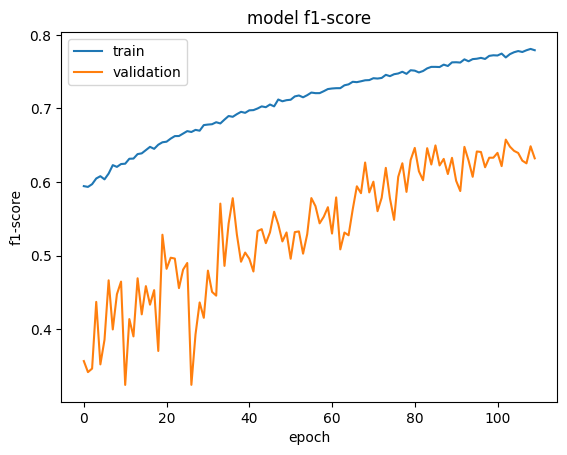

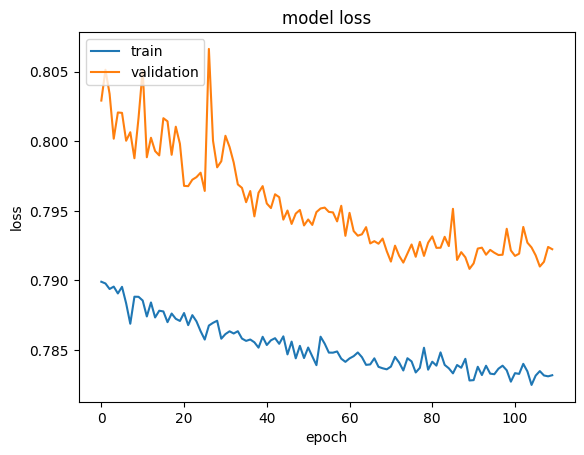

11/11 ━━━━━━━━━━━━━━━━━━━━ 131s 4s/step - IoU: 0.4798 - accuracy: 0.9585 - f1-score: 0.6472 - loss: 0.7881 - precision: 0.4990 - recall: 0.9246


In [ ]:
#MODEL V1 WITH FFUM1
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
# Size of the tiles/patches
size1 = X_train1.shape[2] # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = X_train3.shape[2]

# Image bands
img_bands1 = X_train1.shape[3] # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
img_bands2 = X_train3.shape[3] # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.

# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 200
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = Siamese_CSA_1(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
            model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            #model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = '/content/drive/MyDrive/landslide/Results/weights/Siamese_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5'
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'my_saved_Siamese_CSA'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(f'/content/drive/MyDrive/landslide/Results/weights/Siamese_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.weights.h5',
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True,save_weights_only = True)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                {
                    "input_1": X_train1,
                    "input_2": X_train2,
                    "input_3": X_train3
                },
                y_train,
                validation_data= ({"input_1": X_val1,"input_2": X_val2,"input_3": X_val3}, y_val),
                batch_size= batch,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, tensorboard_callback],
                verbose=1
            )
            training_time = time.time() - start_time
            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = Siamese_CSA_1(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
            load_Attunet.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(f"/content/drive/MyDrive/landslide/Results/weights/Siamese_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.weights.h5")

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate([X_test1,X_test2,X_test3], y_test)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("Siamese_CSA")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_Siamese_CSA.csv', index = False)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_1 (InputLayer)      │ (None, 256, 256, 11)   │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_3 (InputLayer)      │ (None, 256, 256, 6)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_2 (InputLayer)      │ (None, 256, 256, 11)   │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_10            │ (None, 256, 256, 17)   │              0 │ input_1[0][0],         │
│ (Concatenate)             │                        │                │ input_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_11            │ (None, 256, 256, 17)   │              0 │ input_2[0][0],         │
│ (Concatenate)             │                        │                │ input_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional_1 (Functional) │ [(None, 256, 256, 64), │     26,976,424 │ concatenate_10[0][0],  │
│                           │ (None, 128, 128, 64),  │                │ concatenate_11[0][0]   │
│                           │ (None, 64, 64, 128),   │                │                        │
│                           │ (None, 32, 32, 256),   │                │                        │
│                           │ (None, 16, 16, 512),   │                │                        │
│                           │ (None, 8, 8, 1024)]    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_17            │ (None, 8, 8, 2048)     │              0 │ functional_1[0][5],    │
│ (Concatenate)             │                        │                │ functional_1[1][5]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 2048)           │              0 │ concatenate_17[0][0]   │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_3 (Reshape)       │ (None, 1, 1, 2048)     │              0 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_102 (Conv2D)       │ (None, 1, 1, 1024)     │      2,098,176 │ reshape_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_98 (Conv2D)        │ (None, 8, 8, 1024)     │      2,097,152 │ concatenate_17[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_99 (Conv2D)        │ (None, 8, 8, 1024)     │     18,874,368 │ concatenate_17[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_100 (Conv2D)       │ (None, 8, 8, 1024)     │     18,874,368 │ concatenate_17[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_101 (Conv2D)       │ (None, 8, 8, 1024)     │     18,874,368 │ concatenate_17[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_37    │ (None, 1, 1, 1024)     │          4,096 │ conv2d_102[0][0]       │
│ (BatchNormalization) 

 Total params: 122,478,569 (467.22 MB)

 Trainable params: 122,453,097 (467.12 MB)

 Non-trainable params: 25,472 (99.50 KB)

Epoch 1/200
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - IoU: 0.1107 - accuracy: 0.7131 - f1-score: 0.1927 - loss: 0.8317 - precision: 0.1154 - recall: 0.7632
Epoch 1: val_loss improved from inf to 0.85764, saving model to /content/drive/MyDrive/landslide/Results/weights/Siamese_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5
611/611 ━━━━━━━━━━━━━━━━━━━━ 387s 395ms/step - IoU: 0.1107 - accuracy: 0.7132 - f1-score: 0.1927 - loss: 0.8317 - precision: 0.1154 - recall: 0.7633 - val_IoU: 0.0518 - val_accuracy: 0.1581 - val_f1-score: 0.0964 - val_loss: 0.8576 - val_precision: 0.0518 - val_recall: 0.9951
Epoch 2/200
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - IoU: 0.1442 - accuracy: 0.7857 - f1-score: 0.2441 - loss: 0.8237 - precision: 0.1495 - recall: 0.8385
Epoch 2: val_loss improved from 0.85764 to 0.83684, saving model to /content/drive/MyDrive/landslide/Results/weights/Siamese_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5
611/611 ━━━━━━━━━━━━━━━━━━━━ 112s 183ms/ste

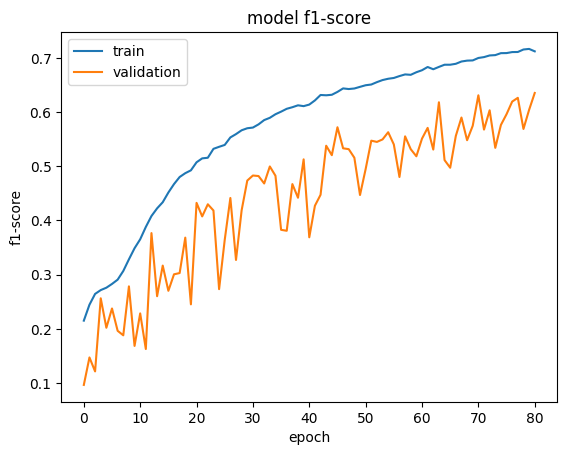

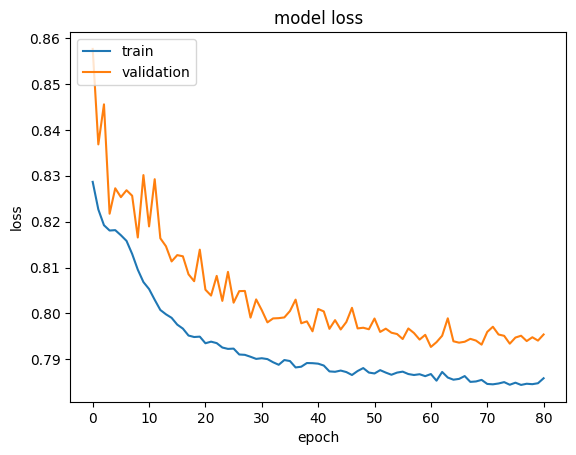

11/11 ━━━━━━━━━━━━━━━━━━━━ 128s 4s/step - IoU: 0.3938 - accuracy: 0.9404 - f1-score: 0.5637 - loss: 0.7901 - precision: 0.4051 - recall: 0.9319


In [ ]:
#FOR THE PAPER MODEL V2 WITH DATA WITHOUT ADA
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
# Size of the tiles/patches
size1 = X_train1.shape[2] # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = X_train3.shape[2]

# Image bands
img_bands1 = X_train1.shape[3] # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
img_bands2 = X_train3.shape[3] # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.

# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 200
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = Siamese_CSA_1(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
            model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            #model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = None
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'my_saved_Siamese_CSA'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(f'/content/drive/MyDrive/landslide/Results/weights/Siamese_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.weights.h5',
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True,save_weights_only = True)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                {
                    "input_1": X_train1,
                    "input_2": X_train2,
                    "input_3": X_train3
                },
                y_train,
                validation_data= ({"input_1": X_val1,"input_2": X_val2,"input_3": X_val3}, y_val),
                batch_size= batch,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, tensorboard_callback],
                verbose=1
            )
            training_time = time.time() - start_time
            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = Siamese_CSA_1(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
            load_Attunet.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(f"/content/drive/MyDrive/landslide/Results/weights/Siamese_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.weights.h5")

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate([X_test1,X_test2,X_test3], y_test)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("Siamese_CSA")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_Siamese_CSA.csv', index = False)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_3 (InputLayer)      │ (None, 256, 256, 6)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_34 (Conv2D)        │ (None, 256, 256, 24)   │            168 │ input_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_8        │ (None, 256, 256, 24)   │            240 │ conv2d_34[0][0]        │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_35 (Conv2D)        │ (None, 256, 256, 64)   │          1,536 │ depthwise_conv2d_8[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_9     │ (None, 256, 256, 64)   │            256 │ conv2d_35[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_38 (Conv2D)        │ (None, 256, 256, 256)  │         16,640 │ batch_normalization_9… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_9        │ (None, 256, 256, 256)  │          2,560 │ conv2d_38[0][0]        │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_39 (Conv2D)        │ (None, 256, 256, 64)   │         16,384 │ depthwise_conv2d_9[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_11    │ (None, 256, 256, 64)   │            256 │ conv2d_39[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)               │ (None, 256, 256, 64)   │              0 │ batch_normalization_9… │
│                           │                        │                │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ G2_layer (MaxPooling2D)   │ (None, 128, 128, 64)   │              0 │ add_4[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_42 (Conv2D)        │ (None, 128, 128, 256)  │         16,640 │ G2_layer[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_10       │ (None, 128, 128, 256)  │          2,560 │ conv2d_42[0][0]        │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_43 (Conv2D)        │ (None, 128, 128, 128)  │         32,768 │ depthwise_conv2d_10[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_13    │ (None, 128, 128, 128)  │            512 │ conv2d_43[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ G3_layer (MaxPooling2D)   │ (None, 64, 64, 128)    │              0 │ batch_normalization_1… │
├──────────────────────

 Total params: 124,456,657 (474.76 MB)

 Trainable params: 124,428,489 (474.66 MB)

 Non-trainable params: 28,168 (110.03 KB)

Epoch 1/200
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - IoU: 0.1147 - accuracy: 0.7179 - f1-score: 0.1988 - loss: 0.8332 - precision: 0.1192 - recall: 0.7924
Epoch 1: val_loss improved from inf to 0.83888, saving model to /content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5
611/611 ━━━━━━━━━━━━━━━━━━━━ 460s 474ms/step - IoU: 0.1147 - accuracy: 0.7180 - f1-score: 0.1989 - loss: 0.8332 - precision: 0.1192 - recall: 0.7925 - val_IoU: 0.0811 - val_accuracy: 0.5546 - val_f1-score: 0.1465 - val_loss: 0.8389 - val_precision: 0.0826 - val_recall: 0.8674
Epoch 2/200
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - IoU: 0.1526 - accuracy: 0.8024 - f1-score: 0.2559 - loss: 0.8240 - precision: 0.1585 - recall: 0.8413
Epoch 2: val_loss improved from 0.83888 to 0.82184, saving model to /content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5
611/611 ━━━━━━━━━━━━━━━━━━━━ 124s 202ms/s

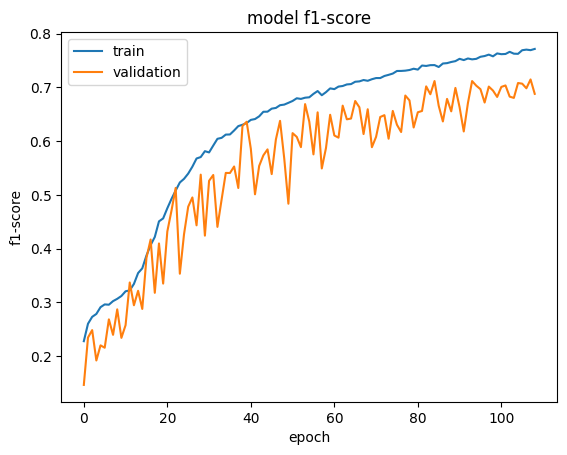

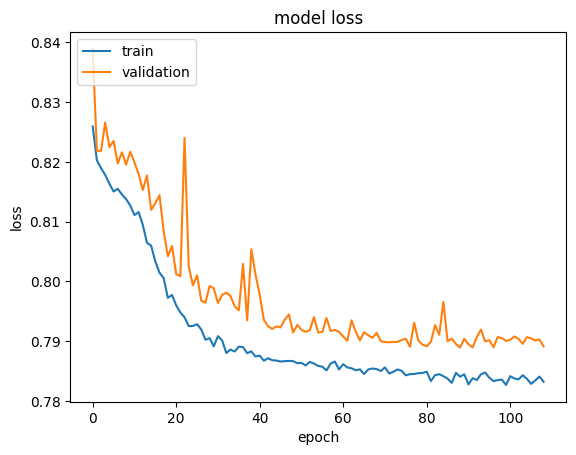

11/11 ━━━━━━━━━━━━━━━━━━━━ 129s 5s/step - IoU: 0.4975 - accuracy: 0.9609 - f1-score: 0.6632 - loss: 0.7868 - precision: 0.5155 - recall: 0.9335


In [ ]:
#MODEL WITH DATA WITH ADA
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
# Size of the tiles/patches
size1 = X_train1.shape[2] # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = X_train3.shape[2]

# Image bands
img_bands1 = X_train1.shape[3] # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
img_bands2 = X_train3.shape[3] # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.

# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 200
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = Siamese_CSA_2(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
            model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            #model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = None
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'my_saved_Siamese_CSA'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(f'/content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.weights.h5',
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True,save_weights_only = True)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                {
                    "input_1": X_train1,
                    "input_2": X_train2,
                    "input_3": X_train3
                },
                y_train,
                validation_data= ({"input_1": X_val1,"input_2": X_val2,"input_3": X_val3}, y_val),
                batch_size= batch,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, tensorboard_callback],
                verbose=1
            )
            training_time = time.time() - start_time
            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = Siamese_CSA_2(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
            load_Attunet.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(f"/content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.weights.h5")

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate([X_test1,X_test2,X_test3], y_test)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("Siamese2_CSA")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_Siamese2_CSA.csv', index = False)

In [ ]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
# Size of the tiles/patches
size1 = X_train1.shape[2] # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = X_train3.shape[2]

# Image bands
img_bands1 = X_train1.shape[3] # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
img_bands2 = X_train3.shape[3] # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11

del X_train1, X_train2, X_train3, y_train

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_3 (InputLayer)      │ (None, 256, 256, 6)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_34 (Conv2D)        │ (None, 256, 256, 24)   │            168 │ input_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_8        │ (None, 256, 256, 24)   │            240 │ conv2d_34[0][0]        │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_35 (Conv2D)        │ (None, 256, 256, 64)   │          1,536 │ depthwise_conv2d_8[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_9     │ (None, 256, 256, 64)   │            256 │ conv2d_35[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_38 (Conv2D)        │ (None, 256, 256, 256)  │         16,640 │ batch_normalization_9… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_9        │ (None, 256, 256, 256)  │          2,560 │ conv2d_38[0][0]        │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_39 (Conv2D)        │ (None, 256, 256, 64)   │         16,384 │ depthwise_conv2d_9[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_11    │ (None, 256, 256, 64)   │            256 │ conv2d_39[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)               │ (None, 256, 256, 64)   │              0 │ batch_normalization_9… │
│                           │                        │                │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ G2_layer (MaxPooling2D)   │ (None, 128, 128, 64)   │              0 │ add_4[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_42 (Conv2D)        │ (None, 128, 128, 256)  │         16,640 │ G2_layer[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_10       │ (None, 128, 128, 256)  │          2,560 │ conv2d_42[0][0]        │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_43 (Conv2D)        │ (None, 128, 128, 128)  │         32,768 │ depthwise_conv2d_10[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_13    │ (None, 128, 128, 128)  │            512 │ conv2d_43[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ G3_layer (MaxPooling2D)   │ (None, 64, 64, 128)    │              0 │ batch_normalization_1… │
├──────────────────────

 Total params: 124,456,657 (474.76 MB)

 Trainable params: 124,428,489 (474.66 MB)

 Non-trainable params: 28,168 (110.03 KB)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 1 variables whereas the saved optimizer has 525 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/100
693/693 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - IoU: 0.5358 - accuracy: 0.9692 - f1-score: 0.6898 - loss: 0.7971 - precision: 0.5452 - recall: 0.9670
Epoch 1: val_loss improved from inf to 0.79476, saving model to /content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5
693/693 ━━━━━━━━━━━━━━━━━━━━ 461s 390ms/step - IoU: 0.5358 - accuracy: 0.9692 - f1-score: 0.6898 - loss: 0.7971 - precision: 0.5452 - recall: 0.9670 - val_IoU: 0.5947 - val_accuracy: 0.9764 - val_f1-score: 0.7401 - val_loss: 0.7948 - val_precision: 0.6208 - val_recall: 0.9314
Epoch 2/100
693/693 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - IoU: 0.5402 - accuracy: 0.9695 - f1-score: 0.6940 - loss: 0.7965 - precision: 0.5477 - recall: 0.9737
Epoch 2: val_loss improved from 0.79476 to 0.79294, saving model to /content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5
693/693 ━━━━━━━━━━━━━━━━━━━━ 130s 188ms/s

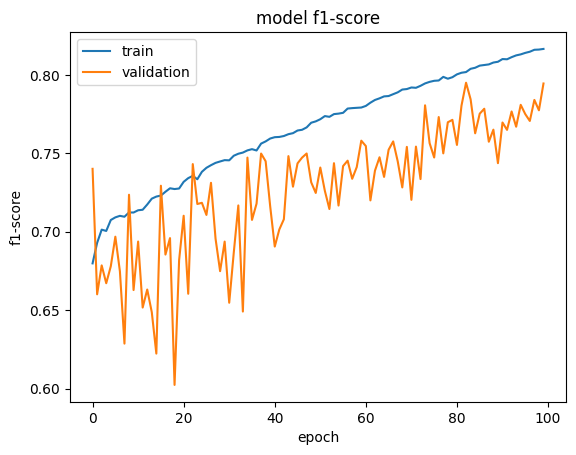

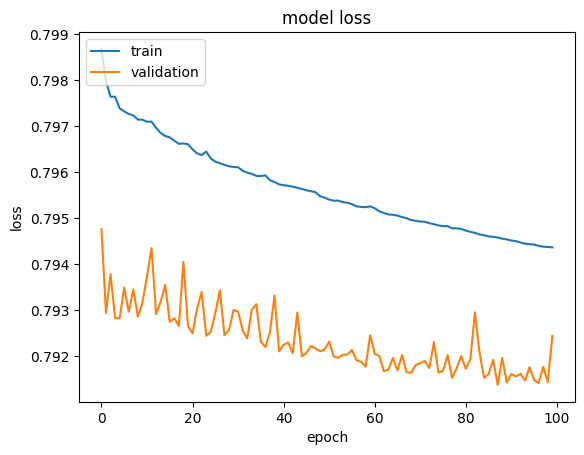

82/82 ━━━━━━━━━━━━━━━━━━━━ 40s 291ms/step - IoU: 0.5776 - accuracy: 0.9798 - f1-score: 0.7270 - loss: 0.8315 - precision: 0.5915 - recall: 0.9561


In [ ]:
#MODEL WITH DATA WITH ADA and DDPM AUGMENTATION
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 100
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = Siamese_CSA_2(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
            model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            #model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = '/content/drive/MyDrive/landslide/Selection_model/Model_2_withAda/Siamese2_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5'
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'my_saved_Siamese_CSA'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(f'/content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.weights.h5',
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True,save_weights_only = True)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, tensorboard_callback],
                verbose=1
            )
            training_time = time.time() - start_time
            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = Siamese_CSA_2(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
            load_Attunet.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(f"/content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.weights.h5")

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("Siamese2_CSA")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_Siamese2_CSA.csv', index = False)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_3 (InputLayer)      │ (None, 256, 256, 6)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_34 (Conv2D)        │ (None, 256, 256, 24)   │            168 │ input_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_8        │ (None, 256, 256, 24)   │            240 │ conv2d_34[0][0]        │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_35 (Conv2D)        │ (None, 256, 256, 64)   │          1,536 │ depthwise_conv2d_8[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_9     │ (None, 256, 256, 64)   │            256 │ conv2d_35[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_38 (Conv2D)        │ (None, 256, 256, 256)  │         16,640 │ batch_normalization_9… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_9        │ (None, 256, 256, 256)  │          2,560 │ conv2d_38[0][0]        │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_39 (Conv2D)        │ (None, 256, 256, 64)   │         16,384 │ depthwise_conv2d_9[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_11    │ (None, 256, 256, 64)   │            256 │ conv2d_39[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)               │ (None, 256, 256, 64)   │              0 │ batch_normalization_9… │
│                           │                        │                │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ G2_layer (MaxPooling2D)   │ (None, 128, 128, 64)   │              0 │ add_4[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_42 (Conv2D)        │ (None, 128, 128, 256)  │         16,640 │ G2_layer[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_10       │ (None, 128, 128, 256)  │          2,560 │ conv2d_42[0][0]        │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_43 (Conv2D)        │ (None, 128, 128, 128)  │         32,768 │ depthwise_conv2d_10[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_13    │ (None, 128, 128, 128)  │            512 │ conv2d_43[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ G3_layer (MaxPooling2D)   │ (None, 64, 64, 128)    │              0 │ batch_normalization_1… │
├──────────────────────

 Total params: 124,456,657 (474.76 MB)

 Trainable params: 124,428,489 (474.66 MB)

 Non-trainable params: 28,168 (110.03 KB)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 1 variables whereas the saved optimizer has 525 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/100
693/693 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - IoU: 0.5013 - accuracy: 0.9588 - f1-score: 0.6543 - loss: 0.7862 - precision: 0.5113 - recall: 0.9564
Epoch 1: val_loss improved from inf to 0.79571, saving model to /content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5
693/693 ━━━━━━━━━━━━━━━━━━━━ 475s 409ms/step - IoU: 0.5013 - accuracy: 0.9588 - f1-score: 0.6543 - loss: 0.7862 - precision: 0.5113 - recall: 0.9564 - val_IoU: 0.4642 - val_accuracy: 0.9597 - val_f1-score: 0.6283 - val_loss: 0.7957 - val_precision: 0.5022 - val_recall: 0.8561
Epoch 2/100
693/693 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - IoU: 0.5112 - accuracy: 0.9610 - f1-score: 0.6653 - loss: 0.7852 - precision: 0.5194 - recall: 0.9640
Epoch 2: val_loss improved from 0.79571 to 0.78958, saving model to /content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5
693/693 ━━━━━━━━━━━━━━━━━━━━ 132s 191ms/s

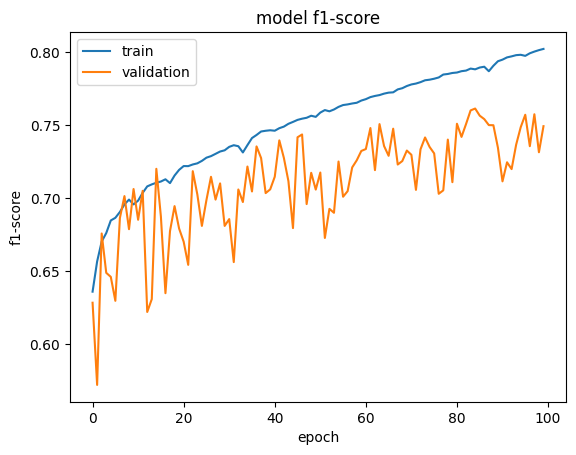

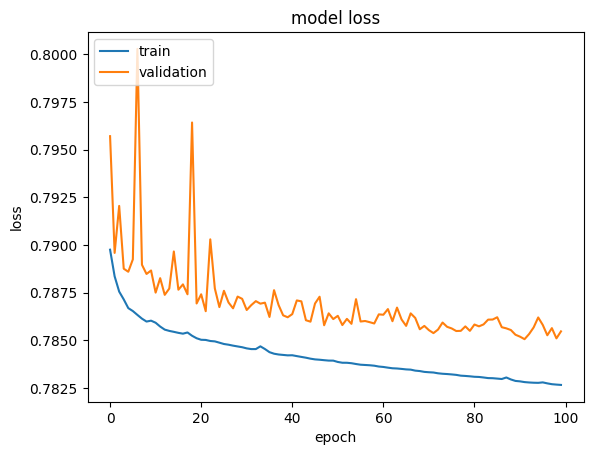

82/82 ━━━━━━━━━━━━━━━━━━━━ 56s 466ms/step - IoU: 0.5597 - accuracy: 0.9713 - f1-score: 0.7098 - loss: 0.7881 - precision: 0.5775 - recall: 0.9419


In [ ]:
#MODEL WITH DATA WITH ADA and ORDINARY AUGMENTATION
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 100
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = Siamese_CSA_2(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
            model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            #model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = '/content/drive/MyDrive/landslide/Selection_model/Model_2_withAda/Siamese2_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5'
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'my_saved_Siamese_CSA'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(f'/content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.weights.h5',
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True,save_weights_only = True)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, tensorboard_callback],
                verbose=1
            )
            training_time = time.time() - start_time
            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = Siamese_CSA_2(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
            load_Attunet.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(f"/content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.weights.h5")

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("Siamese2_CSA")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_Siamese2_CSA.csv', index = False)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_3 (InputLayer)      │ (None, 256, 256, 6)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_34 (Conv2D)        │ (None, 256, 256, 24)   │            168 │ input_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_8        │ (None, 256, 256, 24)   │            240 │ conv2d_34[0][0]        │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_35 (Conv2D)        │ (None, 256, 256, 64)   │          1,536 │ depthwise_conv2d_8[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_9     │ (None, 256, 256, 64)   │            256 │ conv2d_35[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_38 (Conv2D)        │ (None, 256, 256, 256)  │         16,640 │ batch_normalization_9… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_9        │ (None, 256, 256, 256)  │          2,560 │ conv2d_38[0][0]        │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_39 (Conv2D)        │ (None, 256, 256, 64)   │         16,384 │ depthwise_conv2d_9[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_11    │ (None, 256, 256, 64)   │            256 │ conv2d_39[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)               │ (None, 256, 256, 64)   │              0 │ batch_normalization_9… │
│                           │                        │                │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ G2_layer (MaxPooling2D)   │ (None, 128, 128, 64)   │              0 │ add_4[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_42 (Conv2D)        │ (None, 128, 128, 256)  │         16,640 │ G2_layer[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_10       │ (None, 128, 128, 256)  │          2,560 │ conv2d_42[0][0]        │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_43 (Conv2D)        │ (None, 128, 128, 128)  │         32,768 │ depthwise_conv2d_10[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_13    │ (None, 128, 128, 128)  │            512 │ conv2d_43[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ G3_layer (MaxPooling2D)   │ (None, 64, 64, 128)    │              0 │ batch_normalization_1… │
├──────────────────────

 Total params: 124,456,657 (474.76 MB)

 Trainable params: 124,428,489 (474.66 MB)

 Non-trainable params: 28,168 (110.03 KB)

Epoch 1/200
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - IoU: 0.1190 - accuracy: 0.7526 - f1-score: 0.2044 - loss: 0.8372 - precision: 0.1244 - recall: 0.7608
Epoch 1: val_loss improved from inf to 0.82351, saving model to /content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5
611/611 ━━━━━━━━━━━━━━━━━━━━ 442s 444ms/step - IoU: 0.1190 - accuracy: 0.7527 - f1-score: 0.2044 - loss: 0.8372 - precision: 0.1244 - recall: 0.7609 - val_IoU: 0.1485 - val_accuracy: 0.7932 - val_f1-score: 0.2517 - val_loss: 0.8235 - val_precision: 0.1556 - val_recall: 0.8073
Epoch 2/200
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - IoU: 0.1617 - accuracy: 0.8071 - f1-score: 0.2699 - loss: 0.8146 - precision: 0.1686 - recall: 0.8323
Epoch 2: val_loss improved from 0.82351 to 0.82147, saving model to /content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_256_filters_64_batch_size_4_lr_0.0001.weights.h5
611/611 ━━━━━━━━━━━━━━━━━━━━ 123s 202ms/s

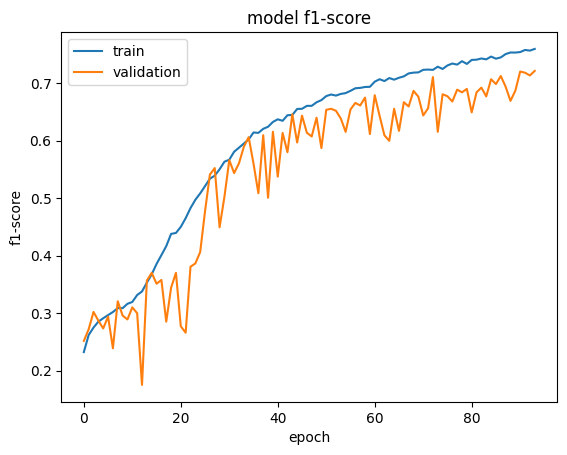

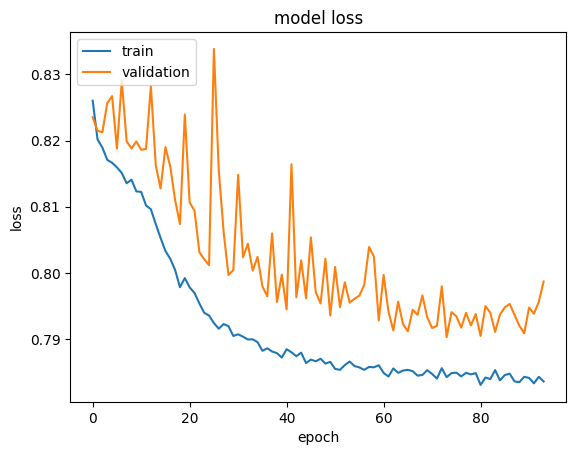

11/11 ━━━━━━━━━━━━━━━━━━━━ 128s 4s/step - IoU: 0.2736 - accuracy: 0.9655 - f1-score: 0.4283 - loss: 0.8517 - precision: 0.7067 - recall: 0.3092


In [ ]:
#MODEL WITH DATA WITHOUT ADA
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
# Size of the tiles/patches
size1 = X_train1.shape[2] # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = X_train3.shape[2]

# Image bands
img_bands1 = X_train1.shape[3] # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
img_bands2 = X_train3.shape[3] # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.

# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 200
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = Siamese_CSA_2(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
            model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            #model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = None
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'my_saved_Siamese_CSA'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(f'/content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.weights.h5',
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True,save_weights_only = True)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                {
                    "input_1": X_train1,
                    "input_2": X_train2,
                    "input_3": X_train3
                },
                y_train,
                validation_data= ({"input_1": X_val1,"input_2": X_val2,"input_3": X_val3}, y_val),
                batch_size= batch,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, tensorboard_callback],
                verbose=1
            )
            training_time = time.time() - start_time
            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = Siamese_CSA_2(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
            load_Attunet.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(f"/content/drive/MyDrive/landslide/Results/weights/Siamese2_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.weights.h5")

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate([X_test1,X_test2,X_test3], y_test)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("Siamese2_CSA")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_Siamese2_CSA.csv', index = False)

In [ ]:
#MODEL WITH DATA WITHOUT ADA
# fix random seed for reproducibility
np.random.seed(42)
band_combinations = [
    # RGB only
    ("RGB", [0, 1, 2], [], []),

    # RGB + IR
    ("RGB+IR", [0, 1, 2, 3, 4, 5], [], []),

    #RGB+ IR + SIF
    ("RGB+IR+SIF", [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [], []),

    #RGB+ IR + TFs
    ("RGB+IR+TFs", [0, 1, 2, 3, 4, 5], [], [0, 1, 2, 3, 4, 5]),

    # All optical + TFs (Full setup)
    ("AllBands", list(range(11)), [], list(range(6))),

    # Ghislain baseline (e.g. RGB + NIR + NDWI + BI + DEM + SLOPE)
    ("emaniBaseline", [0, 1, 2, 3, 6, 7, 8], [], [0, 1]),
]

# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
# Size of the tiles/patches
size1 = X_train1.shape[2] # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = X_train3.shape[2]

# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 60
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["band_combo"] = [] # Band combination
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.
# Loop over experiments
# Loop over experiments
for combo_name, optical_idx, _, tf_idx in band_combinations:

    for fiilter in filters:
        for learning_rate in lr:
            for batch in batch_size:
                print(f"Training: {combo_name} | Filters: {fiilter}, LR: {learning_rate}, Batch: {batch}")

                model = Siamese_CSA_2(
                    filtersFirstLayer=fiilter,
                    input_size1=(size1, size1, X_train1[..., optical_idx].shape[-1]),
                    input_size2=(size1, size1, X_train1[..., optical_idx].shape[-1]),
                    input_size3=(size1, size1, X_train3[..., tf_idx].shape[-1] if tf_idx else 1),
                    batchnorm=True
                )
                model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                              loss=loss, metrics=metrics)
                pretrained_weights = None
                if(pretrained_weights):
                    model.load_weights(pretrained_weights)

                # Callbacks
                model_path = f"/content/drive/MyDrive/landslide/Results/weights/{combo_name}_CSA_filters_{fiilter}_batch_{batch}_lr_{learning_rate}.weights.h5"
                early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
                tensorboard_callback = TensorBoard(log_dir=f"logs/{combo_name}")
                checkpoint = keras.callbacks.ModelCheckpoint(model_path, monitor='val_loss', mode='min', save_best_only=True, save_weights_only=True)

                # Dataset
                train_dataset = tf.data.Dataset.from_tensor_slices(({
                    "input_1": X_train1[..., optical_idx],
                    "input_2": X_train2[..., optical_idx],
                    "input_3": X_train3[..., tf_idx] if tf_idx else np.zeros((X_train3.shape[0], X_train3.shape[1], X_train3.shape[2], 1))
                }, y_train)).batch(batch).prefetch(tf.data.AUTOTUNE)

                val_dataset = tf.data.Dataset.from_tensor_slices(({
                    "input_1": X_val1[..., optical_idx],
                    "input_2": X_val2[..., optical_idx],
                    "input_3": X_val3[..., tf_idx] if tf_idx else np.zeros((X_val3.shape[0], X_val3.shape[1], X_val3.shape[2], 1))
                }, y_val)).batch(batch).prefetch(tf.data.AUTOTUNE)

                start_time = time.time()
                history = model.fit(
                    train_dataset,
                    validation_data=val_dataset,
                    epochs=epochs,
                    initial_epoch=previous_epoch,
                    callbacks=[early_stop, checkpoint, tensorboard_callback],
                    verbose=1
                )
                training_time = time.time() - start_time

                # Evaluate
                test_dataset = tf.data.Dataset.from_tensor_slices(({
                    "input_1": X_test1[..., optical_idx],
                    "input_2": X_test2[..., optical_idx],
                    "input_3": X_test3[..., tf_idx] if tf_idx else np.zeros((X_test3.shape[0], X_test3.shape[1], X_test3.shape[2], 1))
                }, y_test)).batch(batch).prefetch(tf.data.AUTOTUNE)

                metrics_eval = model.evaluate(test_dataset)

                dic["model"].append("Siamese2_CSA")
                dic["band_combo"].append(combo_name)
                dic["batch_size"].append(batch)
                dic["learning_rate"].append(learning_rate)
                dic["filters"].append(fiilter)
                dic["precision_area"].append(metrics_eval[1])
                dic["recall_area"].append(metrics_eval[2])
                dic["f1_score_area"].append(metrics_eval[3])
                dic["miou_area"].append(metrics_eval[4])
                dic["oa_area"].append(metrics_eval[5])
                dic["time_area"].append(training_time)

                # Plot F1 score and loss
                def save_plot(metric_name, ylabel):
                    plt.figure()
                    plt.plot(history.history[metric_name])
                    plt.plot(history.history[f'val_{metric_name}'])
                    plt.title(f'{metric_name} - {combo_name}')
                    plt.xlabel('Epoch')
                    plt.ylabel(ylabel)
                    plt.legend(['Train', 'Validation'])
                    plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/{combo_name}_{metric_name}.png")
                    plt.close()

                save_plot('f1-score', 'F1 Score')
                save_plot('loss', 'Loss')
                # Cleanup to avoid memory leaks
                K.clear_session()
                del model, history, train_dataset, val_dataset, test_dataset
                gc.collect()
                tf.compat.v1.reset_default_graph()
# Save CSV of all results
results = pd.DataFrame(dic)
results.to_csv('/content/drive/MyDrive/landslide/Results/csv/experiments_summary.csv', index=False)

Training: AllBands | Filters: 64, LR: 0.0001, Batch: 4
Epoch 1/60
611/611 ━━━━━━━━━━━━━━━━━━━━ 433s 427ms/step - IoU: 0.1155 - accuracy: 0.7294 - f1-score: 0.2003 - loss: 0.8340 - precision: 0.1200 - recall: 0.7948 - val_IoU: 0.1743 - val_accuracy: 0.8516 - val_f1-score: 0.2899 - val_loss: 0.8259 - val_precision: 0.1899 - val_recall: 0.7283
Epoch 2/60
611/611 ━━━━━━━━━━━━━━━━━━━━ 112s 184ms/step - IoU: 0.1505 - accuracy: 0.8023 - f1-score: 0.2536 - loss: 0.8240 - precision: 0.1570 - recall: 0.8300 - val_IoU: 0.1659 - val_accuracy: 0.8233 - val_f1-score: 0.2782 - val_loss: 0.8189 - val_precision: 0.1738 - val_recall: 0.8136
Epoch 3/60
611/611 ━━━━━━━━━━━━━━━━━━━━ 116s 190ms/step - IoU: 0.1595 - accuracy: 0.8153 - f1-score: 0.2666 - loss: 0.8220 - precision: 0.1665 - recall: 0.8365 - val_IoU: 0.1693 - val_accuracy: 0.8261 - val_f1-score: 0.2832 - val_loss: 0.8176 - val_precision: 0.1768 - val_recall: 0.8269
Epoch 4/60
611/611 ━━━━━━━━━━━━━━━━━━━━ 112s 183ms/step - IoU: 0.1669 - accuracy:

_______________________________________________________________________________
Filters:  32
Learning rate:  0.0001
Batch size:  8
Epoch 1/100
292/292 [==============================] - ETA: 0s - loss: 0.7495 - precision: 0.1832 - recall: 0.5457 - f1-score: 0.2243 - IoU: 0.1324 - accuracy: 0.7346
Epoch 1: val_loss improved from inf to 0.66842, saving model to /content/drive/MyDrive/landslide/Results/weights/unet_size_128_filters_32_batch_size_8_lr_0.0001.hdf5
292/292 [==============================] - 413s 1s/step - loss: 0.7495 - precision: 0.1832 - recall: 0.5457 - f1-score: 0.2243 - IoU: 0.1324 - accuracy: 0.7346 - val_loss: 0.6684 - val_precision: 0.1993 - val_recall: 0.5905 - val_f1-score: 0.2883 - val_IoU: 0.1730 - val_accuracy: 0.8463
Epoch 2/100
292/292 [==============================] - ETA: 0s - loss: 0.6131 - precision: 0.3191 - recall: 0.4203 - f1-score: 0.3377 - IoU: 0.2077 - accuracy: 0.9219
Epoch 2: val_loss improved from 0.66842 to 0.59592, saving model to /content/driv

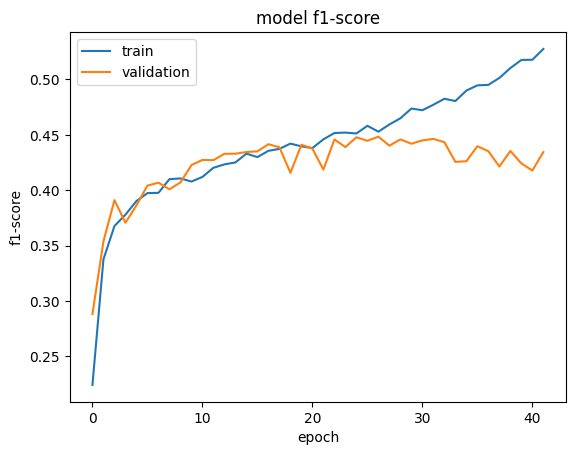

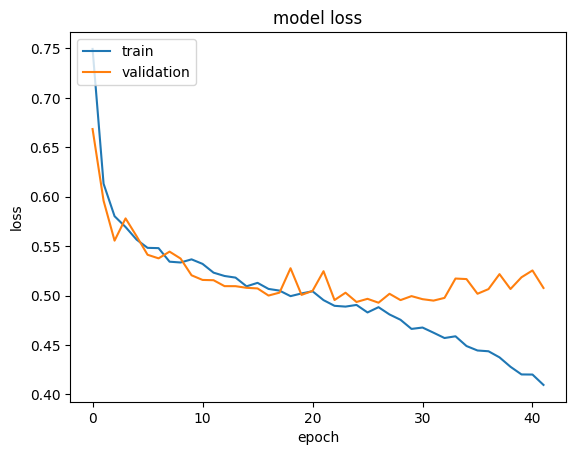

19/19 [==============================] - 10s 475ms/step - loss: 0.4717 - precision: 0.4421 - recall: 0.5007 - f1-score: 0.4659 - IoU: 0.3048 - accuracy: 0.9404


In [ ]:
# Model training - Results are saved in a .csv file

# Size of the tiles/patches
size = X_train1.shape[2] # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 4, that is 128.

# Image bands
img_bands = X_train1.shape[3] # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 4, that is 4.

# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss=loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [32]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [8]

# Epochs. The number of iterations the model will train.
epochs = 100
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

def aspp_block(inputs, filters):
    # Atrous Spatial Pyramid Pooling block
    # inputs: input tensor
    # filters: number of filters in the convolutional layers
    # Branch 1: 1x1 convolution
    branch_1 = tf.keras.layers.Conv2D(filters, (1, 1), activation='relu')(inputs)

    # Branch 2: 3x3 convolution with dilation rate 6
    branch_2 = tf.keras.layers.Conv2D(filters, (3, 3), dilation_rate=6, padding='same', activation='relu')(inputs)

    # Branch 3: 3x3 convolution with dilation rate 12
    branch_3 = tf.keras.layers.Conv2D(filters, (3, 3), dilation_rate=12, padding='same', activation='relu')(inputs)

    # Branch 4: 3x3 convolution with dilation rate 18
    branch_4 = tf.keras.layers.Conv2D(filters, (3, 3), dilation_rate=18, padding='same', activation='relu')(inputs)

    # Global average pooling
    branch_5 = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    branch_5 = tf.keras.layers.Reshape((1, 1, filters))(branch_5)
    branch_5 = tf.keras.layers.Conv2D(filters, (1, 1), activation='relu')(branch_5)
    branch_5 = tf.keras.layers.UpSampling2D(size=(inputs.shape[1], inputs.shape[2]), interpolation='bilinear')(branch_5)

    # Concatenate branches
    concat = tf.keras.layers.Concatenate()([branch_1, branch_2, branch_3, branch_4, branch_5])
    # Final 1x1 convolution
    output = tf.keras.layers.Conv2D(filters, (1, 1), activation='relu')(concat)
    return output


def convolutional_block_attention_module(inputs):

    def channel_attention_module(inputs,reduction_ratio=16):
        # Channel attention module (CAM)
        channels = inputs.shape[-1]
        # Global average pooling
        avg_pool = layers.GlobalAveragePooling2D()(inputs)
        # Dense layers
        fc1 = layers.Dense(channels/reduction_ratio, activation='relu')(avg_pool)
        fc2 = layers.Dense(channels, activation='sigmoid')(fc1)
        # Reshape and multiply
        cam = layers.Reshape((1, 1, channels))(fc2)
        cam = layers.Multiply()([inputs, cam])
        return cam

    def spatial_attention_module(inputs):
        # Spatial attention module (SAM)
        max_pool = layers.MaxPooling2D(pool_size=(2, 2))(inputs)
        avg_pool = layers.AveragePooling2D(pool_size=(2, 2))(inputs)
        concat1 = layers.Concatenate(axis=-3)([max_pool, avg_pool])
        concat = layers.Concatenate(axis=-2)([concat1, concat1])
        conv = layers.Conv2D(filters= inputs.shape[-1], kernel_size=(3, 3), strides=(1, 1), padding='same', activation='sigmoid')(concat)
        sam = layers.Multiply()([inputs, conv])
        return sam

    # Convolutional Block Attention Module (CBAM)
    cam1 = channel_attention_module(inputs)
    cbam = spatial_attention_module(cam1)
    return cbam

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)

            # We define the model architecture here.
            def unet(lr,filtersFirstLayer, pretrained_weights = None,input_size = (size,size,img_bands)):
                inputs = Input(input_size)

                conv1 = Conv2D(filtersFirstLayer, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(inputs)
                conv1 = Dropout(0.1)(conv1)
                conv1 = Conv2D(filtersFirstLayer, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(conv1)
                conv1a = convolutional_block_attention_module(conv1)
                pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

                conv2 = Conv2D(filtersFirstLayer*2, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(pool1)
                conv2 = Dropout(0.1)(conv2)
                conv2 = Conv2D(filtersFirstLayer*2, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(conv2)
                conv2a = convolutional_block_attention_module(conv2)
                pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

                conv3 = Conv2D(filtersFirstLayer*4, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(pool2)
                conv3 = Dropout(0.2)(conv3)
                conv3 = Conv2D(filtersFirstLayer*4, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(conv3)
                conv3a = convolutional_block_attention_module(conv3)
                pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

                conv4 = Conv2D(filtersFirstLayer*8, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(pool3)
                conv4 = Dropout(0.2)(conv4)
                conv4 = Conv2D(filtersFirstLayer*8, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(conv4)
                conv4a = convolutional_block_attention_module(conv4)
                pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

                conv5 = Conv2D(filtersFirstLayer*16, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(pool4)
                conv5 = Dropout(0.3)(conv5)
                conv5 = Conv2D(filtersFirstLayer*16, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(conv5)
                conv5 = aspp_block(conv5, filtersFirstLayer*16)

                up6 = Conv2D(filtersFirstLayer*8, 2, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(UpSampling2D(size = (2,2))(conv5))
                merge6 = concatenate([conv4a,up6], axis = 3)
                conv6 = Conv2D(filtersFirstLayer*8, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(merge6)
                conv6 = Dropout(0.2)(conv6)
                conv6 = Conv2D(filtersFirstLayer*8, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(conv6)

                up7 = Conv2D(filtersFirstLayer*4, 2, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(UpSampling2D(size = (2,2))(conv6))
                merge7 = concatenate([conv3a,up7], axis = 3)
                conv7 = Conv2D(filtersFirstLayer*4, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(merge7)
                conv7 = Dropout(0.2)(conv7)
                conv7 = Conv2D(filtersFirstLayer*4, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(conv7)

                up8 = Conv2D(filtersFirstLayer*2, 2, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(UpSampling2D(size = (2,2))(conv7))
                merge8 = concatenate([conv2a,up8], axis = 3)
                conv8 = Conv2D(filtersFirstLayer*2, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(merge8)
                conv8 = Dropout(0.1)(conv8)
                conv8 = Conv2D(filtersFirstLayer*2, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(conv8)

                up9 = Conv2D(filtersFirstLayer, 2, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(UpSampling2D(size = (2,2))(conv8))
                merge9 = concatenate([conv1a,up9], axis = 3)
                conv9 = Conv2D(filtersFirstLayer, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(merge9)
                conv9 = Dropout(0.1)(conv9)
                conv9 = Conv2D(filtersFirstLayer, 3, activation = 'relu', padding = 'same', kernel_initializer = 'glorot_normal')(conv9)

                conv10 = Conv2D(1, 1, activation = 'sigmoid')(conv9)

                model = Model(inputs, conv10)

                # We initialise the ADAM optimizer here with the different learning rates that we assigned earlier.
                # Optimizers are algorithms or methods used to change the attributes of your neural network such as weights
                # and learning rate in order to reduce the losses. Optimizers help to get results faster.
                model.compile(optimizer = Adam(learning_rate = lr), loss = loss, metrics = metrics)

                #model.summary()

                if(pretrained_weights):
                    model.load_weights(pretrained_weights)

                return model

            # Load the model in a new variable called "model".
            model = unet(filtersFirstLayer= fiilter, lr = learning_rate, input_size = (size,size,img_bands))
             # See the architecture of the model
            #model.summary()
            #plot_model(model)


            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 15, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(f'/content/drive/MyDrive/landslide/Results/weights/unet_size_{size}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.hdf5',
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True,save_weights_only = True)

            # fit the model with 20% of the dataset used as the validation set
            np.random.seed(0)
            history = model.fit(X_train1, y_train,
                                batch_size = batch,epochs=epochs,
                                validation_data=(X_val1, y_val), # This is the value that sets the validation split from the training data (X_train)
                                callbacks = [model_checkpoint, early_stop], verbose=1)

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/unet_size_{size}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/unet_size_{size}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_unet = unet(filtersFirstLayer= fiilter, lr = learning_rate,input_size=(size,size,img_bands))
            # load the last saved weight from the training
            load_unet.load_weights(f"/content/drive/MyDrive/landslide/Results/weights/unet_size_{size}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.hdf5")

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            res_1= load_unet.evaluate(X_val1, y_val)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("Unet")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(res_1[1])
            dic["recall_area"].append(res_1[2])
            dic["f1_score_area"].append(res_1[3])

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_Unet.csv', index = False)

## Starting The Evaluation of the Models

In [ ]:
import tensorflow as tf
from tensorflow import keras

## Limit GPU Memory in TensorFlow
## Because TensorFlow, by default, allocates the full amount of available GPU memory when it is launched.
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)
        print('{} memory growth: {}'.format(device, tf.config.experimental.get_memory_growth(device)))
else:
    print("Not enough GPU hardware devices available")

PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU') memory growth: True


In [ ]:
with tf.device('/CPU:0'):
    val_dataset = tf.data.Dataset.from_tensor_slices(((X_val1, X_val2), y_val))
    test_dataset = tf.data.Dataset.from_tensor_slices(((X_test1, X_test2), y_test))

In [ ]:
del X_val1, X_val2, y_val, X_test1, X_test2, y_test

In [ ]:
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices(((X_train1, X_train2), y_train))

In [ ]:
del X_train1, X_train2, y_train

In [ ]:
# Shuffle and batch the dataset
batch_size = 16  # Adjust based on your needs
train_dataset = train_dataset.shuffle(buffer_size=2443).cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
!pip install keras-unet-collection -q -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.8 MB/s eta 0:00:00


In [ ]:
from __future__ import absolute_import

from keras_unet_collection.layer_utils import *
from keras_unet_collection.transformer_layers import patch_extract, patch_embedding, patch_merging, patch_expanding, window_partition, window_reverse, drop_path, Mlp

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import numpy as np
import tensorflow as tf
from tensorflow.nn import depth_to_space
from tensorflow.image import extract_patches
from tensorflow.keras.layers import Conv2D, Layer, Dense, Embedding, Dropout, Conv2D, LayerNormalization
from tensorflow.keras.activations import softmax, sigmoid

In [ ]:
class WindowAttention(tf.keras.layers.Layer):
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, qk_scale=None,
                 attn_drop=0, proj_drop=0., name='swin_atten', **kwargs):
        super(WindowAttention, self).__init__(**kwargs)

        self.dim = dim # number of input dimensions
        self.window_size = window_size # size of the attention window
        self.num_heads = num_heads # number of self-attention heads
        self.qkv_bias = qkv_bias
        self.qk_scale = qk_scale
        self.attn_drop = attn_drop
        self.proj_drop = proj_drop

        head_dim = dim // num_heads
        self.scale = qk_scale or head_dim ** -0.5 # query scaling factor

        self.prefix = name

        # Layers
        self.qkv = Dense(dim * 3, use_bias=qkv_bias, name='{}_attn_qkv'.format(self.prefix))
        self.attn_drop = Dropout(attn_drop)
        self.proj = Dense(dim, name='{}_attn_proj'.format(self.prefix))
        self.proj_drop = Dropout(proj_drop)

    def get_config(self):
        config = super().get_config().copy()
        config.update({
            'dim':self.dim,
            'window_size':self.window_size,
            'num_heads':self.num_heads,
            'qkv_bias':self.qkv_bias,
            'qk_scale':self.qk_scale,
            'attn_drop':self.attn_drop,
            'proj_drop':self.proj_drop,
            'name':self.prefix
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    def build(self, input_shape):

        # zero initialization
        num_window_elements = (2*self.window_size[0] - 1) * (2*self.window_size[1] - 1)
        self.relative_position_bias_table = self.add_weight(
            name='{}_attn_pos'.format(self.prefix),
            shape=(num_window_elements, self.num_heads),
            initializer=tf.initializers.Zeros(),
            trainable=True
        )


        # Indices of relative positions
        coords_h = np.arange(self.window_size[0])
        coords_w = np.arange(self.window_size[1])
        coords_matrix = np.meshgrid(coords_h, coords_w, indexing='ij')
        coords = np.stack(coords_matrix)
        coords_flatten = coords.reshape(2, -1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.transpose([1, 2, 0])
        relative_coords[:, :, 0] += self.window_size[0] - 1
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1)

        # convert to the tf variable
        with tf.init_scope():  # <-- Add this line
            self.relative_position_index = tf.Variable(
                initial_value=tf.convert_to_tensor(relative_position_index),
                trainable=False,
                name='{}_attn_pos_ind'.format(self.prefix)
            )

        self.built = True

    def call(self, x, mask=None):

        # Get input tensor static shape
        _, N, C = x.get_shape().as_list()
        head_dim = C//self.num_heads

        x_qkv = self.qkv(x)
        x_qkv = tf.reshape(x_qkv, shape=(-1, N, 3, self.num_heads, head_dim))
        x_qkv = tf.transpose(x_qkv, perm=(2, 0, 3, 1, 4))
        q, k, v = x_qkv[0], x_qkv[1], x_qkv[2]

        # Query rescaling
        q = q * self.scale

        # multi-headed self-attention
        k = tf.transpose(k, perm=(0, 1, 3, 2))
        attn = (q @ k)

        # Shift window
        num_window_elements = self.window_size[0] * self.window_size[1]
        relative_position_index_flat = tf.reshape(self.relative_position_index, shape=(-1,))
        relative_position_bias = tf.gather(self.relative_position_bias_table, relative_position_index_flat)
        relative_position_bias = tf.reshape(relative_position_bias, shape=(num_window_elements, num_window_elements, -1))
        relative_position_bias = tf.transpose(relative_position_bias, perm=(2, 0, 1))
        attn = attn + tf.expand_dims(relative_position_bias, axis=0)

        if mask is not None:
            nW = mask.get_shape()[0]
            mask_float = tf.cast(tf.expand_dims(tf.expand_dims(mask, axis=1), axis=0), tf.float32)
            attn = tf.reshape(attn, shape=(-1, nW, self.num_heads, N, N)) + mask_float
            attn = tf.reshape(attn, shape=(-1, self.num_heads, N, N))
            attn = softmax(attn, axis=-1)
        else:
            attn = softmax(attn, axis=-1)

        # Dropout after attention
        attn = self.attn_drop(attn)

        # Merge qkv vectors
        x_qkv = (attn @ v)
        x_qkv = tf.transpose(x_qkv, perm=(0, 2, 1, 3))
        x_qkv = tf.reshape(x_qkv, shape=(-1, N, C))

        # Linear projection
        x_qkv = self.proj(x_qkv)

        # Dropout after projection
        x_qkv = self.proj_drop(x_qkv)

        return x_qkv

In [ ]:
class SwinTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, dim, num_patch, num_heads, window_size=7, shift_size=0,
                 num_mlp=1024, qkv_bias=True, qk_scale=None, mlp_drop=0, attn_drop=0,
                 proj_drop=0, drop_path_prob=0, name='swin_block', **kwargs):

        super(SwinTransformerBlock, self).__init__(**kwargs)

        self.dim = dim # number of input dimensions
        self.num_patch = num_patch # number of embedded patches; a tuple of  (heigh, width)
        self.num_heads = num_heads # number of attention heads
        self.window_size = window_size # size of window
        self.shift_size = shift_size # size of window shift
        self.num_mlp = num_mlp # number of MLP nodes
        self.qkv_bias = qkv_bias
        self.qk_scale = qk_scale
        self.mlp_drop = mlp_drop
        self.attn_drop = attn_drop
        self.proj_drop = proj_drop
        self.drop_path_prob = drop_path_prob

        self.prefix = name

        # Layers
        self.norm1 = LayerNormalization(epsilon=1e-5, name='{}_norm1'.format(self.prefix))
        self.attn = WindowAttention(dim, window_size=(self.window_size, self.window_size), num_heads=num_heads,
                                    qkv_bias=qkv_bias, qk_scale=qk_scale, attn_drop=attn_drop, proj_drop=proj_drop, name=self.prefix)
        self.drop_path = drop_path(drop_path_prob)
        self.norm2 = LayerNormalization(epsilon=1e-5, name='{}_norm2'.format(self.prefix))
        self.mlp = Mlp([num_mlp, dim], drop=mlp_drop, name=self.prefix)

        # Assertions
        assert 0 <= self.shift_size, 'shift_size >= 0 is required'
        assert self.shift_size < self.window_size, 'shift_size < window_size is required'

        # <---!!!
        # Handling too-small patch numbers
        if min(self.num_patch) < self.window_size:
            self.shift_size = 0
            self.window_size = min(self.num_patch)

    def get_config(self):
        config = super().get_config().copy()
        config.update({
            'dim':self.dim,
            'num_patch':self.num_patch,
            'num_heads':self.num_heads,
            'window_size':self.window_size,
            'shift_size':self.shift_size,
            'num_mlp':self.num_mlp,
            'qkv_bias':self.qkv_bias,
            'qk_scale':self.qk_scale,
            'mlp_drop':self.mlp_drop,
            'attn_drop':self.attn_drop,
            'proj_drop':self.proj_drop,
            'drop_path_prob':self.drop_path_prob,
            'name':self.prefix
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    def build(self, input_shape):
        if self.shift_size > 0:
            H, W = self.num_patch
            h_slices = (slice(0, -self.window_size), slice(-self.window_size, -self.shift_size), slice(-self.shift_size, None))
            w_slices = (slice(0, -self.window_size), slice(-self.window_size, -self.shift_size), slice(-self.shift_size, None))

            # attention mask
            mask_array = np.zeros((1, H, W, 1))

            ## initialization
            count = 0
            for h in h_slices:
                for w in w_slices:
                    mask_array[:, h, w, :] = count
                    count += 1
            mask_array = tf.convert_to_tensor(mask_array)

            # mask array to windows
            mask_windows = window_partition(mask_array, self.window_size)
            mask_windows = tf.reshape(mask_windows, shape=[-1, self.window_size * self.window_size])
            attn_mask = tf.expand_dims(mask_windows, axis=1) - tf.expand_dims(mask_windows, axis=2)
            attn_mask = tf.where(attn_mask != 0, -100.0, attn_mask)
            attn_mask = tf.where(attn_mask == 0, 0.0, attn_mask)
            self.attn_mask = tf.Variable(initial_value=attn_mask, trainable=False, name='{}_attn_mask'.format(self.prefix))

        else:
            self.attn_mask = None

        self.built = True

    def call(self, x):
        H, W = self.num_patch
        B, L, C = x.get_shape().as_list()

        # Checking num_path and tensor sizes
        assert L == H * W, 'Number of patches before and after Swin-MSA are mismatched.'

        # Skip connection I (start)
        x_skip = x

        # Layer normalization
        x = self.norm1(x)

        # Convert to aligned patches
        x = tf.reshape(x, shape=(-1, H, W, C))

        # Cyclic shift
        if self.shift_size > 0:
            shifted_x = tf.roll(x, shift=[-self.shift_size, -self.shift_size], axis=[1, 2])
        else:
            shifted_x = x

        # Window partition
        x_windows = window_partition(shifted_x, self.window_size)
        x_windows = tf.reshape(x_windows, shape=(-1, self.window_size * self.window_size, C))

        # Window-based multi-headed self-attention
        attn_windows = self.attn(x_windows, mask=self.attn_mask)

        # Merge windows
        attn_windows = tf.reshape(attn_windows, shape=(-1, self.window_size, self.window_size, C))
        shifted_x = window_reverse(attn_windows, self.window_size, H, W, C)

        # Reverse cyclic shift
        if self.shift_size > 0:
            x = tf.roll(shifted_x, shift=[self.shift_size, self.shift_size], axis=[1, 2])
        else:
            x = shifted_x

        # Convert back to the patch sequence
        x = tf.reshape(x, shape=(-1, H*W, C))

        # Drop-path
        ## if drop_path_prob = 0, it will not drop
        x = self.drop_path(x)

        # Skip connection I (end)
        x = x_skip +  x

        # Skip connection II (start)
        x_skip = x

        x = self.norm2(x)
        x = self.mlp(x)
        x = self.drop_path(x)

        # Skip connection II (end)
        x = x_skip + x

        return x


In [ ]:
def swin_transformer_stack(X, stack_num, embed_dim, num_patch, num_heads, window_size, num_mlp, shift_window=True, name=''):
    '''
    Stacked Swin Transformers that share the same token size.

    Alternated Window-MSA and Swin-MSA will be configured if `shift_window=True`, Window-MSA only otherwise.
    *Dropout is turned off.
    '''
    # Turn-off dropouts
    mlp_drop_rate = 0 # Droupout after each MLP layer
    attn_drop_rate = 0 # Dropout after Swin-Attention
    proj_drop_rate = 0 # Dropout at the end of each Swin-Attention block, i.e., after linear projections
    drop_path_rate = 0 # Drop-path within skip-connections

    qkv_bias = True # Convert embedded patches to query, key, and values with a learnable additive value
    qk_scale = None # None: Re-scale query based on embed dimensions per attention head # Float for user specified scaling factor

    if shift_window:
        shift_size = window_size // 2
    else:
        shift_size = 0

    for i in range(stack_num):

        if i % 2 == 0:
            shift_size_temp = 0
        else:
            shift_size_temp = shift_size

        X = SwinTransformerBlock(dim=embed_dim, num_patch=num_patch, num_heads=num_heads,
                                 window_size=window_size, shift_size=shift_size_temp, num_mlp=num_mlp, qkv_bias=qkv_bias, qk_scale=qk_scale,
                                 mlp_drop=mlp_drop_rate, attn_drop=attn_drop_rate, proj_drop=proj_drop_rate, drop_path_prob=drop_path_rate,
                                 name='name{}'.format(i))(X)
    return X

## MODEL SIAMESE SWINUNET WITH DEPTH = 5 AND MLP=1024

In [ ]:
# Size of the tiles/patches
size1 = 256 # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = 256

# Image bands
img_bands1 = 11 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.

In [ ]:
def make_swin_unet_encoder(input_size=(size1,size1,img_bands1),
                           filter_num_begin=64,
                           depth=5,
                           stack_num_down=2,
                           patch_size=(4,4),
                           num_heads=[4,8,8,8,8],
                           window_size=[4,2,2,2,2],
                           num_mlp=1024,
                           shift_window=True):

    # 1) build the “base” exactly as in your swin_unet_2d_base,
    # but stop right after collecting the X_skip list.
    IN = Input(input_size, name='encoder_input')
    X = IN

    # patch extract & embed
    num_patch_x = input_size[0] // patch_size[0]
    num_patch_y = input_size[1] // patch_size[1]
    embed_dim = filter_num_begin

    X = patch_extract(patch_size)(X)
    X = patch_embedding(num_patch_x*num_patch_y, embed_dim)(X)

    X_skip = []
    # first stack
    X = swin_transformer_stack(X, stack_num_down,
                               embed_dim, (num_patch_x,num_patch_y),
                               num_heads[0], window_size[0],
                               num_mlp, shift_window,
                               name='down0')
    X_skip.append(X)

    # downsampling
    for i in range(depth-1):
        X = patch_merging((num_patch_x,num_patch_y),
                          embed_dim, name=f'down_merge{i}')(X)
        embed_dim *= 2
        num_patch_x //= 2;  num_patch_y //= 2

        X = swin_transformer_stack(X, stack_num_down,
                                   embed_dim, (num_patch_x,num_patch_y),
                                   num_heads[i+1], window_size[i+1],
                                   num_mlp, shift_window,
                                   name=f'down{i+1}')
        X_skip.append(X)

    # X_skip = [level0, level1, … level{depth-1}]
    # we will reverse so that X_skip[0] is the deepest
    X_skip = X_skip[::-1]

    # make an encoder model that outputs *all* skip‑tensors
    encoder = Model(inputs=IN,
                    outputs=X_skip,
                    name='swin_unet_encoder')
    return encoder

In [ ]:
def make_swin_unet_decoder(patch_size=(4,4),
                           stack_num_up=2,
                           num_heads=[8, 8, 8, 4],  # reversed from encoder
                           window_size=[2, 2, 2, 4],  # adjusted for depth=5
                           num_mlp=1024,
                           shift_window=True,
                           n_labels=1,
                           output_activation='Sigmoid'):

    # 1) define one Input() per skip‑tensor:
    #    deepest latent, then the four skip‑levels above it.
    deepest = Input((16, 1024), name='deepest_in')   # 4×4 patches × dim=1024
    skip3 = Input((64, 512),   name='skip3_in')      # 8×8 patches × dim=512
    skip2 = Input((256, 256),  name='skip2_in')      # 16×16 patches × dim=256
    skip1 = Input((1024, 128), name='skip1_in')      # 32×32 patches × dim=128
    skip0 = Input((4096, 64),  name='skip0_in')      # 64×64 patches × dim=64

    X = deepest
    embed_dim = 1024
    num_patch = (4, 4)

    # --- Decoder Stage -1 (new deepest stage) ---
    X = patch_expanding(num_patch=num_patch,
                        embed_dim=embed_dim,
                        upsample_rate=2,
                        return_vector=True,
                        name='swin_up-1')(X)
    # now: tokens=64, dim=512
    embed_dim //= 2        # → 512
    num_patch = (num_patch[0]*2, num_patch[1]*2)  # → (8,8)

    X = concatenate([X, skip3], axis=-1, name='concat-1')
    X = Dense(embed_dim, use_bias=False, name='proj-1')(X)
    X = swin_transformer_stack(X, stack_num_up,
                               embed_dim, num_patch,
                               num_heads[0], window_size[0],
                               num_mlp, shift_window,
                               name='up-1')

    # --- Decoder Stage 0 ---
    X = patch_expanding(num_patch=num_patch,
                        embed_dim=embed_dim,
                        upsample_rate=2,
                        return_vector=True,
                        name='swin_up0')(X)
    # now: tokens=256, dim=256
    embed_dim //= 2        # → 256
    num_patch = (num_patch[0]*2, num_patch[1]*2)  # → (16,16)

    X = concatenate([X, skip2], axis=-1, name='concat0')
    X = Dense(embed_dim, use_bias=False, name='proj0')(X)
    X = swin_transformer_stack(X, stack_num_up,
                               embed_dim, num_patch,
                               num_heads[1], window_size[1],
                               num_mlp, shift_window,
                               name='up0')

    # --- Decoder Stage 1 ---
    X = patch_expanding(num_patch=num_patch,
                        embed_dim=embed_dim,
                        upsample_rate=2,
                        return_vector=True,
                        name='swin_up1')(X)
    embed_dim //= 2        # → 128
    num_patch = (num_patch[0]*2, num_patch[1]*2)  # → (32,32)

    X = concatenate([X, skip1], axis=-1, name='concat1')
    X = Dense(embed_dim, use_bias=False, name='proj1')(X)
    X = swin_transformer_stack(X, stack_num_up,
                               embed_dim, num_patch,
                               num_heads[2], window_size[2],
                               num_mlp, shift_window,
                               name='up1')

    # --- Decoder Stage 2 ---
    X = patch_expanding(num_patch=num_patch,
                        embed_dim=embed_dim,
                        upsample_rate=2,
                        return_vector=True,
                        name='swin_up2')(X)
    embed_dim //= 2        # → 64
    num_patch = (num_patch[0]*2, num_patch[1]*2)  # → (64,64)

    X = concatenate([X, skip0], axis=-1, name='concat2')
    X = Dense(embed_dim, use_bias=False, name='proj2')(X)
    X = swin_transformer_stack(X, stack_num_up,
                               embed_dim, num_patch,
                               num_heads[3], window_size[3],
                               num_mlp, shift_window,
                               name='up2')

    # --- Final Expanding to Image ---
    X = patch_expanding(num_patch=num_patch,
                        embed_dim=embed_dim,
                        upsample_rate=patch_size[0],
                        return_vector=False,
                        name='swin_up_last')(X)
    # X is now (None, 256, 256, C) – ready for conv
    OUT = CONV_output(X, n_labels,
                      kernel_size=1,
                      activation=output_activation,
                      name='decoder_output')

    decoder = Model(inputs=[deepest, skip3, skip2, skip1, skip0],
                    outputs=OUT,
                    name='swin_unet_decoder')
    return decoder

In [ ]:
def Siamese_SwinUnet(input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1)):

    #Define the inputs
    input_1 = Input(shape=input_size1, name='input_1')  # Pre-event optical
    input_2 = Input(shape=input_size2, name='input_2')  # Post-event optical
    # 2. Create Encoder and Decoder
    encoder = make_swin_unet_encoder(input_size= input_size1,
                              filter_num_begin=64,
                              depth=5,
                              stack_num_down=2,
                              patch_size=(4,4),
                              num_heads=[4,8,8,8,8],
                              window_size=[4,2,2,2,2],
                              num_mlp=1024,
                              shift_window=True)
    deep_1, skip3_1, skip2_1, skip1_1, skip0_1 = encoder(input_1)
    deep_2, skip3_2, skip2_2, skip1_2, skip0_2 = encoder(input_2)

    deep_fused = keras.layers.Add()([deep_1, deep_2])

    # Assuming a corresponding decoder architecture
    decoder = make_swin_unet_decoder(patch_size=(4, 4),
                                  stack_num_up=2,
                                  num_heads=[8,8,8,4],       # reversed from encoder
                                  window_size=[2,2,2,4],
                                  num_mlp=1024,         # Reduce MLP size
                                  shift_window=True,
                                  n_labels=1,         # 10 classes for MNIST
                                  output_activation='Sigmoid') # Multi-class classification
    # 3. Connect Encoder and Decoder

    decoder_output_1 = decoder([deep_1, skip3_1, skip2_1, skip1_1, skip0_1])
    decoder_output_2 = decoder([deep_2, skip3_2, skip2_2, skip1_2, skip0_2])
    decoder_output_fused = keras.layers.Multiply()([decoder_output_1, decoder_output_2])

    return Model(inputs=[input_1, input_2], outputs=decoder_output_fused)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  16


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'patch_expanding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'patch_expanding_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'patch_expanding_2', however the

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_2             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_unet_encoder   │ [(None, 16,       │ 22,406,024 │ input_1[0][0],    │
│ (Functional)        │ 1024), (None, 64, │            │ input_2[0][0]     │
│                     │ 512), (None, 256, │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 1024, 128),       │            │                   │
│                     │ (None, 4096, 64)] │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_unet_decoder   │ (None, 256, 256,  │ 10,241,737 │ swin_unet_encode… │
│ (Functional)        │ 1)                │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 256, 256,  │          0 │ swin_unet_decode… │
│                     │ 1)                │            │ swin_unet_decode… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,647,761 (124.54 MB)

 Trainable params: 32,647,761 (124.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/120
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - IoU: 0.0621 - accuracy: 0.6337 - f1-score: 0.1154 - loss: 0.8426 - precision: 0.0717 - recall: 0.4758   
Epoch 1: val_loss improved from inf to 0.79000, saving model to /content/drive/MyDrive/landslide/Results/weights/Siamese_SwinUnet_size_256_filters_64_batch_size_16_lr_0.0001.keras
153/153 ━━━━━━━━━━━━━━━━━━━━ 514s 2s/step - IoU: 0.0622 - accuracy: 0.6344 - f1-score: 0.1155 - loss: 0.8425 - precision: 0.0718 - recall: 0.4754 - val_IoU: 0.0845 - val_accuracy: 0.7750 - val_f1-score: 0.1548 - val_loss: 0.7900 - val_precision: 0.0941 - val_recall: 0.4686 - learning_rate: 1.0000e-04
Epoch 2/120
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - IoU: 0.1027 - accuracy: 0.8437 - f1-score: 0.1842 - loss: 0.7705 - precision: 0.1260 - recall: 0.3998
Epoch 2: val_loss improved from 0.79000 to 0.74600, saving model to /content/drive/MyDrive/landslide/Results/weights/Siamese_SwinUnet_size_256_filters_64_batch_size_16_lr_0.0001.keras
153/153 ━━━━━━━━

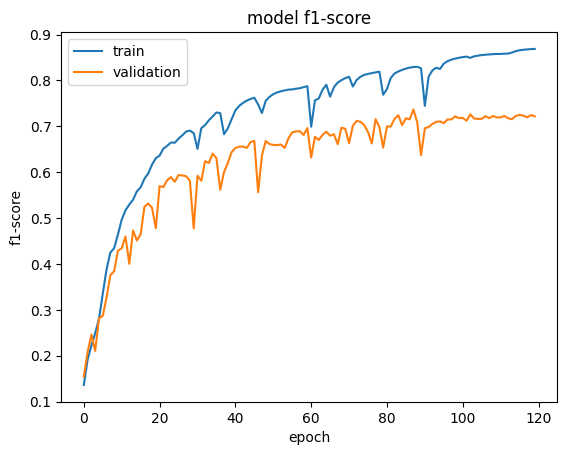

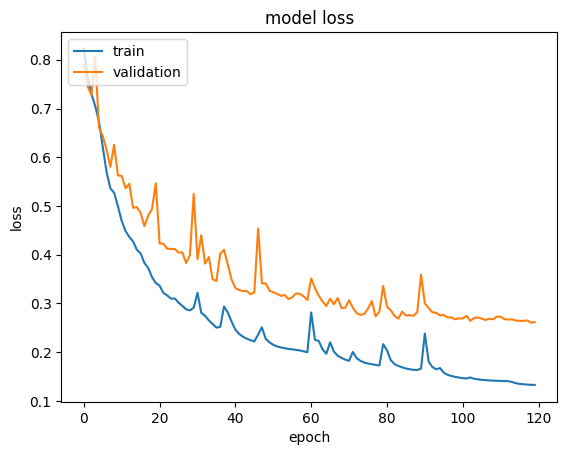

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'patch_expanding_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'patch_expanding_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'patch_expanding_7', however t

NameError: name 'optimizer' is not defined

In [ ]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
#del X_train1, X_train2, y_train
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [16]

# Epochs. The number of iterations the model will train.
epochs = 120
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = Siamese_SwinUnet(input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1))
            #model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics, run_eagerly=False)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = None
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'my_saved_Siamese_CSA'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

            model_path = f'/content/drive/MyDrive/landslide/Results/weights/Siamese_SwinUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(model_path,
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True)
            plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=10, min_lr=1e-5, verbose=1)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, plateau, tensorboard_callback],
                verbose=1
            )
            final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
            print(f"Final learning rate: {final_lr:.2e}")
            training_time = time.time() - start_time

            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese_SwinUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese_SwinUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = Siamese_SwinUnet( input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1))
            load_Attunet.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(model_path)

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("Siamese_SwinUnet")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_Siamese_SwinUnet.csv', index = False)

## MODEL SIAMESE SWINUNET WITH DEPTH = 4 AND MLP=512

In [ ]:
# Size of the tiles/patches
size1 = 256 # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = 256

# Image bands
img_bands1 = 11 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.

In [ ]:
def make_swin_unet_encoder(input_size=(size1,size1,img_bands1),
                           filter_num_begin=64,
                           depth=4,
                           stack_num_down=2,
                           patch_size=(4,4),
                           num_heads=[4,8,8,8],
                           window_size=[4,2,2,2],
                           num_mlp=512,
                           shift_window=True):

    # 1) build the “base” exactly as in your swin_unet_2d_base,
    # but stop right after collecting the X_skip list.
    IN = Input(input_size, name='encoder_input')
    X = IN

    # patch extract & embed
    num_patch_x = input_size[0] // patch_size[0]
    num_patch_y = input_size[1] // patch_size[1]
    embed_dim = filter_num_begin

    X = patch_extract(patch_size)(X)
    X = patch_embedding(num_patch_x*num_patch_y, embed_dim)(X)

    X_skip = []
    # first stack
    X = swin_transformer_stack(X, stack_num_down,
                               embed_dim, (num_patch_x,num_patch_y),
                               num_heads[0], window_size[0],
                               num_mlp, shift_window,
                               name='down0')
    X_skip.append(X)

    # downsampling
    for i in range(depth-1):
        X = patch_merging((num_patch_x,num_patch_y),
                          embed_dim, name=f'down_merge{i}')(X)
        embed_dim *= 2
        num_patch_x //= 2;  num_patch_y //= 2

        X = swin_transformer_stack(X, stack_num_down,
                                   embed_dim, (num_patch_x,num_patch_y),
                                   num_heads[i+1], window_size[i+1],
                                   num_mlp, shift_window,
                                   name=f'down{i+1}')
        X_skip.append(X)

    # X_skip = [level0, level1, … level{depth-1}]
    # we will reverse so that X_skip[0] is the deepest
    X_skip = X_skip[::-1]

    # make an encoder model that outputs *all* skip‑tensors
    encoder = Model(inputs=IN,
                    outputs=X_skip,
                    name='swin_unet_encoder')
    return encoder

In [ ]:
def make_swin_unet_decoder(patch_size=(4,4),
                           stack_num_up=2,
                           num_heads=[8,8,4],       # reversed from encoder
                           window_size=[2,2,4],
                           num_mlp=512,
                           shift_window=True,
                           n_labels=1,
                           output_activation='Sigmoid'):

    # 1) define one Input() per skip‑tensor:
    #    deepest latent, then the three skip‑levels above it.
    #    Shapes must match exactly what the encoder spits out.
    deep = Input((64, 512),   name='latent_in')   # 8×8 patches × dim=512
    skip2 = Input((256, 256),   name='skip2_in')   # 16×16 patches × dim=256
    skip1 = Input((1024, 128),   name='skip1_in')   # 32×32 patches × dim=128
    skip0 = Input((4096,  64),   name='skip0_in')   # 64×64 patches × dim= 64

    X = deep
    embed_dim = 512
    num_patch = (8,8)

    # --- Decoder Stage 0 ---
    X = patch_expanding(num_patch=num_patch,
                        embed_dim=embed_dim,
                        upsample_rate=2,
                        return_vector=True,
                        name='swin_up0')(X)
    # now: tokens=256, dim=256
    embed_dim //= 2        # → 256
    num_patch = (num_patch[0]*2, num_patch[1]*2)  # → (16,16)

    X = concatenate([X, skip2], axis=-1, name='concat0')
    X = Dense(embed_dim, use_bias=False, name='proj0')(X)
    X = swin_transformer_stack(X, stack_num_up,
                               embed_dim, num_patch,
                               num_heads[0], window_size[0],
                               num_mlp, shift_window,
                               name='up0')

    # --- Decoder Stage 1 ---
    X = patch_expanding(num_patch=num_patch,
                        embed_dim=embed_dim,
                        upsample_rate=2,
                        return_vector=True,
                        name='swin_up1')(X)
    embed_dim //= 2        # → 128
    num_patch = (num_patch[0]*2, num_patch[1]*2)  # → (32,32)

    X = concatenate([X, skip1], axis=-1, name='concat1')
    X = Dense(embed_dim, use_bias=False, name='proj1')(X)
    X = swin_transformer_stack(X, stack_num_up,
                               embed_dim, num_patch,
                               num_heads[1], window_size[1],
                               num_mlp, shift_window,
                               name='up1')

    # --- Decoder Stage 2 ---
    X = patch_expanding(num_patch=num_patch,
                        embed_dim=embed_dim,
                        upsample_rate=2,
                        return_vector=True,
                        name='swin_up2')(X)
    embed_dim //= 2        # →  64
    num_patch = (num_patch[0]*2, num_patch[1]*2)  # → (64,64)

    X = concatenate([X, skip0], axis=-1, name='concat2')
    X = Dense(embed_dim, use_bias=False, name='proj2')(X)
    X = swin_transformer_stack(X, stack_num_up,
                               embed_dim, num_patch,
                               num_heads[2], window_size[2],
                               num_mlp, shift_window,
                               name='up2')

    # --- Final Expanding to Image ---
    X = patch_expanding(num_patch=num_patch,
                        embed_dim=embed_dim,
                        upsample_rate=patch_size[0],
                        return_vector=False,
                        name='swin_up_last')(X)
    # X is now (None, 256, 256, C) – ready for conv
    OUT = CONV_output(X, n_labels,
                      kernel_size=1,
                      activation=output_activation,
                      name='decoder_output')

    decoder = Model(inputs=[deep, skip2, skip1, skip0],
                    outputs=OUT,
                    name='swin_unet_decoder')
    return decoder


In [ ]:
def Siamese_SwinUnet( input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1)):

    #Define the inputs
    input_1 = Input(shape=input_size1, name='input_1')  # Pre-event optical
    input_2 = Input(shape=input_size2, name='input_2')  # Post-event optical
    # 2. Create Encoder and Decoder
    encoder = make_swin_unet_encoder(input_size= input_size1,
                              filter_num_begin=64,
                              depth=4,
                              stack_num_down=2,
                              patch_size=(4,4),
                              num_heads=[4,8,8,8],
                              window_size=[4,2,2,2],
                              num_mlp=512,
                              shift_window=True)
    deep_1, skip2_1, skip1_1, skip0_1 = encoder(input_1)
    deep_2, skip2_2, skip1_2, skip0_2 = encoder(input_2)

    deep_fused = keras.layers.Add()([deep_1, deep_2])

    # Assuming a corresponding decoder architecture
    decoder = make_swin_unet_decoder(patch_size=(4, 4),
                                  stack_num_up=2,
                                  num_heads=[8,8,4],       # reversed from encoder
                                  window_size=[2,2,4],
                                  num_mlp=512,         # Reduce MLP size
                                  shift_window=True,
                                  n_labels=1,         # 10 classes for MNIST
                                  output_activation='Sigmoid') # Multi-class classification
    # 3. Connect Encoder and Decoder

    decoder_output_1 = decoder([deep_fused, skip2_1, skip1_1, skip0_1])
    decoder_output_2 = decoder([deep_fused, skip2_2, skip1_2, skip0_2])
    decoder_output_fused = keras.layers.Multiply()([decoder_output_1, decoder_output_2])

    return Model(inputs=[input_1, input_2], outputs=decoder_output_fused)

In [ ]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
#del X_train1, X_train2, y_train
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [16]

# Epochs. The number of iterations the model will train.
epochs = 120
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = Siamese_SwinUnet(input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1))
            #model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics, run_eagerly=False)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = None
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'my_saved_Siamese_CSA'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

            model_path = f'/content/drive/MyDrive/landslide/Results/weights/Siamese_SwinUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(model_path,
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True)
            plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=10, min_lr=1e-5, verbose=1)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, plateau, tensorboard_callback],
                verbose=1
            )
            final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
            print(f"Final learning rate: {final_lr:.2e}")
            training_time = time.time() - start_time

            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese_SwinUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Siamese_SwinUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = Siamese_SwinUnet( input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1))
            load_Attunet.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(model_path)

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("Siamese_SwinUnet")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_Siamese_SwinUnet.csv', index = False)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'patch_expanding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'patch_expanding_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'patch_expanding_2', however the

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_2             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_unet_encoder   │ [(None, 16,       │ 22,406,024 │ input_1[0][0],    │
│ (Functional)        │ 1024), (None, 64, │            │ input_2[0][0]     │
│                     │ 512), (None, 256, │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 1024, 128),       │            │                   │
│                     │ (None, 4096, 64)] │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_unet_decoder   │ (None, 256, 256,  │ 10,241,737 │ swin_unet_encode… │
│ (Functional)        │ 1)                │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
│                     │                   │            │ swin_unet_encode… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 256, 256,  │          0 │ swin_unet_decode… │
│                     │ 1)                │            │ swin_unet_decode… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,647,761 (124.54 MB)

 Trainable params: 32,647,761 (124.54 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 506 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/120


## MODEL TRANSUNET

In [ ]:
with tf.device('/CPU:0'):
    val_dataset = tf.data.Dataset.from_tensor_slices(( X_val2, y_val))
    test_dataset = tf.data.Dataset.from_tensor_slices((X_test2, y_test))

In [ ]:
del X_val2, y_val, X_test2, y_test

In [ ]:
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train2, y_train))

In [ ]:
del  X_train2, y_train

In [ ]:
!pip install keras-unet-collection -q -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 7.6 MB/s eta 0:00:00


In [ ]:
# Shuffle and batch the dataset
batch_size = 4  # Adjust based on your needs
train_dataset = train_dataset.shuffle(buffer_size=2443).cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
from __future__ import absolute_import

from keras_unet_collection.layer_utils import *
from keras_unet_collection.activations import GELU, Snake
from keras_unet_collection._model_unet_2d import UNET_left, UNET_right
from keras_unet_collection.transformer_layers import patch_extract, patch_embedding
from keras_unet_collection._backbone_zoo import backbone_zoo, bach_norm_checker

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, MultiHeadAttention, LayerNormalization, Dense, Embedding

In [ ]:
# Size of the tiles/patches
size1 = 256 # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = 256

# Image bands
img_bands1 = 11 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.

In [ ]:
def ViT_MLP(X, filter_num, activation='GELU', name='MLP'):

    activation_func = eval(activation)

    for i, f in enumerate(filter_num):
        X = Dense(f, name='{}_dense_{}'.format(name, i))(X)
        X = activation_func(name='{}_activation_{}'.format(name, i))(X)

    return X

def ViT_block(V, num_heads, key_dim, filter_num_MLP, activation='GELU', name='ViT'):

    # Multiheaded self-attention (MSA)
    V_atten = V # <--- skip
    V_atten = LayerNormalization(name='{}_layer_norm_1'.format(name))(V_atten)
    V_atten = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim,
                                 name='{}_atten'.format(name))(V_atten, V_atten)
    # Skip connection
    V_add = add([V_atten, V], name='{}_skip_1'.format(name)) # <--- skip

    # MLP
    V_MLP = V_add # <--- skip
    V_MLP = LayerNormalization(name='{}_layer_norm_2'.format(name))(V_MLP)
    V_MLP = ViT_MLP(V_MLP, filter_num_MLP, activation, name='{}_mlp'.format(name))
    # Skip connection
    V_out = add([V_MLP, V_add], name='{}_skip_2'.format(name)) # <--- skip

    return V_out


def transunet_2d_base(input_tensor, filter_num, stack_num_down=2, stack_num_up=2,
                      embed_dim=768, num_mlp=3072, num_heads=12, num_transformer=12,
                      activation='ReLU', mlp_activation='GELU', batch_norm=False, pool=True, unpool=True,
                      backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='transunet'):

    activation_func = eval(activation)

    X_skip = []
    depth_ = len(filter_num)

    # ----- internal parameters ----- #

    # patch size (fixed to 1-by-1)
    patch_size = 1

    # input tensor size
    input_size = input_tensor.shape[1]

    # encoded feature map size
    encode_size = input_size // 2**(depth_-1)

    # number of size-1 patches
    num_patches = encode_size ** 2

    # dimension of the attention key (= dimension of embedings)
    key_dim = embed_dim

    # number of MLP nodes
    filter_num_MLP = [num_mlp, embed_dim]

    # ----- UNet-like downsampling ----- #

    # no backbone cases
    if backbone is None:

        X = input_tensor

        # stacked conv2d before downsampling
        X = CONV_stack(X, filter_num[0], stack_num=stack_num_down, activation=activation,
                       batch_norm=batch_norm, name='{}_down0'.format(name))
        X_skip.append(X)

        # downsampling blocks
        for i, f in enumerate(filter_num[1:]):
            X = UNET_left(X, f, stack_num=stack_num_down, activation=activation, pool=pool,
                          batch_norm=batch_norm, name='{}_down{}'.format(name, i+1))
            X_skip.append(X)

    # backbone cases
    else:
        # handling VGG16 and VGG19 separately
        if 'VGG' in backbone:
            backbone_ = backbone_zoo(backbone, weights, input_tensor, depth_, freeze_backbone, freeze_batch_norm)
            # collecting backbone feature maps
            X_skip = backbone_([input_tensor,])
            depth_encode = len(X_skip)

        # for other backbones
        else:
            backbone_ = backbone_zoo(backbone, weights, input_tensor, depth_-1, freeze_backbone, freeze_batch_norm)
            # collecting backbone feature maps
            X_skip = backbone_([input_tensor,])
            depth_encode = len(X_skip) + 1


        # extra conv2d blocks are applied
        # if downsampling levels of a backbone < user-specified downsampling levels
        if depth_encode < depth_:

            # begins at the deepest available tensor
            X = X_skip[-1]

            # extra downsamplings
            for i in range(depth_-depth_encode):
                i_real = i + depth_encode

                X = UNET_left(X, filter_num[i_real], stack_num=stack_num_down, activation=activation, pool=pool,
                              batch_norm=batch_norm, name='{}_down{}'.format(name, i_real+1))
                X_skip.append(X)

    # subtrack the last tensor (will be replaced by the ViT output)
    X = X_skip[-1]
    X_skip = X_skip[:-1]

    # 1-by-1 linear transformation before entering ViT blocks
    X = Conv2D(filter_num[-1], 1, padding='valid', use_bias=False, name='{}_conv_trans_before'.format(name))(X)

    X = patch_extract((patch_size, patch_size))(X)
    X = patch_embedding(num_patches, embed_dim)(X)

    # stacked ViTs
    for i in range(num_transformer):
        X = ViT_block(X, num_heads, key_dim, filter_num_MLP, activation=mlp_activation,
                      name='{}_ViT_{}'.format(name, i))

    # reshape patches to feature maps
    X = tf.keras.layers.Reshape((encode_size, encode_size, embed_dim))(X)

    # 1-by-1 linear transformation to adjust the number of channels
    X = Conv2D(filter_num[-1], 1, padding='valid', use_bias=False, name='{}_conv_trans_after'.format(name))(X)

    X_skip.append(X)

    # ----- UNet-like upsampling ----- #

    # reverse indexing encoded feature maps
    X_skip = X_skip[::-1]
    # upsampling begins at the deepest available tensor
    X = X_skip[0]
    # other tensors are preserved for concatenation
    X_decode = X_skip[1:]
    depth_decode = len(X_decode)

    # reverse indexing filter numbers
    filter_num_decode = filter_num[:-1][::-1]

    # upsampling with concatenation
    for i in range(depth_decode):
        X = UNET_right(X, [X_decode[i],], filter_num_decode[i], stack_num=stack_num_up, activation=activation,
                       unpool=unpool, batch_norm=batch_norm, name='{}_up{}'.format(name, i))

    # if tensors for concatenation is not enough
    # then use upsampling without concatenation
    if depth_decode < depth_-1:
        for i in range(depth_-depth_decode-1):
            i_real = i + depth_decode
            X = UNET_right(X, None, filter_num_decode[i_real], stack_num=stack_num_up, activation=activation,
                       unpool=unpool, batch_norm=batch_norm, concat=False, name='{}_up{}'.format(name, i_real))

    return X

def transunet_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2,
                 embed_dim=768, num_mlp = 3072, num_heads=12, num_transformer=12,
                 activation='ReLU', mlp_activation='GELU', output_activation='Softmax', batch_norm=False, pool=True, unpool=True,
                 backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='transunet'):

    activation_func = eval(activation)

    IN = Input(input_size)

    # base
    X = transunet_2d_base(IN, filter_num, stack_num_down=stack_num_down, stack_num_up=stack_num_up,
                          embed_dim=embed_dim, num_mlp=num_mlp, num_heads=num_heads, num_transformer=num_transformer,
                          activation=activation, mlp_activation=mlp_activation, batch_norm=batch_norm, pool=pool, unpool=unpool,
                          backbone=backbone, weights=weights, freeze_backbone=freeze_backbone, freeze_batch_norm=freeze_batch_norm, name=name)

    # output layer
    OUT = CONV_output(X, n_labels, kernel_size=1, activation=output_activation, name='{}_output'.format(name))

    # functional API model
    model = Model(inputs=IN, outputs=OUT, name='{}_model'.format(name))

    return model

In [ ]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
#del X_train1, X_train2, y_train
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 110
#Last epochs where the models got stopped
previous_epoch = 27
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = transunet_2d(
                                  (size1,size1,img_bands1),
                                  filter_num=[64, 128, 256, 512, 1024],
                                  n_labels=1,
                                  stack_num_down=2,
                                  stack_num_up=2,
                                  embed_dim=512,           # Reduced from 1024
                                  num_mlp=2048,            # 4 × embed_dim (512 * 4 = 2048)
                                  num_heads=8,             # embed_dim // 64 (512 / 64 = 8)
                                  num_transformer=6,       # Reduced from 12
                                  activation='ReLU',
                                  mlp_activation='GELU',
                                  output_activation='Sigmoid',
                                  batch_norm=True,
                                  pool=True,
                                  unpool='bilinear',
                                  name='transunet'
                              )
            #model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics, run_eagerly=False)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = f'/content/drive/MyDrive/landslide/Results/weights/transunet_2d_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'transunet_2d'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

            model_path = f'/content/drive/MyDrive/landslide/Results/weights/transunet_2d_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(model_path,
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True)
            plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=10, min_lr=1e-5, verbose=1)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, plateau, tensorboard_callback],
                verbose=1
            )
            final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
            print(f"Final learning rate: {final_lr:.2e}")
            training_time = time.time() - start_time

            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/transunet_2d_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/transunet_2d_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = transunet_2d(
                                  (size1,size1,img_bands1),
                                  filter_num=[64, 128, 256, 512, 1024],
                                  n_labels=1,
                                  stack_num_down=2,
                                  stack_num_up=2,
                                  embed_dim=512,           # Reduced from 1024
                                  num_mlp=2048,            # 4 × embed_dim (512 * 4 = 2048)
                                  num_heads=8,             # embed_dim // 64 (512 / 64 = 8)
                                  num_transformer=6,       # Reduced from 12
                                  activation='ReLU',
                                  mlp_activation='GELU',
                                  output_activation='Sigmoid',
                                  batch_norm=True,
                                  pool=True,
                                  unpool='bilinear',
                                  name='transunet'
                              )
            load_Attunet.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(model_path)

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("transunet_2d")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_transunet_2d.csv', index = False)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "transunet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down0_0   │ (None, 256, 256,  │      6,336 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down0_0_… │ (None, 256, 256,  │        256 │ transunet_down0_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down0_0_… │ (None, 256, 256,  │          0 │ transunet_down0_… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down0_1   │ (None, 256, 256,  │     36,864 │ transunet_down0_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down0_1_… │ (None, 256, 256,  │        256 │ transunet_down0_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down0_1_… │ (None, 256, 256,  │          0 │ transunet_down0_… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_en… │ (None, 128, 128,  │          0 │ transunet_down0_… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_co… │ (None, 128, 128,  │     73,728 │ transunet_down1_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_co… │ (None, 128, 128,  │        512 │ transunet_down1_… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_co… │ (None, 128, 128,  │          0 │ transunet_down1_… │
│ (ReLU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_co… │ (None, 128, 128,  │    147,456 │ transunet_down1_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_co… │ (None, 128, 128,  │        512 │ transunet_down1_… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_co… │ (None, 128, 128,  │          0 │ transunet_down1_… │
│ (ReLU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down2_en… │ (None, 64, 64,    │          0 │ transunet_down1_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down2_co… │ (None, 64, 64,    │    294,912 │ transunet_down2_… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down2_co… │ (None, 64, 64,    │      1,024 │ transunet_down2_

 Total params: 99,786,241 (380.65 MB)

 Trainable params: 99,772,545 (380.60 MB)

 Non-trainable params: 13,696 (53.50 KB)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 340 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 28/110
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - IoU: 0.3240 - accuracy: 0.9463 - f1-score: 0.4797 - loss: 0.4727 - precision: 0.4015 - recall: 0.6417
Epoch 28: val_loss improved from inf to 0.50888, saving model to /content/drive/MyDrive/landslide/Results/weights/transunet_2d_size_256_filters_64_batch_size_4_lr_0.0001.keras
611/611 ━━━━━━━━━━━━━━━━━━━━ 298s 350ms/step - IoU: 0.3240 - accuracy: 0.9463 - f1-score: 0.4797 - loss: 0.4727 - precision: 0.4015 - recall: 0.6417 - val_IoU: 0.2954 - val_accuracy: 0.9406 - val_f1-score: 0.4471 - val_loss: 0.5089 - val_precision: 0.3771 - val_recall: 0.6035 - learning_rate: 1.0000e-04
Epoch 29/110
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - IoU: 0.3448 - accuracy: 0.9501 - f1-score: 0.5034 - loss: 0.4507 - precision: 0.4250 - recall: 0.6551
Epoch 29: val_loss improved from 0.50888 to 0.49856, saving model to /content/drive/MyDrive/landslide/Results/weights/transunet_2d_size_256_filters_64_batch_size_4_lr_0.0001.keras
611/611 ━━━━━━━━━━━

In [ ]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
#del X_train1, X_train2, y_train
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 110
#Last epochs where the models got stopped
previous_epoch = 27
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)

            model_path = f'/content/drive/MyDrive/landslide/Results/weights/transunet_2d_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            # load unet to evaluate the test data
            load_Attunet = transunet_2d(
                                  (size1,size1,img_bands1),
                                  filter_num=[64, 128, 256, 512, 1024],
                                  n_labels=1,
                                  stack_num_down=2,
                                  stack_num_up=2,
                                  embed_dim=512,           # Reduced from 1024
                                  num_mlp=2048,            # 4 × embed_dim (512 * 4 = 2048)
                                  num_heads=8,             # embed_dim // 64 (512 / 64 = 8)
                                  num_transformer=6,       # Reduced from 12
                                  activation='ReLU',
                                  mlp_activation='GELU',
                                  output_activation='Sigmoid',
                                  batch_norm=True,
                                  pool=True,
                                  unpool='bilinear',
                                  name='transunet'
                              )
            load_Attunet.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(model_path)

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("transunet_2d")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_transunet_2d.csv', index = False)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 340 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


82/82 ━━━━━━━━━━━━━━━━━━━━ 44s 241ms/step - IoU: 0.3888 - accuracy: 0.9608 - f1-score: 0.5517 - loss: 0.4267 - precision: 0.5137 - recall: 0.6217


## MODEL  SDUNET (TRANSUNET with topo images)

In [ ]:
with tf.device('/CPU:0'):
    X_train2 =tf.concat([X_train2, X_train3], axis=-1)

In [ ]:
with tf.device('/CPU:0'):
    X_val2 =tf.concat([X_val2, X_val3], axis=-1)
    X_test2 =tf.concat([X_test2, X_test3], axis=-1)

In [ ]:
del X_val3, X_test3, X_train3

In [ ]:
with tf.device('/CPU:0'):
    val_dataset = tf.data.Dataset.from_tensor_slices(( X_val2, y_val))
    test_dataset = tf.data.Dataset.from_tensor_slices((X_test2, y_test))

In [ ]:
del X_val2, y_val, X_test2, y_test

In [ ]:
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train2, y_train))

In [ ]:
del X_train2, y_train

In [ ]:
!pip install keras-unet-collection -q -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.8 MB/s eta 0:00:00


In [ ]:
# Shuffle and batch the dataset
batch_size = 4  # Adjust based on your needs
train_dataset = train_dataset.shuffle(buffer_size=2443).cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
from __future__ import absolute_import

from keras_unet_collection.layer_utils import *
from keras_unet_collection.activations import GELU, Snake
from keras_unet_collection._model_unet_2d import UNET_left, UNET_right
from keras_unet_collection.transformer_layers import patch_extract, patch_embedding
from keras_unet_collection._backbone_zoo import backbone_zoo, bach_norm_checker

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, MultiHeadAttention, LayerNormalization, Dense, Embedding

In [ ]:
# Size of the tiles/patches
size1 = 256 # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = 256

# Image bands
img_bands1 = 17 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.

In [ ]:
def ViT_MLP(X, filter_num, activation='GELU', name='MLP'):

    activation_func = eval(activation)

    for i, f in enumerate(filter_num):
        X = Dense(f, name='{}_dense_{}'.format(name, i))(X)
        X = activation_func(name='{}_activation_{}'.format(name, i))(X)

    return X

def ViT_block(V, num_heads, key_dim, filter_num_MLP, activation='GELU', name='ViT'):

    # Multiheaded self-attention (MSA)
    V_atten = V # <--- skip
    V_atten = LayerNormalization(name='{}_layer_norm_1'.format(name))(V_atten)
    V_atten = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim,
                                 name='{}_atten'.format(name))(V_atten, V_atten)
    # Skip connection
    V_add = add([V_atten, V], name='{}_skip_1'.format(name)) # <--- skip

    # MLP
    V_MLP = V_add # <--- skip
    V_MLP = LayerNormalization(name='{}_layer_norm_2'.format(name))(V_MLP)
    V_MLP = ViT_MLP(V_MLP, filter_num_MLP, activation, name='{}_mlp'.format(name))
    # Skip connection
    V_out = add([V_MLP, V_add], name='{}_skip_2'.format(name)) # <--- skip

    return V_out


def transunet_2d_base(input_tensor, filter_num, stack_num_down=2, stack_num_up=2,
                      embed_dim=768, num_mlp=3072, num_heads=12, num_transformer=12,
                      activation='ReLU', mlp_activation='GELU', batch_norm=False, pool=True, unpool=True,
                      backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='transunet'):

    activation_func = eval(activation)

    X_skip = []
    depth_ = len(filter_num)

    # ----- internal parameters ----- #

    # patch size (fixed to 1-by-1)
    patch_size = 1

    # input tensor size
    input_size = input_tensor.shape[1]

    # encoded feature map size
    encode_size = input_size // 2**(depth_-1)

    # number of size-1 patches
    num_patches = encode_size ** 2

    # dimension of the attention key (= dimension of embedings)
    key_dim = embed_dim

    # number of MLP nodes
    filter_num_MLP = [num_mlp, embed_dim]

    # ----- UNet-like downsampling ----- #

    # no backbone cases
    if backbone is None:

        X = input_tensor

        # stacked conv2d before downsampling
        X = CONV_stack(X, filter_num[0], stack_num=stack_num_down, activation=activation,
                       batch_norm=batch_norm, name='{}_down0'.format(name))
        X_skip.append(X)

        # downsampling blocks
        for i, f in enumerate(filter_num[1:]):
            X = UNET_left(X, f, stack_num=stack_num_down, activation=activation, pool=pool,
                          batch_norm=batch_norm, name='{}_down{}'.format(name, i+1))
            X_skip.append(X)

    # backbone cases
    else:
        # handling VGG16 and VGG19 separately
        if 'VGG' in backbone:
            backbone_ = backbone_zoo(backbone, weights, input_tensor, depth_, freeze_backbone, freeze_batch_norm)
            # collecting backbone feature maps
            X_skip = backbone_([input_tensor,])
            depth_encode = len(X_skip)

        # for other backbones
        else:
            backbone_ = backbone_zoo(backbone, weights, input_tensor, depth_-1, freeze_backbone, freeze_batch_norm)
            # collecting backbone feature maps
            X_skip = backbone_([input_tensor,])
            depth_encode = len(X_skip) + 1


        # extra conv2d blocks are applied
        # if downsampling levels of a backbone < user-specified downsampling levels
        if depth_encode < depth_:

            # begins at the deepest available tensor
            X = X_skip[-1]

            # extra downsamplings
            for i in range(depth_-depth_encode):
                i_real = i + depth_encode

                X = UNET_left(X, filter_num[i_real], stack_num=stack_num_down, activation=activation, pool=pool,
                              batch_norm=batch_norm, name='{}_down{}'.format(name, i_real+1))
                X_skip.append(X)

    # subtrack the last tensor (will be replaced by the ViT output)
    X = X_skip[-1]
    X_skip = X_skip[:-1]

    # 1-by-1 linear transformation before entering ViT blocks
    X = Conv2D(filter_num[-1], 1, padding='valid', use_bias=False, name='{}_conv_trans_before'.format(name))(X)

    X = patch_extract((patch_size, patch_size))(X)
    X = patch_embedding(num_patches, embed_dim)(X)

    # stacked ViTs
    for i in range(num_transformer):
        X = ViT_block(X, num_heads, key_dim, filter_num_MLP, activation=mlp_activation,
                      name='{}_ViT_{}'.format(name, i))

    # reshape patches to feature maps
    X = tf.keras.layers.Reshape((encode_size, encode_size, embed_dim))(X)

    # 1-by-1 linear transformation to adjust the number of channels
    X = Conv2D(filter_num[-1], 1, padding='valid', use_bias=False, name='{}_conv_trans_after'.format(name))(X)

    X_skip.append(X)

    # ----- UNet-like upsampling ----- #

    # reverse indexing encoded feature maps
    X_skip = X_skip[::-1]
    # upsampling begins at the deepest available tensor
    X = X_skip[0]
    # other tensors are preserved for concatenation
    X_decode = X_skip[1:]
    depth_decode = len(X_decode)

    # reverse indexing filter numbers
    filter_num_decode = filter_num[:-1][::-1]

    # upsampling with concatenation
    for i in range(depth_decode):
        X = UNET_right(X, [X_decode[i],], filter_num_decode[i], stack_num=stack_num_up, activation=activation,
                       unpool=unpool, batch_norm=batch_norm, name='{}_up{}'.format(name, i))

    # if tensors for concatenation is not enough
    # then use upsampling without concatenation
    if depth_decode < depth_-1:
        for i in range(depth_-depth_decode-1):
            i_real = i + depth_decode
            X = UNET_right(X, None, filter_num_decode[i_real], stack_num=stack_num_up, activation=activation,
                       unpool=unpool, batch_norm=batch_norm, concat=False, name='{}_up{}'.format(name, i_real))

    return X

def transunet_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2,
                 embed_dim=768, num_mlp = 3072, num_heads=12, num_transformer=12,
                 activation='ReLU', mlp_activation='GELU', output_activation='Softmax', batch_norm=False, pool=True, unpool=True,
                 backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='transunet'):

    activation_func = eval(activation)

    IN = Input(input_size)

    # base
    X = transunet_2d_base(IN, filter_num, stack_num_down=stack_num_down, stack_num_up=stack_num_up,
                          embed_dim=embed_dim, num_mlp=num_mlp, num_heads=num_heads, num_transformer=num_transformer,
                          activation=activation, mlp_activation=mlp_activation, batch_norm=batch_norm, pool=pool, unpool=unpool,
                          backbone=backbone, weights=weights, freeze_backbone=freeze_backbone, freeze_batch_norm=freeze_batch_norm, name=name)

    # output layer
    OUT = CONV_output(X, n_labels, kernel_size=1, activation=output_activation, name='{}_output'.format(name))

    # functional API model
    model = Model(inputs=IN, outputs=OUT, name='{}_model'.format(name))

    return model

In [ ]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
#del X_train1, X_train2, y_train
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 120
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = transunet_2d(
                                  (size1,size1,img_bands1),
                                  filter_num=[64, 128, 256, 512, 1024],
                                  n_labels=1,
                                  stack_num_down=2,
                                  stack_num_up=2,
                                  embed_dim=512,           # Reduced from 1024
                                  num_mlp=2048,            # 4 × embed_dim (512 * 4 = 2048)
                                  num_heads=8,             # embed_dim // 64 (512 / 64 = 8)
                                  num_transformer=8,       # Reduced from 12
                                  activation='ReLU',
                                  mlp_activation='GELU',
                                  output_activation='Sigmoid',
                                  batch_norm=True,
                                  pool=True,
                                  unpool='bilinear',
                                  name='transunet'
                              )
            #model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics, run_eagerly=False)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = None
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'transunet_2d'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

            model_path = f'/content/drive/MyDrive/landslide/Results/weights/transunet2_2d_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(model_path,
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True)
            plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=10, min_lr=1e-5, verbose=1)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, plateau, tensorboard_callback],
                verbose=1
            )
            final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
            print(f"Final learning rate: {final_lr:.2e}")
            training_time = time.time() - start_time

            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/transunet2_2d_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/transunet2_2d_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = transunet_2d(
                                  (size1,size1,img_bands1),
                                  filter_num=[64, 128, 256, 512, 1024],
                                  n_labels=1,
                                  stack_num_down=2,
                                  stack_num_up=2,
                                  embed_dim=512,           # Reduced from 1024
                                  num_mlp=2048,            # 4 × embed_dim (512 * 4 = 2048)
                                  num_heads=8,             # embed_dim // 64 (512 / 64 = 8)
                                  num_transformer=8,       # Reduced from 12
                                  activation='ReLU',
                                  mlp_activation='GELU',
                                  output_activation='Sigmoid',
                                  batch_norm=True,
                                  pool=True,
                                  unpool='bilinear',
                                  name='transunet'
                              )
            load_Attunet.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(model_path)

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("transunet2_2d")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_transunet2_2d.csv', index = False)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "transunet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 17)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down0_0   │ (None, 256, 256,  │      9,792 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down0_0_… │ (None, 256, 256,  │        256 │ transunet_down0_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down0_0_… │ (None, 256, 256,  │          0 │ transunet_down0_… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down0_1   │ (None, 256, 256,  │     36,864 │ transunet_down0_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down0_1_… │ (None, 256, 256,  │        256 │ transunet_down0_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down0_1_… │ (None, 256, 256,  │          0 │ transunet_down0_… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_en… │ (None, 128, 128,  │          0 │ transunet_down0_… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_co… │ (None, 128, 128,  │     73,728 │ transunet_down1_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_co… │ (None, 128, 128,  │        512 │ transunet_down1_… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_co… │ (None, 128, 128,  │          0 │ transunet_down1_… │
│ (ReLU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_co… │ (None, 128, 128,  │    147,456 │ transunet_down1_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_co… │ (None, 128, 128,  │        512 │ transunet_down1_… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down1_co… │ (None, 128, 128,  │          0 │ transunet_down1_… │
│ (ReLU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down2_en… │ (None, 64, 64,    │          0 │ transunet_down1_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down2_co… │ (None, 64, 64,    │    294,912 │ transunet_down2_… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transunet_down2_co… │ (None, 64, 64,    │      1,024 │ transunet_down2_

 Total params: 120,796,033 (460.80 MB)

 Trainable params: 120,782,337 (460.75 MB)

 Non-trainable params: 13,696 (53.50 KB)

Epoch 1/120
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - IoU: 0.1607 - accuracy: 0.8264 - f1-score: 0.2657 - loss: 0.7062 - precision: 0.1819 - recall: 0.6802
Epoch 1: val_loss improved from inf to 0.70749, saving model to /content/drive/MyDrive/landslide/Results/weights/transunet2_2d_size_256_filters_64_batch_size_4_lr_0.0001.keras
611/611 ━━━━━━━━━━━━━━━━━━━━ 314s 376ms/step - IoU: 0.1608 - accuracy: 0.8265 - f1-score: 0.2658 - loss: 0.7061 - precision: 0.1820 - recall: 0.6802 - val_IoU: 0.1340 - val_accuracy: 0.7582 - val_f1-score: 0.2297 - val_loss: 0.7075 - val_precision: 0.1422 - val_recall: 0.7720 - learning_rate: 1.0000e-04
Epoch 2/120
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - IoU: 0.2241 - accuracy: 0.9169 - f1-score: 0.3564 - loss: 0.6067 - precision: 0.2756 - recall: 0.6003
Epoch 2: val_loss improved from 0.70749 to 0.59386, saving model to /content/drive/MyDrive/landslide/Results/weights/transunet2_2d_size_256_filters_64_batch_size_4_lr_0.0001.keras
611/611 ━━━━━━━━━━━━━

## MODEL BBUNET

In [ ]:
import tensorflow as tf
from tensorflow import keras

## Limit GPU Memory in TensorFlow
## Because TensorFlow, by default, allocates the full amount of available GPU memory when it is launched.
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)
        print('{} memory growth: {}'.format(device, tf.config.experimental.get_memory_growth(device)))
else:
    print("Not enough GPU hardware devices available")

PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU') memory growth: True


In [ ]:
with tf.device('/CPU:0'):
    val_dataset = tf.data.Dataset.from_tensor_slices(((X_val1, X_val2, X_val3), y_val))
    test_dataset = tf.data.Dataset.from_tensor_slices(((X_test1, X_test2, X_test3), y_test))

In [ ]:
del X_val1, X_val2, X_val3, y_val, X_test1, X_test2, X_test3, y_test

In [ ]:
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices(((X_train1, X_train2, X_train3), y_train))

In [ ]:
del X_train1, X_train2, X_train3, y_train

In [ ]:
# Shuffle and batch the dataset
batch_size = 4  # Adjust based on your needs
train_dataset = train_dataset.shuffle(buffer_size=2443).cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
size1 = 256
img_bands1= 11
size2 = 256
img_bands2 = 6

In [ ]:
import os
import numpy as np
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers, ops
from tensorflow.keras.layers import Conv2D, BatchNormalization, ReLU, Add, Subtract, Concatenate, Dropout, MaxPooling2D, Conv2DTranspose, ReLU, Concatenate, Activation, Input
from tensorflow.keras.models import Model

In [ ]:
# Common building blocks
def conv_block(x, filters, block_num, conv_num):
    x = Conv2D(filters, 3, padding='same', kernel_initializer='he_normal', name=f'conv{block_num}{conv_num}')(x)
    x = BatchNormalization(name=f'bn{block_num}{conv_num}')(x)
    x = ReLU()(x)
    x = Dropout(0.2, name=f'do{block_num}{conv_num}')(x)
    return x

def fusion_module(F_pre, F_post, F_dem, filters, name='fusion_module'):
    """
    F_pre, F_post, F_dem: input tensors of shape (H, W, C)
    filters: number of output filters C
    """
    with tf.name_scope(name):
        # Step 1: Difference between S2-pre and S2-post
        diff = Subtract()([F_pre, F_post])  # shape: (H, W, C)

        # Step 2: Concatenate with DEM
        concat = Concatenate(axis=-1)([diff, F_dem])  # shape: (H, W, 2C)

        # Step 3: Conv-BN-ReLU -> Conv-BN
        x = Conv2D(filters, kernel_size=3, padding='same', kernel_initializer='he_normal')(concat)
        x = BatchNormalization()(x)
        x = Conv2D(filters, kernel_size=3, padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = ReLU()(x)

        # Step 4: Add result with F_post
        fused = Add()([x, F_post])  # shape: (H, W, C)

        return fused

In [ ]:
def Main_branch_encoder(filtersFirstLayer, input_shape):
    # Define input within the function
    input_tensor = Input(shape=input_shape)

    # Stage 1
    x11 = conv_block(input_tensor, filtersFirstLayer, 1, 1)
    x12 = conv_block(x11, filtersFirstLayer, 1, 2)
    x1p = MaxPooling2D(pool_size=2, strides=2)(x12)

    # Stage 2
    x21 = conv_block(x1p, filtersFirstLayer*2, 2, 1)
    x22 = conv_block(x21, filtersFirstLayer*2, 2, 2)
    x2p = MaxPooling2D(pool_size=2, strides=2)(x22)

    # Stage 3
    x31 = conv_block(x2p, filtersFirstLayer*4, 3, 1)
    x32 = conv_block(x31, filtersFirstLayer*4, 3, 2)
    x33 = conv_block(x32, filtersFirstLayer*4, 3, 3)
    x3p = MaxPooling2D(pool_size=2, strides=2)(x33)

    # Stage 4
    x41 = conv_block(x3p, filtersFirstLayer*8, 4, 1)
    x42 = conv_block(x41, filtersFirstLayer*8, 4, 2)
    x43 = conv_block(x42, filtersFirstLayer*8, 4, 3)
    x4p = MaxPooling2D(pool_size=2, strides=2)(x43)

    # Stage 5
    x51 = conv_block(x4p, filtersFirstLayer*16, 5, 1)
    x52 = conv_block(x51, filtersFirstLayer*16, 5, 2)
    x53 = conv_block(x52, filtersFirstLayer*16, 5, 3)
    x5p = MaxPooling2D(pool_size=2, strides=2)(x53)
    return Model(inputs=input_tensor, outputs= [x5p, x4p, x3p, x2p, x1p])

In [ ]:
def BBUnet(filtersFirstLayer, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2)):

    #Define the inputs
    input_1 = Input(shape=input_size1, name='input_1')  # Pre-event optical
    input_2 = Input(shape=input_size2, name='input_2')  # Post-event optical
    input_3 = Input(shape=input_size3, name='input_3')  # Topographic

    # Define shared encoder with correct input shape
    encoder_model = Main_branch_encoder(filtersFirstLayer, input_shape = input_size1)

    # Apply encoder to both concatenated inputs
    Features1 = encoder_model(input_1)
    Features2 = encoder_model(input_2)

    # Unpacking encoder outputs
    F5_1, F4_1, F3_1, F2_1, F1_1 = Features1
    F5_2, F4_2, F3_2, F2_2, F1_2 = Features2

    # Processing for second input (same architecture)
    # Stage 1
    y11 = conv_block(input_3, filtersFirstLayer, 1, 1)
    y12 = conv_block(y11, filtersFirstLayer, 1, 2)
    y1p = MaxPooling2D(pool_size=2, strides=2)(y12)

    # Fusion Stage 1
    FF_1 = fusion_module(F1_1, F1_2, y1p, filtersFirstLayer)

    # Stage 2
    y21 = conv_block(y1p, filtersFirstLayer*2, 2, 1)
    y22 = conv_block(y21, filtersFirstLayer*2, 2, 2)
    y2p = MaxPooling2D(pool_size=2, strides=2)(y22)

    # Fusion Stage 2
    FF_2 = fusion_module(F2_1, F2_2, y2p, filtersFirstLayer*2)

    # Stage 3
    y31 = conv_block(y2p, filtersFirstLayer*4, 3, 1)
    y32 = conv_block(y31, filtersFirstLayer*4, 3, 2)
    y3p = MaxPooling2D(pool_size=2, strides=2)(y32)

    # Fusion Stage 3
    FF_3 = fusion_module(F3_1, F3_2, y3p, filtersFirstLayer*4)

    # Stage 4
    y41 = conv_block(y3p, filtersFirstLayer*8, 4, 1)
    y42 = conv_block(y41, filtersFirstLayer*8, 4, 2)
    y4p = MaxPooling2D(pool_size=2, strides=2)(y42)

    # Fusion Stage 4
    FF_4 = fusion_module(F4_1, F4_2, y4p, filtersFirstLayer*8)

    # Stage 5
    y51 = conv_block(y4p, filtersFirstLayer*16, 5, 1)
    y52 = conv_block(y51, filtersFirstLayer*16, 5, 2)
    y5p = MaxPooling2D(pool_size=2, strides=2)(y52)

    # Fusion Stage 5
    FF_5 = fusion_module(F5_1, F5_2, y5p, filtersFirstLayer*16)

    # Decoder path

    # Stage 5d
    x5d = Conv2DTranspose(filtersFirstLayer*8, 3, padding='same', strides=2, kernel_initializer='he_normal', name='upconv5')(FF_5)

    # Concatenate with absolute difference
    x5d_concat = Concatenate()([x5d, FF_4])

    x52d = conv_block(x5d_concat, filtersFirstLayer*8, 'd5', 2)
    x51d = conv_block(x52d, filtersFirstLayer*8, 'd5', 1)

    # Stage 4d
    x4d = Conv2DTranspose(filtersFirstLayer*4, 3, padding='same', strides=2, kernel_initializer='he_normal', name='upconv4')(x51d)

    # Concatenate with absolute difference
    x4d_concat = Concatenate()([x4d, FF_3])

    x42d = conv_block(x4d_concat, filtersFirstLayer*4, 'd4', 2)
    x41d = conv_block(x42d, filtersFirstLayer*4, 'd4', 1)

    # Stage 3d
    x3d = Conv2DTranspose(filtersFirstLayer*2, 3, padding='same', strides=2, kernel_initializer='he_normal', name='upconv3')(x41d)

    # Concatenate with absolute difference
    x3d_concat = Concatenate()([x3d, FF_2])

    x32d = conv_block(x3d_concat, filtersFirstLayer*2, 'd3', 2)
    x31d = conv_block(x32d, filtersFirstLayer*2, 'd3', 1)

    # Stage 2d
    x2d = Conv2DTranspose(filtersFirstLayer, 3, padding='same', strides=2, kernel_initializer='he_normal', name='upconv2')(x31d)

    # Concatenate with absolute difference
    x2d_concat = Concatenate()([x2d, FF_1])

    x22d = conv_block(x2d_concat, filtersFirstLayer, 'd2', 2)
    x21d = conv_block(x22d, filtersFirstLayer, 'd2', 1)

    #Stage 1d
    x1d = Conv2DTranspose(filtersFirstLayer, 3, padding='same', strides=2, kernel_initializer='he_normal', name='upconv1')(x21d)
    Final_output = Conv2D(1, 1, padding = 'same', kernel_initializer='he_normal') (x1d)
    Final_output = Activation('sigmoid')(Final_output)

    return Model(inputs=[input_1, input_2, input_3], outputs=Final_output)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_3             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv11 (Conv2D)     │ (None, 256, 256,  │      3,520 │ input_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn11                │ (None, 256, 256,  │        256 │ conv11[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_13 (ReLU)     │ (None, 256, 256,  │          0 │ bn11[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ do11 (Dropout)      │ (None, 256, 256,  │          0 │ re_lu_13[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv12 (Conv2D)     │ (None, 256, 256,  │     36,928 │ do11[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn12                │ (None, 256, 256,  │        256 │ conv12[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 256, 256,  │          0 │ bn12[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ do12 (Dropout)      │ (None, 256, 256,  │          0 │ re_lu_14[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 128, 128,  │          0 │ do12[0][0]        │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv21 (Conv2D)     │ (None, 128, 128,  │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn21                │ (None, 128, 128,  │        512 │ conv21[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 128, 128,  │          0 │ bn21[0][0]        │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ do21 (Dropout)      │ (None, 128, 128,  │          0 │ re_lu_16[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv22 (Conv2D)     │ (None, 128, 128,  │    147,584 │ do21[0][0]        │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn22                │ (None, 128, 128,  │        512 │ conv22[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 128, 128,  │          0 │ bn22[0][0]      

 Total params: 103,566,209 (395.07 MB)

 Trainable params: 103,534,977 (394.95 MB)

 Non-trainable params: 31,232 (122.00 KB)

Epoch 1/120
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - IoU: 0.1603 - accuracy: 0.7990 - f1-score: 0.2639 - loss: 0.7036 - precision: 0.1903 - recall: 0.6538
Epoch 1: val_loss improved from inf to 0.75425, saving model to /content/drive/MyDrive/landslide/Results/weights/BBUnet_size_256_filters_64_batch_size_4_lr_0.0001.keras
611/611 ━━━━━━━━━━━━━━━━━━━━ 230s 215ms/step - IoU: 0.1604 - accuracy: 0.7992 - f1-score: 0.2640 - loss: 0.7035 - precision: 0.1904 - recall: 0.6537 - val_IoU: 0.1629 - val_accuracy: 0.9550 - val_f1-score: 0.2713 - val_loss: 0.7543 - val_precision: 0.4773 - val_recall: 0.2175 - learning_rate: 1.0000e-04
Epoch 2/120
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - IoU: 0.2611 - accuracy: 0.9329 - f1-score: 0.4052 - loss: 0.5483 - precision: 0.3279 - recall: 0.5985
Epoch 2: val_loss did not improve from 0.75425
611/611 ━━━━━━━━━━━━━━━━━━━━ 61s 99ms/step - IoU: 0.2611 - accuracy: 0.9329 - f1-score: 0.4052 - loss: 0.5484 - precision: 0.3279 - recall: 0.5985 - val_IoU: 0.16

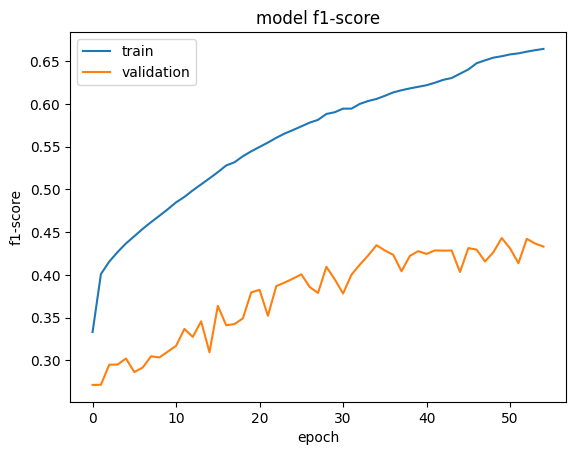

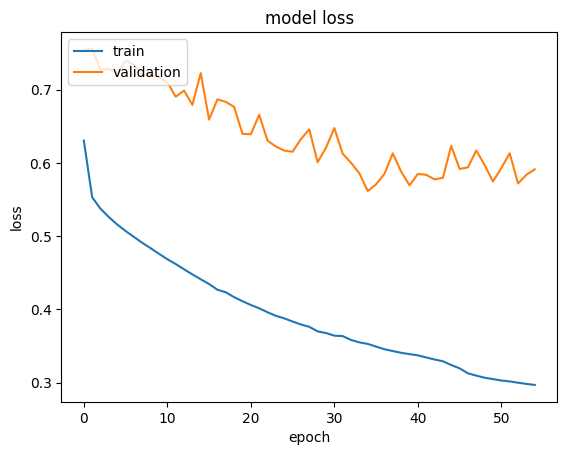

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 354 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - IoU: 0.2954 - accuracy: 0.9535 - f1-score: 0.4498 - loss: 0.5412 - precision: 0.4465 - recall: 0.4867


In [ ]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
#del X_train1, X_train2, y_train
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 120
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = BBUnet(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2))
            #model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics, run_eagerly=False)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = None
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'my_saved_Siamese_CSA'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

            model_path = f'/content/drive/MyDrive/landslide/Results/weights/BBUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(model_path,
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True)
            plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=10, min_lr=1e-5, verbose=1)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, plateau, tensorboard_callback],
                verbose=1
            )
            final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
            print(f"Final learning rate: {final_lr:.2e}")
            training_time = time.time() - start_time

            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/BBUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/BBUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = BBUnet(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2))
            load_Attunet.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(model_path)

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("BBUnet")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_BBUnet.csv', index = False)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_3             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv11 (Conv2D)     │ (None, 256, 256,  │      3,520 │ input_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn11                │ (None, 256, 256,  │        256 │ conv11[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_13 (ReLU)     │ (None, 256, 256,  │          0 │ bn11[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ do11 (Dropout)      │ (None, 256, 256,  │          0 │ re_lu_13[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv12 (Conv2D)     │ (None, 256, 256,  │     36,928 │ do11[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn12                │ (None, 256, 256,  │        256 │ conv12[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 256, 256,  │          0 │ bn12[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ do12 (Dropout)      │ (None, 256, 256,  │          0 │ re_lu_14[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 128, 128,  │          0 │ do12[0][0]        │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv21 (Conv2D)     │ (None, 128, 128,  │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn21                │ (None, 128, 128,  │        512 │ conv21[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 128, 128,  │          0 │ bn21[0][0]        │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ do21 (Dropout)      │ (None, 128, 128,  │          0 │ re_lu_16[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv22 (Conv2D)     │ (None, 128, 128,  │    147,584 │ do21[0][0]        │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn22                │ (None, 128, 128,  │        512 │ conv22[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 128, 128,  │          0 │ bn22[0][0]      

 Total params: 103,566,209 (395.07 MB)

 Trainable params: 103,534,977 (394.95 MB)

 Non-trainable params: 31,232 (122.00 KB)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 354 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - IoU: 0.3581 - accuracy: 0.9542 - f1-score: 0.5177 - loss: 0.4369 - precision: 0.4413 - recall: 0.6673
Epoch 1: val_loss improved from inf to 0.51595, saving model to /content/drive/MyDrive/landslide/Results/weights/BBUnet2_size_256_filters_64_batch_size_4_lr_0.0001.keras
693/693 ━━━━━━━━━━━━━━━━━━━━ 234s 192ms/step - IoU: 0.3581 - accuracy: 0.9542 - f1-score: 0.5178 - loss: 0.4369 - precision: 0.4413 - recall: 0.6673 - val_IoU: 0.3144 - val_accuracy: 0.9566 - val_f1-score: 0.4692 - val_loss: 0.5160 - val_precision: 0.4651 - val_recall: 0.5245 - learning_rate: 1.0000e-04
Epoch 2/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - IoU: 0.3812 - accuracy: 0.9574 - f1-score: 0.5439 - loss: 0.4118 - precision: 0.4654 - recall: 0.6827
Epoch 2: val_loss did not improve from 0.51595
693/693 ━━━━━━━━━━━━━━━━━━━━ 68s 98ms/step - IoU: 0.3812 - accuracy: 0.9574 - f1-score: 0.5439 - loss: 0.4118 - precision: 0.4654 - recall: 0.6827 - val_IoU: 0.299

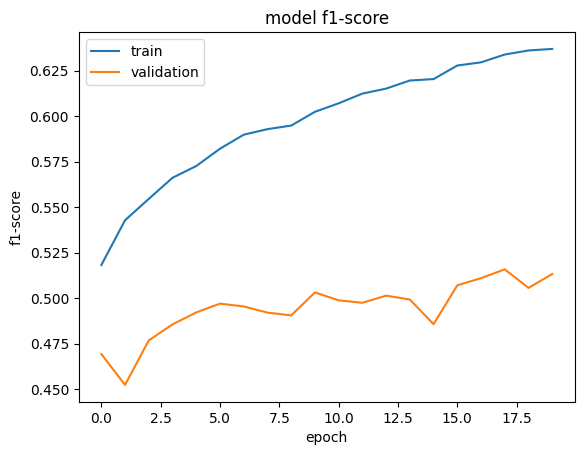

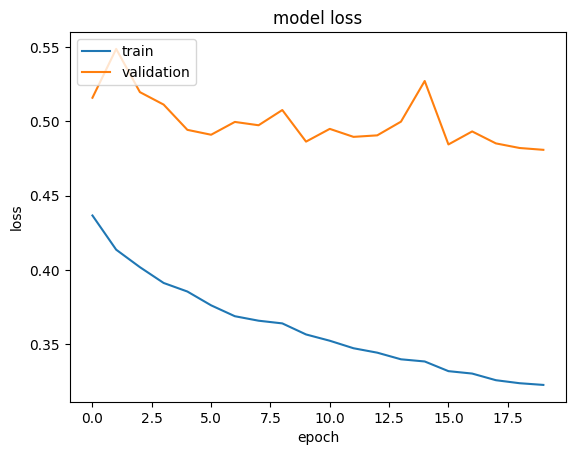

82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - IoU: 0.3182 - accuracy: 0.9699 - f1-score: 0.4737 - loss: 0.5293 - precision: 0.5114 - recall: 0.4749


In [ ]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
#del X_train1, X_train2, y_train
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 40
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = BBUnet(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2))
            #model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics, run_eagerly=False)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = f'/content/drive/MyDrive/landslide/Results/weights/BBUnet2_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'my_saved_Siamese_CSA'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

            model_path = f'/content/drive/MyDrive/landslide/Results/weights/BBUnet2_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(model_path,
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True)
            plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=10, min_lr=1e-5, verbose=1)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, plateau, tensorboard_callback],
                verbose=1
            )
            final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
            print(f"Final learning rate: {final_lr:.2e}")
            training_time = time.time() - start_time

            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/BBUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/BBUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = BBUnet(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2))
            load_Attunet.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(model_path)

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("BBUnet")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_BBUnet2.csv', index = False)

## MODEL SIAUNET

In [18]:
import tensorflow as tf
from tensorflow import keras

## Limit GPU Memory in TensorFlow
## Because TensorFlow, by default, allocates the full amount of available GPU memory when it is launched.
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)
        print('{} memory growth: {}'.format(device, tf.config.experimental.get_memory_growth(device)))
else:
    print("Not enough GPU hardware devices available")

PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU') memory growth: True


In [21]:
with tf.device('/CPU:0'):
    val_dataset = tf.data.Dataset.from_tensor_slices(((X_val1, X_val2), y_val))
    test_dataset = tf.data.Dataset.from_tensor_slices(((X_test1, X_test2), y_test))

In [22]:
del X_val1, X_val2, y_val, X_test1, X_test2, y_test

In [19]:
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices(((X_train1, X_train2), y_train))

In [20]:
del X_train1, X_train2, y_train

In [23]:
# Shuffle and batch the dataset
batch_size = 4  # Adjust based on your needs
train_dataset = train_dataset.shuffle(buffer_size=2443).cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [24]:
size1 = 256
img_bands1= 11
size2 = 256
img_bands2 = 6

In [25]:
import os
import numpy as np
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers, ops
from tensorflow.keras.layers import Conv2D, BatchNormalization, ReLU, Add, Subtract, Concatenate, Dropout, MaxPooling2D, Conv2DTranspose, ReLU, Concatenate, Activation, Input
from tensorflow.keras import backend as K
from tensorflow.keras.layers import AveragePooling2D, Lambda, Conv2D, Conv2DTranspose, Activation, Reshape, concatenate, Concatenate, BatchNormalization, ZeroPadding2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras import layers, Sequential

In [26]:
@tf.keras.utils.register_keras_serializable()
class ChannelAttentionModule(tf.keras.layers.Layer):
    def __init__(self, in_channels, reduction_ratio=16):
        super(ChannelAttentionModule, self).__init__()

        self.in_channels = in_channels
        self.reduction_ratio = reduction_ratio

        self.avgpool1 = layers.GlobalAveragePooling2D()
        self.maxpool1 = layers.GlobalMaxPool2D()

        # Shared MLP
        self.dense1 = layers.Dense(in_channels // reduction_ratio, activation='relu')
        self.dense2 = layers.Dense(in_channels, activation='relu')

        self.ac_channel = layers.Activation('sigmoid')
        self.reshape_channel = layers.Reshape((1, 1, in_channels))

    def call(self, x):

        # Channel Attention
        avgpool = self.avgpool1(x)
        maxpool = self.maxpool1(x)
        avg_out = self.dense2(self.dense1(avgpool))
        max_out = self.dense2(self.dense1(maxpool))
        channel_out = layers.add([avg_out, max_out])
        channel_out = self.ac_channel(channel_out)
        channel_out = self.reshape_channel(channel_out)

        return channel_out

    def get_config(self):
        base_config = super(ChannelAttentionModule, self).get_config()
        base_config['in_channels'] = self.in_channels
        base_config['reduction_ratio'] = self.reduction_ratio
        return base_config

@tf.keras.utils.register_keras_serializable()
class SpatialAttentionModule(tf.keras.layers.Layer):
    def __init__(self):
        super(SpatialAttentionModule, self).__init__()

        self.conv_spatial = layers.Conv2D(1, 7, padding='same')
        self.ac_spatial = layers.Activation('sigmoid')

    def call(self, x):

        # Spatial Attention
        avgpool = tf.reduce_mean(x, axis=3, keepdims=True)
        maxpool = tf.reduce_max(x, axis=3, keepdims=True)
        spatial = layers.Concatenate(axis=3)([avgpool, maxpool])
        spatial = self.conv_spatial(spatial)
        spatial_out = self.ac_spatial(spatial)

        return spatial_out

    def get_config(self):
        base_config = super(SpatialAttentionModule, self).get_config()
        return base_config

@tf.keras.utils.register_keras_serializable()
class CBAM(tf.keras.layers.Layer):
    def __init__(self, in_channels, reduction_ratio=16):
        super(CBAM, self).__init__()
        self.in_channels = in_channels
        self.reduction_ratio = reduction_ratio

        self.cam = ChannelAttentionModule(in_channels, reduction_ratio)
        self.sam = SpatialAttentionModule()

    def call(self, x):

        x = self.cam(x) * x
        x = self.sam(x) * x

        return x

    def get_config(self):
        base_config = super(CBAM, self).get_config()
        base_config['in_channels'] = self.in_channels
        base_config['reduction_ratio'] = self.reduction_ratio
        return base_config

In [28]:
@tf.keras.utils.register_keras_serializable()
class ChannelAttentionModule(tf.keras.layers.Layer):
    def __init__(self,
                 gamma_initializer=tf.zeros_initializer(),
                 gamma_regularizer=None,
                 gamma_constraint=None
                 ):
        super(ChannelAttentionModule, self).__init__()
        self.gamma_initializer = gamma_initializer
        self.gamma_regularizer = gamma_regularizer
        self.gamma_constraint = gamma_constraint

    def build(self, input_shape):
        self.gamma = self.add_weight(shape=(1, ),
                                     initializer=self.gamma_initializer,
                                     name='beta',
                                     regularizer=self.gamma_regularizer,
                                     constraint=self.gamma_constraint)

        self.built = True

    def compute_output_shape(self, input_shape):
        return input_shape

    def call(self, input):
        input_shape = input.get_shape().as_list()
        _, h, w, filters = input_shape
        vec_a = layers.Reshape((h * w, filters))(input)
        aa = layers.dot([vec_a, vec_a], axes=1)
        softmax_aa = layers.Activation('softmax')(aa)
        aaa = layers.dot([vec_a, softmax_aa], axes=[2, 1])
        aaa = layers.Reshape((h, w, filters))(aaa)
        out = self.gamma*aaa + input
        return out

    def get_config(self):
        base_config = super(ChannelAttentionModule, self).get_config()
        base_config['gamma_initializer'] = self.gamma_initializer
        base_config['gamma_regularizer'] = self.gamma_regularizer
        base_config['gamma_constraint'] = self.gamma_constraint
        return base_config

@tf.keras.utils.register_keras_serializable()
class PositionAttentionModule(tf.keras.layers.Layer):
    def __init__(self,
                 in_channels,
                 gamma_initializer=tf.zeros_initializer(),
                 gamma_regularizer=None,
                 gamma_constraint=None
                 ):
        super(PositionAttentionModule, self).__init__()
        self.in_channels = in_channels
        self.gamma_initializer = gamma_initializer
        self.gamma_regularizer = gamma_regularizer
        self.gamma_constraint = gamma_constraint

        self.conv1 = layers.Conv2D(in_channels // 16, 1, use_bias=False, kernel_initializer='he_normal')
        self.conv2 = layers.Conv2D(in_channels // 16, 1, use_bias=False, kernel_initializer='he_normal')
        self.conv3 = layers.Conv2D(in_channels, 1, use_bias=False, kernel_initializer='he_normal')

    def build(self, input_shape):
        self.gamma = self.add_weight(shape=(1, ),
                                     initializer=self.gamma_initializer,
                                     name='alpha',
                                     regularizer=self.gamma_regularizer,
                                     constraint=self.gamma_constraint)

        self.built = True

    def compute_output_shape(self, input_shape):
        return input_shape

    def call(self, input):
        input_shape = input.get_shape().as_list()
        _, h, w, filters = input_shape

        b = self.conv1(input)
        c = self.conv2(input)
        d = self.conv3(input)

        vec_b = layers.Reshape((h * w, filters // 16))(b)
        vec_c = layers.Reshape((h * w, filters // 16))(c)
        bc = layers.dot([vec_b, vec_c], axes=2)
        softmax_bc = layers.Activation('softmax')(bc)
        vec_d = layers.Reshape((h * w, filters))(d)
        bcd = layers.dot([vec_d, softmax_bc], axes=[1, 2])
        bcd = layers.Reshape((h, w, filters))(bcd)
        out = self.gamma*bcd + input
        return out

    def get_config(self):
        base_config = super(PositionAttentionModule, self).get_config()
        base_config['in_channels'] = self.in_channels
        base_config['gamma_initializer'] = self.gamma_initializer
        base_config['gamma_regularizer'] = self.gamma_regularizer
        base_config['gamma_constraint'] = self.gamma_constraint
        return base_config

In [29]:
@tf.keras.utils.register_keras_serializable()
class DualAttentionModule(tf.keras.layers.Layer):
    def __init__(self, in_channels,
                 gamma_initializer=tf.zeros_initializer(),
                 gamma_regularizer=None,
                 gamma_constraint=None):
        super(DualAttentionModule, self).__init__()
        self.in_channels = in_channels
        self.gamma_initializer = gamma_initializer
        self.gamma_regularizer = gamma_regularizer
        self.gamma_constraint = gamma_constraint

        self.cam = ChannelAttentionModule(gamma_initializer=gamma_initializer,
                                        gamma_regularizer=gamma_regularizer,
                                        gamma_constraint=gamma_constraint)
        self.pam = PositionAttentionModule(in_channels=in_channels, gamma_initializer=gamma_initializer,
                                        gamma_regularizer=gamma_regularizer,
                                        gamma_constraint=gamma_constraint)
    def call(self, x):

        feat_p = self.pam(x)
        feat_c = self.cam(x)
        feat_fusion = feat_p + feat_c
        return feat_fusion

    def get_config(self):
        base_config = super(DualAttentionModule, self).get_config()
        base_config['in_channels'] = self.in_channels
        base_config['gamma_initializer'] = self.gamma_initializer
        base_config['gamma_regularizer'] = self.gamma_regularizer
        base_config['gamma_constraint'] = self.gamma_constraint
        return base_config

In [27]:
# Common building blocks
def conv_block(x, filters, block_num, conv_num):
    x = Conv2D(filters, 3, padding='same', kernel_initializer='he_normal', name=f'conv{block_num}{conv_num}')(x)
    x = BatchNormalization(name=f'bn{block_num}{conv_num}')(x)
    x = ReLU()(x)
    x = Dropout(0.2, name=f'do{block_num}{conv_num}')(x)
    return x

def Upsample(tensor, size):  # Remove interpolation
    '''bilinear upsampling'''
    name = tensor.name.split('/')[0] + '_upsample'

    # Replace tf.image.resize and Lambda with UpSampling2D
    y = UpSampling2D(size=size, interpolation='bilinear', name=name)(tensor)
    return y

In [28]:
def ASPP(tensor, filtersFirstLayer):
    '''atrous spatial pyramid pooling'''
    dims = K.int_shape(tensor)

    y_pool = AveragePooling2D(pool_size=(
        dims[1], dims[2]), name='average_pooling')(tensor)
    y_pool = Conv2D(filters=filtersFirstLayer, kernel_size=1, padding='same',
                    kernel_initializer='he_normal', name='pool_1x1conv2d', use_bias=False)(y_pool)
    y_pool = BatchNormalization(name=f'bn_1')(y_pool)
    y_pool = Activation('relu', name=f'relu_1')(y_pool)

    y_pool = Upsample(tensor=y_pool, size=[dims[1], dims[2]])

    y_1 = Conv2D(filters=filtersFirstLayer, kernel_size=1, dilation_rate=1, padding='same',
                 kernel_initializer='he_normal', name='ASPP_conv2d_d1', use_bias=False)(tensor)
    y_1 = BatchNormalization(name=f'bn_2')(y_1)
    y_1 = Activation('relu', name=f'relu_2')(y_1)

    y_6 = Conv2D(filters=filtersFirstLayer, kernel_size=3, dilation_rate=6, padding='same',
                 kernel_initializer='he_normal', name='ASPP_conv2d_d6', use_bias=False)(tensor)
    y_6 = BatchNormalization(name=f'bn_3')(y_6)
    y_6 = Activation('relu', name=f'relu_3')(y_6)

    y_12 = Conv2D(filters=filtersFirstLayer, kernel_size=3, dilation_rate=12, padding='same',
                  kernel_initializer='he_normal', name='ASPP_conv2d_d12', use_bias=False)(tensor)
    y_12 = BatchNormalization(name=f'bn_4')(y_12)
    y_12 = Activation('relu', name=f'relu_4')(y_12)

    y_18 = Conv2D(filters=filtersFirstLayer, kernel_size=3, dilation_rate=18, padding='same',
                  kernel_initializer='he_normal', name='ASPP_conv2d_d18', use_bias=False)(tensor)
    y_18 = BatchNormalization(name=f'bn_5')(y_18)
    y_18 = Activation('relu', name=f'relu_5')(y_18)

    y = concatenate([y_pool, y_1, y_6, y_12, y_18], name='ASPP_concat')

    y = Conv2D(filters=filtersFirstLayer, kernel_size=1, dilation_rate=1, padding='same',
               kernel_initializer='he_normal', name='ASPP_conv2d_final', use_bias=False)(y)
    y = BatchNormalization(name=f'bn_final')(y)
    y = Activation('relu', name=f'relu_final')(y)
    return y

In [29]:
def Main_branch_encoder(filtersFirstLayer, input_shape):
    # Define input within the function
    input_tensor = Input(shape=input_shape)

    # Stage 1
    x11 = conv_block(input_tensor, filtersFirstLayer, 1, 1)
    x12 = conv_block(x11, filtersFirstLayer, 1, 2)
    #x12 = DualAttentionModule(in_channels=filtersFirstLayer)(x12)
    x12 = CBAM(in_channels=filtersFirstLayer)(x12)
    x1p = MaxPooling2D(pool_size=2, strides=2)(x12)

    # Stage 2
    x21 = conv_block(x1p, filtersFirstLayer*2, 2, 1)
    x22 = conv_block(x21, filtersFirstLayer*2, 2, 2)
    #x22 = DualAttentionModule(in_channels=filtersFirstLayer*2)(x22)
    x22 = CBAM(in_channels=filtersFirstLayer*2)(x22)
    x2p = MaxPooling2D(pool_size=2, strides=2)(x22)

    # Stage 3
    x31 = conv_block(x2p, filtersFirstLayer*4, 3, 1)
    x32 = conv_block(x31, filtersFirstLayer*4, 3, 2)
    #x32 = DualAttentionModule(in_channels=filtersFirstLayer*4)(x32)
    x32 = CBAM(in_channels=filtersFirstLayer*4)(x32)
    x3p = MaxPooling2D(pool_size=2, strides=2)(x32)

    # Stage 4
    x41 = conv_block(x3p, filtersFirstLayer*8, 4, 1)
    x42 = conv_block(x41, filtersFirstLayer*8, 4, 2)
    #x42 = DualAttentionModule(in_channels=filtersFirstLayer*8)(x42)
    x42 = CBAM(in_channels=filtersFirstLayer*8)(x42)
    x4p = MaxPooling2D(pool_size=2, strides=2)(x42)

    # Stage 5
    x51 = conv_block(x4p, filtersFirstLayer*16, 5, 1)
    x52 = conv_block(x51, filtersFirstLayer*16, 5, 2)
    x52 = ASPP(x52, filtersFirstLayer=filtersFirstLayer*16)
    return Model(inputs=input_tensor, outputs= [x52, x42, x32, x22, x12])

In [30]:
def SAUnet(filtersFirstLayer, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1)):

    #Define the inputs
    input_1 = Input(shape=input_size1, name='input_1')  # Pre-event optical
    input_2 = Input(shape=input_size2, name='input_2')  # Post-event optical

    # Define shared encoder with correct input shape
    encoder_model = Main_branch_encoder(filtersFirstLayer, input_shape = input_size1)

    # Apply encoder to both concatenated inputs
    Features1 = encoder_model(input_1)
    Features2 = encoder_model(input_2)

    # Unpacking encoder outputs
    F5_1, F4_1, F3_1, F2_1, F1_1 = Features1
    F5_2, F4_2, F3_2, F2_2, F1_2 = Features2

    # Concatenate with absolute difference
    x5d_concat = Concatenate()([F5_1, F5_2])
    x4d_concat = Concatenate()([F4_1, F4_2])
    x3d_concat = Concatenate()([F3_1, F3_2])
    x2d_concat = Concatenate()([F2_1, F2_2])
    x1d_concat = Concatenate()([F1_1, F1_2])

    # Stage 5d
    x5d = Conv2DTranspose(filtersFirstLayer*16, 3, padding='same', strides=2, kernel_initializer='he_normal', name='upconv5')(x5d_concat)
    merge5 = concatenate([x5d, x4d_concat])
    x51d = conv_block(merge5, filtersFirstLayer*16, 'd5', 1)
    x52d = conv_block(x51d, filtersFirstLayer*16, 'd5', 2)

    # Stage 4d
    x4d = Conv2DTranspose(filtersFirstLayer*8, 3, padding='same', strides=2, kernel_initializer='he_normal', name='upconv4')(x52d)
    merge4 = concatenate([x4d, x3d_concat])
    x41d = conv_block(merge4, filtersFirstLayer*8, 'd4', 1)
    x42d = conv_block(x41d, filtersFirstLayer*8, 'd4', 2)

    # Stage 3d
    x3d = Conv2DTranspose(filtersFirstLayer*4, 3, padding='same', strides=2, kernel_initializer='he_normal', name='upconv3')(x42d)
    merge3 = concatenate([x3d, x2d_concat])
    x31d = conv_block(merge3, filtersFirstLayer*4, 'd3', 1)
    x32d = conv_block(x31d, filtersFirstLayer*4, 'd3', 2)

    # Stage 2d
    x2d = Conv2DTranspose(filtersFirstLayer*2, 3, padding='same', strides=2, kernel_initializer='he_normal', name='upconv2')(x32d)
    merge2 = concatenate([x2d, x1d_concat])
    x21d = conv_block(merge2, filtersFirstLayer*2, 'd2', 1)
    x22d = conv_block(x21d, filtersFirstLayer*2, 'd2', 2)

    #Stage final
    x11d = conv_block(x22d, filtersFirstLayer, 'd1', 1)
    Final_output = Conv2D(1, 1, padding = 'same', kernel_initializer='he_normal') (x11d)
    Final_output = Activation('sigmoid')(Final_output)

    return Model(inputs=[input_1, input_2], outputs=Final_output)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_2             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 16, 16,   │ 54,584,776 │ input_1[0][0],    │
│ (Functional)        │ 1024), (None, 32, │            │ input_2[0][0]     │
│                     │ 32, 512), (None,  │            │                   │
│                     │ 64, 64, 256),     │            │                   │
│                     │ (None, 128, 128,  │            │                   │
│                     │ 128), (None, 256, │            │                   │
│                     │ 256, 64)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 16, 16,    │          0 │ functional[0][0], │
│ (Concatenate)       │ 2048)             │            │ functional[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ upconv5             │ (None, 32, 32,    │ 18,875,392 │ concatenate_12[0… │
│ (Conv2DTranspose)   │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_13      │ (None, 32, 32,    │          0 │ functional[0][1], │
│ (Concatenate)       │ 1024)             │            │ functional[1][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_17      │ (None, 32, 32,    │          0 │ upconv5[0][0],    │
│ (Concatenate)       │ 2048)             │            │ concatenate_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convd51 (Conv2D)    │ (None, 32, 32,    │ 18,875,392 │ concatenate_17[0… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bnd51               │ (None, 32, 32,    │      4,096 │ convd51[0][0]     │
│ (BatchNormalizatio… │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 32, 32,    │          0 │ bnd51[0][0]       │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dod51 (Dropout)     │ (None, 32, 32,    │          0 │ re_lu_10[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convd52 (Conv2D)    │ (None, 32, 32,    │  9,438,208 │ dod51[0][0]       │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bnd52               │ (None, 32, 32,    │      4,096 │ convd52[0][0]     │
│ (BatchNormalizatio… │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_11 (ReLU)     │ (None, 32, 32,    │          0 │ bnd52[0][0]       │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dod52 (Dropout)     │ (None, 32, 32,    │          0 │ re_lu_11[0][0]    │
│                     │ 1024)             │            │                 

 Total params: 117,348,809 (447.65 MB)

 Trainable params: 117,320,777 (447.54 MB)

 Non-trainable params: 28,032 (109.50 KB)

Epoch 1/120
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - IoU: 0.1169 - accuracy: 0.7158 - f1-score: 0.2013 - loss: 0.7651 - precision: 0.1246 - recall: 0.7211
Epoch 1: val_loss improved from inf to 0.66080, saving model to /content/drive/MyDrive/landslide/Results/weights/SAUnet_size_256_filters_64_batch_size_4_lr_0.0001.keras
611/611 ━━━━━━━━━━━━━━━━━━━━ 514s 624ms/step - IoU: 0.1169 - accuracy: 0.7159 - f1-score: 0.2014 - loss: 0.7650 - precision: 0.1247 - recall: 0.7211 - val_IoU: 0.2110 - val_accuracy: 0.9120 - val_f1-score: 0.3398 - val_loss: 0.6608 - val_precision: 0.2711 - val_recall: 0.5412 - learning_rate: 1.0000e-04
Epoch 2/120
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - IoU: 0.2090 - accuracy: 0.8975 - f1-score: 0.3359 - loss: 0.6372 - precision: 0.2460 - recall: 0.6447
Epoch 2: val_loss improved from 0.66080 to 0.63727, saving model to /content/drive/MyDrive/landslide/Results/weights/SAUnet_size_256_filters_64_batch_size_4_lr_0.0001.keras
611/611 ━━━━━━━━━━━━━━━━━━━━ 280s 4

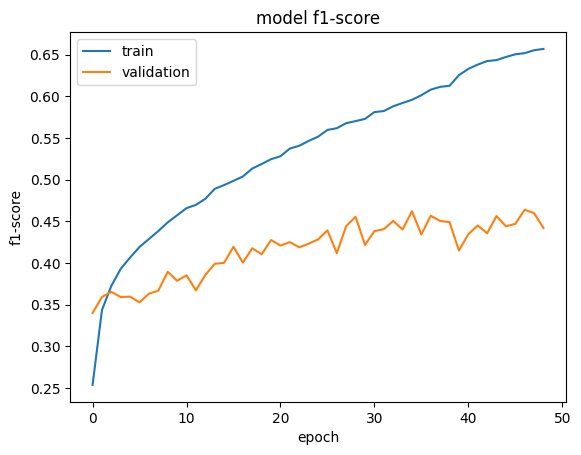

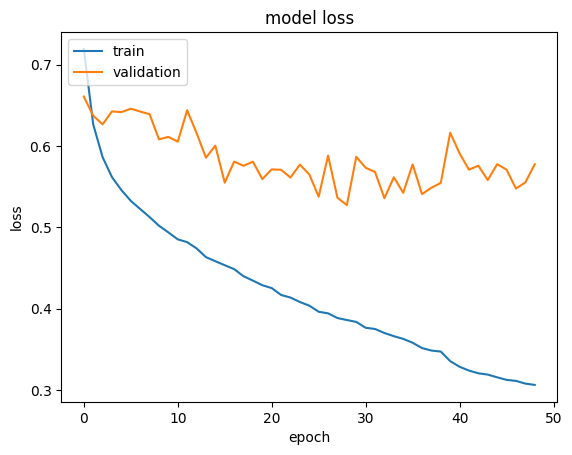

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 258 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


82/82 ━━━━━━━━━━━━━━━━━━━━ 31s 287ms/step - IoU: 0.3138 - accuracy: 0.9521 - f1-score: 0.4696 - loss: 0.5119 - precision: 0.4397 - recall: 0.5328


In [31]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
#del X_train1, X_train2, y_train
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 120
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = SAUnet(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1))
            #model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics, run_eagerly=False)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = None
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'my_saved_SAUnet'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

            model_path = f'/content/drive/MyDrive/landslide/Results/weights/SAUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(model_path,
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True)
            plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=10, min_lr=1e-5, verbose=1)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, plateau, tensorboard_callback],
                verbose=1
            )
            final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
            print(f"Final learning rate: {final_lr:.2e}")
            training_time = time.time() - start_time

            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/SAUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/SAUnet_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = SAUnet(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1))
            load_Attunet.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(model_path)

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("BBUnet")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_SAUnet.csv', index = False)

## MODEL SegFormer

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, Model
import tensorflow as tf
!git clone https://github.com/IMvision12/SegFormer-tf
!cd SegFormer-tf
!cp SegFormer-tf/models/* copied_models/
import keras
from keras import ops
import math
from tensorflow.keras.activations import sigmoid

Cloning into 'SegFormer-tf'...
remote: Enumerating objects: 175, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 175 (delta 18), reused 18 (delta 11), pack-reused 133 (from 1)
Receiving objects: 100% (175/175), 6.21 MiB | 9.37 MiB/s, done.
Resolving deltas: 100% (71/71), done.


In [ ]:
class Attention(keras.layers.Layer):
    def __init__(
        self,
        dim,
        num_heads,
        sr_ratio,
        qkv_bias=False,
        attn_drop=0.0,
        proj_drop=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = self.dim // self.num_heads

        self.units = self.num_heads * self.head_dim
        self.sqrt_of_units = math.sqrt(self.head_dim)

        self.q = keras.layers.Dense(self.units)
        self.k = keras.layers.Dense(self.units)
        self.v = keras.layers.Dense(self.units)

        self.attn_drop = keras.layers.Dropout(attn_drop)

        self.sr_ratio = sr_ratio
        if sr_ratio > 1:
            self.sr = keras.layers.Conv2D(
                filters=dim, kernel_size=sr_ratio, strides=sr_ratio, name='sr',
            )
            self.norm = keras.layers.LayerNormalization(epsilon=1e-05)

        self.proj = keras.layers.Dense(dim)
        self.proj_drop = keras.layers.Dropout(proj_drop)

    def call(self, x, H, W):
        get_shape = ops.shape(x)
        B = get_shape[0]
        C = get_shape[2]

        q = self.q(x)
        q = ops.reshape(q, (B, -1, self.num_heads, self.head_dim))
        q = ops.transpose(q, axes=[0, 2, 1, 3])  # Shape: [B, nh, T_q, hd]

        if self.sr_ratio > 1:
            x = ops.reshape(x, (B, H, W, C))
            x = self.sr(x)
            x = ops.reshape(x, (B, -1, C))
            x = self.norm(x)

        k = self.k(x)
        k = ops.reshape(k, (B, -1, self.num_heads, self.head_dim))
        k = ops.transpose(k, axes=[0, 2, 1, 3])  # Shape: [B, nh, T_k, hd]

        v = self.v(x)
        v = ops.reshape(v, (B, -1, self.num_heads, self.head_dim))
        v = ops.transpose(v, axes=[0, 2, 1, 3])  # Shape: [B, nh, T_v, hd]

        # Transpose k to [B, nh, hd, T_k] for correct matrix multiplication
        k_transposed = ops.transpose(k, axes=[0, 1, 3, 2])

        # Compute attention scores: [B, nh, T_q, T_k]
        attn = ops.matmul(q, k_transposed)
        scale = ops.cast(self.sqrt_of_units, dtype=attn.dtype)
        attn = attn / scale

        attn = ops.softmax(attn, axis=-1)
        attn = self.attn_drop(attn)

        # Multiply with value vectors
        x = ops.matmul(attn, v)  # Shape: [B, nh, T_q, hd]
        x = ops.transpose(x, axes=[0, 2, 1, 3])
        x = ops.reshape(x, (B, -1, self.units))
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

In [ ]:
from copied_models.utils import DropPath

class DWConv(keras.layers.Layer):
    def __init__(self, filters=768, **kwargs):
        super().__init__(**kwargs)
        self.dwconv = keras.layers.Conv2D(
            filters=filters,
            kernel_size=3,
            strides=1,
            padding="same",
            groups=filters,
        )

    def call(self, x, H, W):
        get_shape_1 = ops.shape(x)
        x = ops.reshape(x, (get_shape_1[0], H, W, get_shape_1[-1]))
        x = self.dwconv(x)
        get_shape_2 = ops.shape(x)
        x = ops.reshape(
            x, (get_shape_2[0], get_shape_2[1] * get_shape_2[2], get_shape_2[3])
        )
        return x


class Mlp(keras.layers.Layer):
    def __init__(
        self,
        in_features,
        hidden_features=None,
        out_features=None,
        drop=0.0,
    ):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = keras.layers.Dense(hidden_features)
        self.dwconv = DWConv(hidden_features)
        self.act = keras.layers.Activation("gelu")
        self.fc2 = keras.layers.Dense(out_features)
        self.drop = keras.layers.Dropout(drop)

    def call(self, x, H, W):
        x = self.fc1(x)
        x = self.dwconv(x, H=H, W=W)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class Block(keras.layers.Layer):
    def __init__(
        self,
        dim,
        num_heads,
        mlp_ratio=4.0,
        qkv_bias=False,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        sr_ratio=1,
    ):
        super().__init__()
        self.norm1 = keras.layers.LayerNormalization(epsilon=1e-05)
        self.attn = Attention(
            dim,
            num_heads,
            sr_ratio,
            qkv_bias=qkv_bias,
            attn_drop=attn_drop,
            proj_drop=drop,
        )
        self.drop_path = DropPath(drop_path)
        self.norm2 = keras.layers.LayerNormalization(epsilon=1e-05)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(
            in_features=dim,
            hidden_features=mlp_hidden_dim,
            drop=drop,
        )

    def call(self, x, H, W):
        # Apply LayerNormalization and Attention layer
        attn_output_norm = self.norm1(x)
        attn_output = self.attn(attn_output_norm, H=H, W=W)
        attn_output_with_drop = self.drop_path(attn_output)
        x = x + attn_output_with_drop

        # Apply LayerNormalization and MLP layer
        mlp_output_norm = self.norm2(x)
        mlp_output = self.mlp(mlp_output_norm, H=H, W=W)
        mlp_output_with_drop = self.drop_path(mlp_output)
        x = x + mlp_output_with_drop

        return x



class OverlapPatchEmbed(keras.layers.Layer):
    def __init__(
        self, img_size=224, patch_size=7, stride=4, filters=768, **kwargs
    ):
        super().__init__(**kwargs)
        self.pad = keras.layers.ZeroPadding2D(padding=patch_size // 2)
        self.conv = keras.layers.Conv2D(
            filters=filters,
            kernel_size=patch_size,
            strides=stride,
            padding="VALID",
            name='proj',
        )
        self.norm = keras.layers.LayerNormalization(epsilon=1e-05)

    def call(self, x):
        x = self.conv(self.pad(x))
        get_shapes = ops.shape(x)
        H = get_shapes[1]
        W = get_shapes[2]
        C = get_shapes[3]
        x = ops.reshape(x, (-1, H * W, C))
        x = self.norm(x)
        return x, H, W


class MixVisionTransformer(keras.layers.Layer):
    def __init__(
        self,
        img_size=256,
        embed_dims=[64, 128, 256, 512],
        num_heads=[1, 2, 4, 8],
        mlp_ratios=[4, 4, 4, 4],
        qkv_bias=False,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.0,
        depths=[3, 4, 6, 3],
        sr_ratios=[8, 4, 2, 1],
    ):
        super().__init__()
        self.depths = depths
        # patch_embed
        self.patch_embed1 = OverlapPatchEmbed(
            img_size=img_size,
            patch_size=7,
            stride=4,
            filters=embed_dims[0],
        )
        self.patch_embed2 = OverlapPatchEmbed(
            img_size=img_size // 4,
            patch_size=3,
            stride=2,
            filters=embed_dims[1],
        )
        self.patch_embed3 = OverlapPatchEmbed(
            img_size=img_size // 8,
            patch_size=3,
            stride=2,
            filters=embed_dims[2],
        )
        self.patch_embed4 = OverlapPatchEmbed(
            img_size=img_size // 16,
            patch_size=3,
            stride=2,
            filters=embed_dims[3],
        )

        dpr = [x for x in ops.linspace(0.0, drop_path_rate, sum(depths))]
        cur = 0
        self.block1 = [
            Block(
                dim=embed_dims[0],
                num_heads=num_heads[0],
                mlp_ratio=mlp_ratios[0],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[0],
            )
            for i in range(depths[0])
        ]
        self.norm1 = keras.layers.LayerNormalization(epsilon=1e-05)

        cur += depths[0]
        self.block2 = [
            Block(
                dim=embed_dims[1],
                num_heads=num_heads[1],
                mlp_ratio=mlp_ratios[1],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[1],
            )
            for i in range(depths[1])
        ]
        self.norm2 = keras.layers.LayerNormalization(epsilon=1e-05)

        cur += depths[1]
        self.block3 = [
            Block(
                dim=embed_dims[2],
                num_heads=num_heads[2],
                mlp_ratio=mlp_ratios[2],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[2],
            )
            for i in range(depths[2])
        ]
        self.norm3 = keras.layers.LayerNormalization(epsilon=1e-05)

        cur += depths[2]
        self.block4 = [
            Block(
                dim=embed_dims[3],
                num_heads=num_heads[3],
                mlp_ratio=mlp_ratios[3],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[3],
            )
            for i in range(depths[3])
        ]
        self.norm4 = keras.layers.LayerNormalization(epsilon=1e-05)

    def call_features(self, x):
        B = ops.shape(x)[0]
        outs = []

        # stage 1
        x, H, W = self.patch_embed1(x)
        for i, blk in enumerate(self.block1):
            x = blk(x, H=H, W=W)
        x = self.norm1(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # stage 2
        x, H, W = self.patch_embed2(x)
        for i, blk in enumerate(self.block2):
            x = blk(x, H=H, W=W)
        x = self.norm2(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # stage 3
        x, H, W = self.patch_embed3(x)
        for i, blk in enumerate(self.block3):
            x = blk(x, H=H, W=W)
        x = self.norm3(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # stage 4
        x, H, W = self.patch_embed4(x)
        for i, blk in enumerate(self.block4):
            x = blk(x, H=H, W=W)
        x = self.norm4(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        return outs

    def call(self, x):
        x = self.call_features(x)
        return x

In [ ]:
from copied_models.Head import SegFormerHead
from copied_models.utils import ResizeLayer

MODEL_CONFIGS = {
    "mit_b1": {
        "embed_dims": [64, 128, 320, 512],
        "depths": [2, 2, 2, 2],
        "decode_dim": 256,
    }}

def SegFormer_B3(input_shape, num_classes):
    input_layer = keras.layers.Input(shape=input_shape)
    x = MixVisionTransformer(
        img_size=input_shape[1],
        embed_dims=MODEL_CONFIGS["mit_b1"]["embed_dims"],
        depths=MODEL_CONFIGS["mit_b1"]["depths"],
    )(input_layer)
    x = SegFormerHead(
        num_classes=num_classes,
        decode_dim=MODEL_CONFIGS["mit_b1"]["decode_dim"],
    )(x)

    x = ResizeLayer(input_shape[0], input_shape[1])(x)
    x = sigmoid(x)
    return keras.Model(inputs=input_layer, outputs=x)

In [ ]:
model = SegFormer_B3(input_shape = (256, 256, 11), num_classes = 1)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mix_vision_transfo… │ [(None, 64, 64,   │ 44,097,216 │ input_layer[0][0] │
│ (MixVisionTransfor… │ 64), (None, 32,   │            │                   │
│                     │ 32, 128), (None,  │            │                   │
│                     │ 16, 16, 320),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 512)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seg_former_head     │ (None, 64, 64, 1) │    526,593 │ mix_vision_trans… │
│ (SegFormerHead)     │                   │            │ mix_vision_trans… │
│                     │                   │            │ mix_vision_trans… │
│                     │                   │            │ mix_vision_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize_layer        │ (None, 256, 256,  │          0 │ seg_former_head[… │
│ (ResizeLayer)       │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sigmoid (Sigmoid)   │ (None, 256, 256,  │          0 │ resize_layer[0][… │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 44,623,809 (170.23 MB)

 Trainable params: 44,623,297 (170.22 MB)

 Non-trainable params: 512 (2.00 KB)

None


In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              metrics=['accuracy'])
history = model.fit( post_event_images, change_masks, epochs=10, batch_size=4, validation_split=0.2)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 207s 3s/step - accuracy: 0.9104 - loss: 0.5262 - val_accuracy: 0.9708 - val_loss: 0.2513
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 184ms/step - accuracy: 0.9740 - loss: 0.1460 - val_accuracy: 0.0608 - val_loss: 1.2250
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - accuracy: 0.9806 - loss: 0.0836 - val_accuracy: 0.0435 - val_loss: 2.5611
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - accuracy: 0.9840 - loss: 0.0635 - val_accuracy: 0.0509 - val_loss: 3.2314
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.9866 - loss: 0.0491 - val_accuracy: 0.1829 - val_loss: 2.5592
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.9903 - loss: 0.0353 - val_accuracy: 0.8072 - val_loss: 0.6397
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - accuracy: 0.9953 - loss: 0.0233 - val_accuracy: 0.8348 - val_loss: 0.4239
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 0.9966 - loss: 0.0193 - val_accuracy: 0.

## MODEL SegFormer V2

In [ ]:
with tf.device('/CPU:0'):
    val_dataset = tf.data.Dataset.from_tensor_slices(( X_val2, y_val))
    test_dataset = tf.data.Dataset.from_tensor_slices((X_test2, y_test))

In [ ]:
del X_val2, y_val, X_test2, y_test

In [ ]:
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train2, y_train))

In [ ]:
del  X_train2, y_train

In [ ]:
!pip install keras-unet-collection -q -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 3.1 MB/s eta 0:00:00


In [ ]:
# Shuffle and batch the dataset
batch_size = 4  # Adjust based on your needs
train_dataset = train_dataset.shuffle(buffer_size=2443).cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, Model
import tensorflow as tf
!git clone https://github.com/IMvision12/SegFormer-tf
!cd SegFormer-tf
!cp SegFormer-tf/models/* copied_models/
import keras
from keras import ops
import math
from tensorflow.keras.activations import sigmoid

Cloning into 'SegFormer-tf'...
remote: Enumerating objects: 175, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 175 (delta 18), reused 18 (delta 11), pack-reused 133 (from 1)
Receiving objects: 100% (175/175), 6.21 MiB | 9.76 MiB/s, done.
Resolving deltas: 100% (71/71), done.


In [ ]:
# Size of the tiles/patches
size1 = 256 # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = 256
# Image bands
img_bands1 = 11 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.

In [ ]:
class Attention(keras.layers.Layer):
    def __init__(
        self,
        dim,
        num_heads,
        sr_ratio,
        qkv_bias=False,
        attn_drop=0.0,
        proj_drop=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = self.dim // self.num_heads

        self.units = self.num_heads * self.head_dim
        self.sqrt_of_units = math.sqrt(self.head_dim)

        self.q = keras.layers.Dense(self.units)
        self.k = keras.layers.Dense(self.units)
        self.v = keras.layers.Dense(self.units)

        self.attn_drop = keras.layers.Dropout(attn_drop)

        self.sr_ratio = sr_ratio
        if sr_ratio > 1:
            self.sr = keras.layers.Conv2D(
                filters=dim, kernel_size=sr_ratio, strides=sr_ratio, name='sr',
            )
            self.norm = keras.layers.LayerNormalization(epsilon=1e-05)

        self.proj = keras.layers.Dense(dim)
        self.proj_drop = keras.layers.Dropout(proj_drop)

    def call(self, x, H, W):
        get_shape = ops.shape(x)
        B = get_shape[0]
        C = get_shape[2]

        q = self.q(x)
        q = ops.reshape(q, (B, -1, self.num_heads, self.head_dim))
        q = ops.transpose(q, axes=[0, 2, 1, 3])  # Shape: [B, nh, T_q, hd]

        if self.sr_ratio > 1:
            x = ops.reshape(x, (B, H, W, C))
            x = self.sr(x)
            x = ops.reshape(x, (B, -1, C))
            x = self.norm(x)

        k = self.k(x)
        k = ops.reshape(k, (B, -1, self.num_heads, self.head_dim))
        k = ops.transpose(k, axes=[0, 2, 1, 3])  # Shape: [B, nh, T_k, hd]

        v = self.v(x)
        v = ops.reshape(v, (B, -1, self.num_heads, self.head_dim))
        v = ops.transpose(v, axes=[0, 2, 1, 3])  # Shape: [B, nh, T_v, hd]

        # Transpose k to [B, nh, hd, T_k] for correct matrix multiplication
        k_transposed = ops.transpose(k, axes=[0, 1, 3, 2])

        # Compute attention scores: [B, nh, T_q, T_k]
        attn = ops.matmul(q, k_transposed)
        scale = ops.cast(self.sqrt_of_units, dtype=attn.dtype)
        attn = attn / scale

        attn = ops.softmax(attn, axis=-1)
        attn = self.attn_drop(attn)

        # Multiply with value vectors
        x = ops.matmul(attn, v)  # Shape: [B, nh, T_q, hd]
        x = ops.transpose(x, axes=[0, 2, 1, 3])
        x = ops.reshape(x, (B, -1, self.units))
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

In [ ]:
from copied_models.utils import DropPath

class DWConv(keras.layers.Layer):
    def __init__(self, filters=768, **kwargs):
        super().__init__(**kwargs)
        self.dwconv = keras.layers.Conv2D(
            filters=filters,
            kernel_size=3,
            strides=1,
            padding="same",
            groups=filters,
        )

    def call(self, x, H, W):
        get_shape_1 = ops.shape(x)
        x = ops.reshape(x, (get_shape_1[0], H, W, get_shape_1[-1]))
        x = self.dwconv(x)
        get_shape_2 = ops.shape(x)
        x = ops.reshape(
            x, (get_shape_2[0], get_shape_2[1] * get_shape_2[2], get_shape_2[3])
        )
        return x


class Mlp(keras.layers.Layer):
    def __init__(
        self,
        in_features,
        hidden_features=None,
        out_features=None,
        drop=0.0,
    ):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = keras.layers.Dense(hidden_features)
        self.dwconv = DWConv(hidden_features)
        self.act = keras.layers.Activation("gelu")
        self.fc2 = keras.layers.Dense(out_features)
        self.drop = keras.layers.Dropout(drop)

    def call(self, x, H, W):
        x = self.fc1(x)
        x = self.dwconv(x, H=H, W=W)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class Block(keras.layers.Layer):
    def __init__(
        self,
        dim,
        num_heads,
        mlp_ratio=4.0,
        qkv_bias=False,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        sr_ratio=1,
    ):
        super().__init__()
        self.norm1 = keras.layers.LayerNormalization(epsilon=1e-05)
        self.attn = Attention(
            dim,
            num_heads,
            sr_ratio,
            qkv_bias=qkv_bias,
            attn_drop=attn_drop,
            proj_drop=drop,
        )
        self.drop_path = DropPath(drop_path)
        self.norm2 = keras.layers.LayerNormalization(epsilon=1e-05)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(
            in_features=dim,
            hidden_features=mlp_hidden_dim,
            drop=drop,
        )

    def call(self, x, H, W):
        # Apply LayerNormalization and Attention layer
        attn_output_norm = self.norm1(x)
        attn_output = self.attn(attn_output_norm, H=H, W=W)
        attn_output_with_drop = self.drop_path(attn_output)
        x = x + attn_output_with_drop

        # Apply LayerNormalization and MLP layer
        mlp_output_norm = self.norm2(x)
        mlp_output = self.mlp(mlp_output_norm, H=H, W=W)
        mlp_output_with_drop = self.drop_path(mlp_output)
        x = x + mlp_output_with_drop

        return x



class OverlapPatchEmbed(keras.layers.Layer):
    def __init__(
        self, img_size=224, patch_size=7, stride=4, filters=768, **kwargs
    ):
        super().__init__(**kwargs)
        self.pad = keras.layers.ZeroPadding2D(padding=patch_size // 2)
        self.conv = keras.layers.Conv2D(
            filters=filters,
            kernel_size=patch_size,
            strides=stride,
            padding="VALID",
            name='proj',
        )
        self.norm = keras.layers.LayerNormalization(epsilon=1e-05)

    def call(self, x):
        x = self.conv(self.pad(x))
        get_shapes = ops.shape(x)
        H = get_shapes[1]
        W = get_shapes[2]
        C = get_shapes[3]
        x = ops.reshape(x, (-1, H * W, C))
        x = self.norm(x)
        return x, H, W


class MixVisionTransformer(keras.layers.Layer):
    def __init__(
        self,
        img_size=256,
        embed_dims=[64, 128, 256, 512, 1024],  # Added 1024
        num_heads=[1, 2, 4, 8, 16],            # Added 16
        mlp_ratios=[4, 4, 4, 4, 4],             # Extended
        qkv_bias=False,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.0,
        depths=[3, 4, 6, 3, 3],                # Added 3
        sr_ratios=[8, 4, 2, 1, 1],             # Added 1
    ):
        super().__init__()
        self.depths = depths

        # patch_embed
        self.patch_embed1 = OverlapPatchEmbed(
            img_size=img_size,
            patch_size=7,
            stride=4,
            filters=embed_dims[0],
        )
        self.patch_embed2 = OverlapPatchEmbed(
            img_size=img_size // 4,
            patch_size=3,
            stride=2,
            filters=embed_dims[1],
        )
        self.patch_embed3 = OverlapPatchEmbed(
            img_size=img_size // 8,
            patch_size=3,
            stride=2,
            filters=embed_dims[2],
        )
        self.patch_embed4 = OverlapPatchEmbed(
            img_size=img_size // 16,
            patch_size=3,
            stride=2,
            filters=embed_dims[3],
        )
        # New patch embed for 5th stage
        self.patch_embed5 = OverlapPatchEmbed(
            img_size=img_size // 32,
            patch_size=3,
            stride=2,
            filters=embed_dims[4],
        )

        # Drop path rates
        dpr = [x for x in ops.linspace(0.0, drop_path_rate, sum(depths))]
        cur = 0

        # Block 1
        self.block1 = [
            Block(
                dim=embed_dims[0],
                num_heads=num_heads[0],
                mlp_ratio=mlp_ratios[0],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[0],
            )
            for i in range(depths[0])
        ]
        self.norm1 = keras.layers.LayerNormalization(epsilon=1e-05)
        cur += depths[0]

        # Block 2
        self.block2 = [
            Block(
                dim=embed_dims[1],
                num_heads=num_heads[1],
                mlp_ratio=mlp_ratios[1],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[1],
            )
            for i in range(depths[1])
        ]
        self.norm2 = keras.layers.LayerNormalization(epsilon=1e-05)
        cur += depths[1]

        # Block 3
        self.block3 = [
            Block(
                dim=embed_dims[2],
                num_heads=num_heads[2],
                mlp_ratio=mlp_ratios[2],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[2],
            )
            for i in range(depths[2])
        ]
        self.norm3 = keras.layers.LayerNormalization(epsilon=1e-05)
        cur += depths[2]

        # Block 4
        self.block4 = [
            Block(
                dim=embed_dims[3],
                num_heads=num_heads[3],
                mlp_ratio=mlp_ratios[3],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[3],
            )
            for i in range(depths[3])
        ]
        self.norm4 = keras.layers.LayerNormalization(epsilon=1e-05)
        cur += depths[3]

        # New Block 5
        self.block5 = [
            Block(
                dim=embed_dims[4],
                num_heads=num_heads[4],
                mlp_ratio=mlp_ratios[4],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[4],
            )
            for i in range(depths[4])
        ]
        self.norm5 = keras.layers.LayerNormalization(epsilon=1e-05)

    def call_features(self, x):
        B = ops.shape(x)[0]
        outs = []

        # stage 1
        x, H, W = self.patch_embed1(x)
        for i, blk in enumerate(self.block1):
            x = blk(x, H=H, W=W)
        x = self.norm1(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # stage 2
        x, H, W = self.patch_embed2(x)
        for i, blk in enumerate(self.block2):
            x = blk(x, H=H, W=W)
        x = self.norm2(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # stage 3
        x, H, W = self.patch_embed3(x)
        for i, blk in enumerate(self.block3):
            x = blk(x, H=H, W=W)
        x = self.norm3(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # stage 4
        x, H, W = self.patch_embed4(x)
        for i, blk in enumerate(self.block4):
            x = blk(x, H=H, W=W)
        x = self.norm4(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # New stage 5
        x, H, W = self.patch_embed5(x)
        for i, blk in enumerate(self.block5):
            x = blk(x, H=H, W=W)
        x = self.norm5(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        return outs

    def call(self, x):
        x = self.call_features(x)
        return x

In [ ]:
from copied_models.Head import SegFormerHead
from copied_models.utils import ResizeLayer

MODEL_CONFIGS = {
    "mit_b3": {
        "embed_dims": [64, 128, 320, 512, 1024],
        "depths": [3, 3, 4, 6, 3],
        "decode_dim": 768,
    }}



def SegFormer_B3(input_shape, num_classes):
    input_layer = keras.layers.Input(shape=input_shape)
    x = MixVisionTransformer(
        img_size=input_shape[1],
        embed_dims=MODEL_CONFIGS["mit_b3"]["embed_dims"],
        depths=MODEL_CONFIGS["mit_b3"]["depths"],
    )(input_layer)
    x = SegFormerHead(
        num_mlp_layers=5, num_classes=num_classes,
        decode_dim=MODEL_CONFIGS["mit_b3"]["decode_dim"],
    )(x)

    x = ResizeLayer(input_shape[0], input_shape[1])(x)
    x = sigmoid(x)
    return keras.Model(inputs=input_layer, outputs=x)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mix_vision_transfo… │ [(None, 64, 64,   │ 72,596,672 │ input_layer[0][0] │
│ (MixVisionTransfor… │ 64), (None, 32,   │            │                   │
│                     │ 32, 128), (None,  │            │                   │
│                     │ 16, 16, 320),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 512), (None, 4,   │            │                   │
│                     │ 4, 1024)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seg_former_head     │ (None, 64, 64, 1) │  4,529,665 │ mix_vision_trans… │
│ (SegFormerHead)     │                   │            │ mix_vision_trans… │
│                     │                   │            │ mix_vision_trans… │
│                     │                   │            │ mix_vision_trans… │
│                     │                   │            │ mix_vision_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize_layer        │ (None, 256, 256,  │          0 │ seg_former_head[… │
│ (ResizeLayer)       │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sigmoid (Sigmoid)   │ (None, 256, 256,  │          0 │ resize_layer[0][… │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 77,126,337 (294.21 MB)

 Trainable params: 77,124,801 (294.21 MB)

 Non-trainable params: 1,536 (6.00 KB)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 856 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/110
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - IoU: 0.1844 - accuracy: 0.8962 - f1-score: 0.3011 - loss: 0.6461 - precision: 0.2233 - recall: 0.5539
Epoch 1: val_loss improved from inf to 0.64184, saving model to /content/drive/MyDrive/landslide/Results/weights/SegFormer_B3_size_256_filters_64_batch_size_4_lr_0.0001.keras
611/611 ━━━━━━━━━━━━━━━━━━━━ 431s 393ms/step - IoU: 0.1844 - accuracy: 0.8962 - f1-score: 0.3011 - loss: 0.6461 - precision: 0.2233 - recall: 0.5539 - val_IoU: 0.1823 - val_accuracy: 0.8872 - val_f1-score: 0.3005 - val_loss: 0.6418 - val_precision: 0.2150 - val_recall: 0.5862 - learning_rate: 1.0000e-04
Epoch 2/110
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - IoU: 0.1962 - accuracy: 0.9041 - f1-score: 0.3176 - loss: 0.6296 - precision: 0.2380 - recall: 0.5597
Epoch 2: val_loss improved from 0.64184 to 0.63105, saving model to /content/drive/MyDrive/landslide/Results/weights/SegFormer_B3_size_256_filters_64_batch_size_4_lr_0.0001.keras
611/611 ━━━━━━━━━━━━━━━━

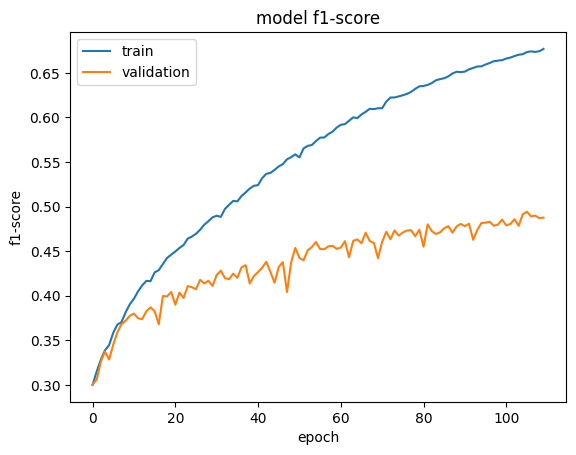

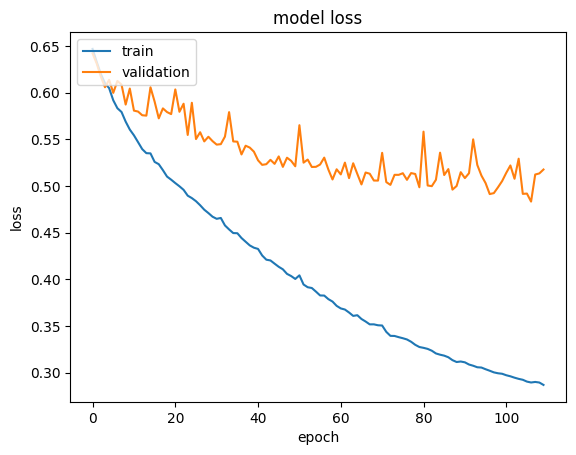

82/82 ━━━━━━━━━━━━━━━━━━━━ 62s 495ms/step - IoU: 0.3444 - accuracy: 0.9546 - f1-score: 0.5019 - loss: 0.4712 - precision: 0.4533 - recall: 0.5926


In [ ]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
#del X_train1, X_train2, y_train
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 110
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = SegFormer_B3(input_shape = (size1,size1,img_bands1), num_classes =1)
            #model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics, run_eagerly=False)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = f'/content/drive/MyDrive/landslide/Results/weights/SegFormer_B3_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'SegFormer_B3'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

            model_path = f'/content/drive/MyDrive/landslide/Results/weights/SegFormer_B3_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(model_path,
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True)
            plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=10, min_lr=1e-5, verbose=1)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, plateau, tensorboard_callback],
                verbose=1
            )
            final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
            print(f"Final learning rate: {final_lr:.2e}")
            training_time = time.time() - start_time

            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/SegFormer_B3_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/SegFormer_B3_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = SegFormer_B3(input_shape = (size1,size1,img_bands1), num_classes =1)
            load_Attunet.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(model_path)

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("SegFormer_B3")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_SegFormer_B3.csv', index = False)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mix_vision_transfo… │ [(None, 64, 64,   │ 72,596,672 │ input_layer_5[0]… │
│ (MixVisionTransfor… │ 64), (None, 32,   │            │                   │
│                     │ 32, 128), (None,  │            │                   │
│                     │ 16, 16, 320),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 512), (None, 4,   │            │                   │
│                     │ 4, 1024)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seg_former_head_5   │ (None, 64, 64, 1) │  4,529,665 │ mix_vision_trans… │
│ (SegFormerHead)     │                   │            │ mix_vision_trans… │
│                     │                   │            │ mix_vision_trans… │
│                     │                   │            │ mix_vision_trans… │
│                     │                   │            │ mix_vision_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize_layer_5      │ (None, 256, 256,  │          0 │ seg_former_head_… │
│ (ResizeLayer)       │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sigmoid_5 (Sigmoid) │ (None, 256, 256,  │          0 │ resize_layer_5[0… │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 77,126,337 (294.21 MB)

 Trainable params: 77,124,801 (294.21 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/50
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - IoU: 0.5152 - accuracy: 0.9689 - f1-score: 0.6748 - loss: 0.2886 - precision: 0.5971 - recall: 0.7811
Epoch 1: val_loss improved from inf to 0.50611, saving model to /content/drive/MyDrive/landslide/Results/weights/SegFormer_B3_size_256_filters_64_batch_size_4_lr_0.0001.keras
611/611 ━━━━━━━━━━━━━━━━━━━━ 332s 292ms/step - IoU: 0.5152 - accuracy: 0.9689 - f1-score: 0.6748 - loss: 0.2886 - precision: 0.5971 - recall: 0.7811 - val_IoU: 0.3379 - val_accuracy: 0.9589 - val_f1-score: 0.4940 - val_loss: 0.5061 - val_precision: 0.5059 - val_recall: 0.5053 - learning_rate: 1.0000e-04
Epoch 2/50
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - IoU: 0.5181 - accuracy: 0.9692 - f1-score: 0.6772 - loss: 0.2868 - precision: 0.6004 - recall: 0.7825
Epoch 2: val_loss did not improve from 0.50611
611/611 ━━━━━━━━━━━━━━━━━━━━ 67s 110ms/step - IoU: 0.5181 - accuracy: 0.9692 - f1-score: 0.6772 - loss: 0.2868 - precision: 0.6004 - recall: 0.7825 - val_IoU:

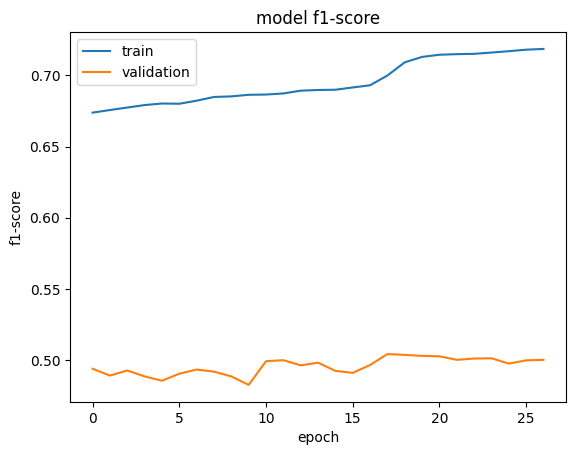

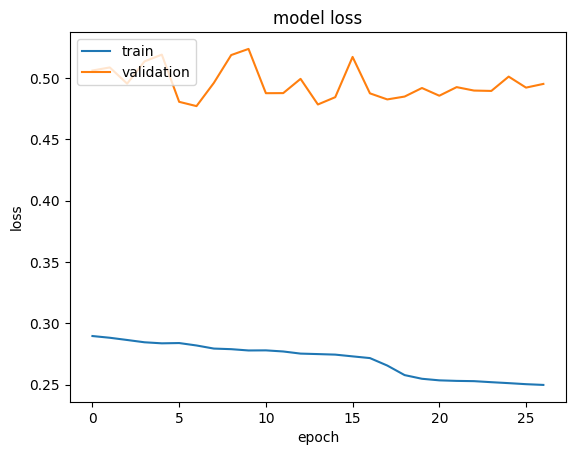

82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 231ms/step - IoU: 0.3537 - accuracy: 0.9556 - f1-score: 0.5119 - loss: 0.4595 - precision: 0.4594 - recall: 0.6075


In [ ]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
#del X_train1, X_train2, y_train
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 50
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = SegFormer_B3(input_shape = (size1,size1,img_bands1), num_classes =1)
            #model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics, run_eagerly=False)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = f'/content/drive/MyDrive/landslide/Results/weights/SegFormer_B3_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'SegFormer_B3'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

            model_path = f'/content/drive/MyDrive/landslide/Results/weights/SegFormer_B3_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(model_path,
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True)
            plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=10, min_lr=1e-5, verbose=1)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, plateau, tensorboard_callback],
                verbose=1
            )
            final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
            print(f"Final learning rate: {final_lr:.2e}")
            training_time = time.time() - start_time

            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/SegFormer_B3_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/SegFormer_B3_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = SegFormer_B3(input_shape = (size1,size1,img_bands1), num_classes =1)
            load_Attunet.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(model_path)

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("SegFormer_B3")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_SegFormer_B3.csv', index = False)

## MODEL ChangeFormer

In [ ]:
import tensorflow as tf
from tensorflow import keras

## Limit GPU Memory in TensorFlow
## Because TensorFlow, by default, allocates the full amount of available GPU memory when it is launched.
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)
        print('{} memory growth: {}'.format(device, tf.config.experimental.get_memory_growth(device)))
else:
    print("Not enough GPU hardware devices available")

PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU') memory growth: True


In [ ]:
with tf.device('/CPU:0'):
    val_dataset = tf.data.Dataset.from_tensor_slices(((X_val1, X_val2), y_val))
    test_dataset = tf.data.Dataset.from_tensor_slices(((X_test1, X_test2), y_test))

In [ ]:
del X_val1, X_val2, y_val, X_test1, X_test2, y_test

In [ ]:
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices(((X_train1, X_train2), y_train))

In [ ]:
del X_train1, X_train2, y_train

In [ ]:
# Shuffle and batch the dataset
batch_size = 4  # Adjust based on your needs
train_dataset = train_dataset.shuffle(buffer_size=2443).cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, Model
import tensorflow as tf
!git clone https://github.com/IMvision12/SegFormer-tf
!cd SegFormer-tf
!cp SegFormer-tf/models/* copied_models/
import keras
from keras import ops
import math
from tensorflow.keras.activations import sigmoid

fatal: destination path 'SegFormer-tf' already exists and is not an empty directory.


In [ ]:
class Attention(keras.layers.Layer):
    def __init__(
        self,
        dim,
        num_heads,
        sr_ratio,
        qkv_bias=False,
        attn_drop=0.0,
        proj_drop=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = self.dim // self.num_heads

        self.units = self.num_heads * self.head_dim
        self.sqrt_of_units = math.sqrt(self.head_dim)

        self.q = keras.layers.Dense(self.units)
        self.k = keras.layers.Dense(self.units)
        self.v = keras.layers.Dense(self.units)

        self.attn_drop = keras.layers.Dropout(attn_drop)

        self.sr_ratio = sr_ratio
        if sr_ratio > 1:
            self.sr = keras.layers.Conv2D(
                filters=dim, kernel_size=sr_ratio, strides=sr_ratio, name='sr',
            )
            self.norm = keras.layers.LayerNormalization(epsilon=1e-05)

        self.proj = keras.layers.Dense(dim)
        self.proj_drop = keras.layers.Dropout(proj_drop)

    def call(self, x, H, W):
        get_shape = ops.shape(x)
        B = get_shape[0]
        C = get_shape[2]

        q = self.q(x)
        q = ops.reshape(q, (B, -1, self.num_heads, self.head_dim))
        q = ops.transpose(q, axes=[0, 2, 1, 3])  # Shape: [B, nh, T_q, hd]

        if self.sr_ratio > 1:
            x = ops.reshape(x, (B, H, W, C))
            x = self.sr(x)
            x = ops.reshape(x, (B, -1, C))
            x = self.norm(x)

        k = self.k(x)
        k = ops.reshape(k, (B, -1, self.num_heads, self.head_dim))
        k = ops.transpose(k, axes=[0, 2, 1, 3])  # Shape: [B, nh, T_k, hd]

        v = self.v(x)
        v = ops.reshape(v, (B, -1, self.num_heads, self.head_dim))
        v = ops.transpose(v, axes=[0, 2, 1, 3])  # Shape: [B, nh, T_v, hd]

        # Transpose k to [B, nh, hd, T_k] for correct matrix multiplication
        k_transposed = ops.transpose(k, axes=[0, 1, 3, 2])

        # Compute attention scores: [B, nh, T_q, T_k]
        attn = ops.matmul(q, k_transposed)
        scale = ops.cast(self.sqrt_of_units, dtype=attn.dtype)
        attn = attn / scale

        attn = ops.softmax(attn, axis=-1)
        attn = self.attn_drop(attn)

        # Multiply with value vectors
        x = ops.matmul(attn, v)  # Shape: [B, nh, T_q, hd]
        x = ops.transpose(x, axes=[0, 2, 1, 3])
        x = ops.reshape(x, (B, -1, self.units))
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

In [ ]:
from copied_models.utils import DropPath

class DWConv(keras.layers.Layer):
    def __init__(self, filters=768, **kwargs):
        super().__init__(**kwargs)
        self.dwconv = keras.layers.Conv2D(
            filters=filters,
            kernel_size=3,
            strides=1,
            padding="same",
            groups=filters,
        )

    def call(self, x, H, W):
        get_shape_1 = ops.shape(x)
        x = ops.reshape(x, (get_shape_1[0], H, W, get_shape_1[-1]))
        x = self.dwconv(x)
        get_shape_2 = ops.shape(x)
        x = ops.reshape(
            x, (get_shape_2[0], get_shape_2[1] * get_shape_2[2], get_shape_2[3])
        )
        return x


class Mlp(keras.layers.Layer):
    def __init__(
        self,
        in_features,
        hidden_features=None,
        out_features=None,
        drop=0.0,
    ):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = keras.layers.Dense(hidden_features)
        self.dwconv = DWConv(hidden_features)
        self.act = keras.layers.Activation("gelu")
        self.fc2 = keras.layers.Dense(out_features)
        self.drop = keras.layers.Dropout(drop)

    def call(self, x, H, W):
        x = self.fc1(x)
        x = self.dwconv(x, H=H, W=W)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class Block(keras.layers.Layer):
    def __init__(
        self,
        dim,
        num_heads,
        mlp_ratio=4.0,
        qkv_bias=False,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        sr_ratio=1,
    ):
        super().__init__()
        self.norm1 = keras.layers.LayerNormalization(epsilon=1e-05)
        self.attn = Attention(
            dim,
            num_heads,
            sr_ratio,
            qkv_bias=qkv_bias,
            attn_drop=attn_drop,
            proj_drop=drop,
        )
        self.drop_path = DropPath(drop_path)
        self.norm2 = keras.layers.LayerNormalization(epsilon=1e-05)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(
            in_features=dim,
            hidden_features=mlp_hidden_dim,
            drop=drop,
        )

    def call(self, x, H, W):
        # Apply LayerNormalization and Attention layer
        attn_output_norm = self.norm1(x)
        attn_output = self.attn(attn_output_norm, H=H, W=W)
        attn_output_with_drop = self.drop_path(attn_output)
        x = x + attn_output_with_drop

        # Apply LayerNormalization and MLP layer
        mlp_output_norm = self.norm2(x)
        mlp_output = self.mlp(mlp_output_norm, H=H, W=W)
        mlp_output_with_drop = self.drop_path(mlp_output)
        x = x + mlp_output_with_drop

        return x



class OverlapPatchEmbed(keras.layers.Layer):
    def __init__(
        self, img_size=224, patch_size=7, stride=4, filters=768, **kwargs
    ):
        super().__init__(**kwargs)
        self.pad = keras.layers.ZeroPadding2D(padding=patch_size // 2)
        self.conv = keras.layers.Conv2D(
            filters=filters,
            kernel_size=patch_size,
            strides=stride,
            padding="VALID",
            name='proj',
        )
        self.norm = keras.layers.LayerNormalization(epsilon=1e-05)

    def call(self, x):
        x = self.conv(self.pad(x))
        get_shapes = ops.shape(x)
        H = get_shapes[1]
        W = get_shapes[2]
        C = get_shapes[3]
        x = ops.reshape(x, (-1, H * W, C))
        x = self.norm(x)
        return x, H, W


class MixVisionTransformer(keras.layers.Layer):
    def __init__(
        self,
        img_size=256,
        embed_dims=[64, 128, 256, 512, 1024],  # Added 1024
        num_heads=[1, 2, 4, 8, 16],            # Added 16
        mlp_ratios=[4, 4, 4, 4, 4],             # Extended
        qkv_bias=False,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.0,
        depths=[3, 4, 6, 3, 3],                # Added 3
        sr_ratios=[8, 4, 2, 1, 1],             # Added 1
    ):
        super().__init__()
        self.depths = depths

        # patch_embed
        self.patch_embed1 = OverlapPatchEmbed(
            img_size=img_size,
            patch_size=7,
            stride=4,
            filters=embed_dims[0],
        )
        self.patch_embed2 = OverlapPatchEmbed(
            img_size=img_size // 4,
            patch_size=3,
            stride=2,
            filters=embed_dims[1],
        )
        self.patch_embed3 = OverlapPatchEmbed(
            img_size=img_size // 8,
            patch_size=3,
            stride=2,
            filters=embed_dims[2],
        )
        self.patch_embed4 = OverlapPatchEmbed(
            img_size=img_size // 16,
            patch_size=3,
            stride=2,
            filters=embed_dims[3],
        )
        # New patch embed for 5th stage
        self.patch_embed5 = OverlapPatchEmbed(
            img_size=img_size // 32,
            patch_size=3,
            stride=2,
            filters=embed_dims[4],
        )

        # Drop path rates
        dpr = [x for x in ops.linspace(0.0, drop_path_rate, sum(depths))]
        cur = 0

        # Block 1
        self.block1 = [
            Block(
                dim=embed_dims[0],
                num_heads=num_heads[0],
                mlp_ratio=mlp_ratios[0],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[0],
            )
            for i in range(depths[0])
        ]
        self.norm1 = keras.layers.LayerNormalization(epsilon=1e-05)
        cur += depths[0]

        # Block 2
        self.block2 = [
            Block(
                dim=embed_dims[1],
                num_heads=num_heads[1],
                mlp_ratio=mlp_ratios[1],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[1],
            )
            for i in range(depths[1])
        ]
        self.norm2 = keras.layers.LayerNormalization(epsilon=1e-05)
        cur += depths[1]

        # Block 3
        self.block3 = [
            Block(
                dim=embed_dims[2],
                num_heads=num_heads[2],
                mlp_ratio=mlp_ratios[2],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[2],
            )
            for i in range(depths[2])
        ]
        self.norm3 = keras.layers.LayerNormalization(epsilon=1e-05)
        cur += depths[2]

        # Block 4
        self.block4 = [
            Block(
                dim=embed_dims[3],
                num_heads=num_heads[3],
                mlp_ratio=mlp_ratios[3],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[3],
            )
            for i in range(depths[3])
        ]
        self.norm4 = keras.layers.LayerNormalization(epsilon=1e-05)
        cur += depths[3]

        # New Block 5
        self.block5 = [
            Block(
                dim=embed_dims[4],
                num_heads=num_heads[4],
                mlp_ratio=mlp_ratios[4],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[4],
            )
            for i in range(depths[4])
        ]
        self.norm5 = keras.layers.LayerNormalization(epsilon=1e-05)

    def call_features(self, x):
        B = ops.shape(x)[0]
        outs = []

        # stage 1
        x, H, W = self.patch_embed1(x)
        for i, blk in enumerate(self.block1):
            x = blk(x, H=H, W=W)
        x = self.norm1(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # stage 2
        x, H, W = self.patch_embed2(x)
        for i, blk in enumerate(self.block2):
            x = blk(x, H=H, W=W)
        x = self.norm2(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # stage 3
        x, H, W = self.patch_embed3(x)
        for i, blk in enumerate(self.block3):
            x = blk(x, H=H, W=W)
        x = self.norm3(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # stage 4
        x, H, W = self.patch_embed4(x)
        for i, blk in enumerate(self.block4):
            x = blk(x, H=H, W=W)
        x = self.norm4(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # New stage 5
        x, H, W = self.patch_embed5(x)
        for i, blk in enumerate(self.block5):
            x = blk(x, H=H, W=W)
        x = self.norm5(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        return outs

    def call(self, x):
        x = self.call_features(x)
        return x

In [ ]:
class MLP(layers.Layer):
    """Linear Embedding"""
    def __init__(self, input_dim=2048, embed_dim=768):
        super(MLP, self).__init__()
        self.proj = layers.Dense(embed_dim)

    def call(self, x):
        # Get the original shape
        batch_size = tf.shape(x)[0]
        height, width, channels = x.shape[1], x.shape[2], x.shape[3]

        # Flatten spatial dimensions (H×W) and keep channels
        x = tf.reshape(x, [batch_size, height * width, channels])

        # Project to embedding dimension
        x = self.proj(x)

        return x

class UpsampleConvLayer(layers.Layer):
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        super(UpsampleConvLayer, self).__init__()
        self.conv2d = layers.Conv2DTranspose(
            out_channels, kernel_size, strides=stride, padding='same')

    def call(self, x):
        return self.conv2d(x)

class ResidualBlock(layers.Layer):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = ConvLayer(channels, channels, kernel_size=3, stride=1, padding=1)
        self.conv2 = ConvLayer(channels, channels, kernel_size=3, stride=1, padding=1)
        self.relu = layers.ReLU()

    def call(self, x):
        residual = x
        out = self.relu(self.conv1(x))
        out = self.conv2(out) * 0.1
        out = out + residual
        return out

class ConvLayer(layers.Layer):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(ConvLayer, self).__init__()
        self.conv = layers.Conv2D(
            out_channels, kernel_size, strides=stride, padding='same' if padding else 'valid')

    def call(self, x):
        return self.conv(x)

In [ ]:
def conv_diff(in_channels, out_channels):
    return tf.keras.Sequential([
        ConvLayer(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
        layers.ReLU(),
        layers.BatchNormalization(),
        ConvLayer(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
        layers.ReLU()
    ])

def make_prediction(in_channels, out_channels):
    return tf.keras.Sequential([
        ConvLayer(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
        layers.ReLU(),
        layers.BatchNormalization(),
        ConvLayer(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
    ])

In [ ]:
class DecoderTransformer_v3(Model):
    """Transformer Decoder for 5-stage encoder"""
    def __init__(self, input_transform='multiple_select', in_index=[0, 1, 2, 3, 4], align_corners=True,
                 in_channels=[64, 128, 256, 512, 1024], embedding_dim=64, output_nc=1,
                 decoder_softmax=False, feature_strides=[2, 4, 8, 16, 32]):  # Updated strides
        super(DecoderTransformer_v3, self).__init__()

        # Assertions
        assert len(feature_strides) == len(in_channels)
        assert min(feature_strides) == feature_strides[0]

        # Settings
        self.feature_strides = feature_strides
        self.input_transform = input_transform
        self.in_index = in_index
        self.align_corners = align_corners
        self.in_channels = in_channels
        self.embedding_dim = embedding_dim
        self.output_nc = output_nc
        c1_in_channels, c2_in_channels, c3_in_channels, c4_in_channels, c5_in_channels = self.in_channels  # Added c5

        # MLP decoder heads
        self.linear_c5 = MLP(input_dim=c5_in_channels, embed_dim=self.embedding_dim)  # New
        self.linear_c4 = MLP(input_dim=c4_in_channels, embed_dim=self.embedding_dim)
        self.linear_c3 = MLP(input_dim=c3_in_channels, embed_dim=self.embedding_dim)
        self.linear_c2 = MLP(input_dim=c2_in_channels, embed_dim=self.embedding_dim)
        self.linear_c1 = MLP(input_dim=c1_in_channels, embed_dim=self.embedding_dim)

        # Convolutional Difference Modules
        self.diff_c5 = conv_diff(in_channels=2*self.embedding_dim, out_channels=self.embedding_dim)  # New
        self.diff_c4 = conv_diff(in_channels=2*self.embedding_dim, out_channels=self.embedding_dim)
        self.diff_c3 = conv_diff(in_channels=2*self.embedding_dim, out_channels=self.embedding_dim)
        self.diff_c2 = conv_diff(in_channels=2*self.embedding_dim, out_channels=self.embedding_dim)
        self.diff_c1 = conv_diff(in_channels=2*self.embedding_dim, out_channels=self.embedding_dim)

        # Prediction heads
        self.make_pred_c5 = make_prediction(in_channels=self.embedding_dim, out_channels=self.output_nc)  # New
        self.make_pred_c4 = make_prediction(in_channels=self.embedding_dim, out_channels=self.output_nc)
        self.make_pred_c3 = make_prediction(in_channels=self.embedding_dim, out_channels=self.output_nc)
        self.make_pred_c2 = make_prediction(in_channels=self.embedding_dim, out_channels=self.output_nc)
        self.make_pred_c1 = make_prediction(in_channels=self.embedding_dim, out_channels=self.output_nc)

        # Final linear fusion layer (now handles 5 inputs)
        self.linear_fuse = tf.keras.Sequential([
            ConvLayer(self.embedding_dim*5, self.embedding_dim, kernel_size=1, stride=1, padding=0),  # 5 stages
            layers.BatchNormalization()
        ])

        # Final prediction head (unchanged)
        self.convd2x = UpsampleConvLayer(self.embedding_dim, self.embedding_dim, kernel_size=4, stride=2)
        self.dense_2x = tf.keras.Sequential([ResidualBlock(self.embedding_dim)])
        self.convd1x = UpsampleConvLayer(self.embedding_dim, self.embedding_dim, kernel_size=4, stride=2)
        self.dense_1x = tf.keras.Sequential([ResidualBlock(self.embedding_dim)])
        self.change_probability = ConvLayer(self.embedding_dim, self.output_nc, kernel_size=3, stride=1, padding=1)

        # Final activation
        self.output_softmax = decoder_softmax
        self.active = layers.Activation('sigmoid')

    def _transform_inputs(self, inputs):
        """Transform inputs for decoder."""
        if self.input_transform == 'resize_concat':
            inputs = [inputs[i] for i in self.in_index]
            upsampled_inputs = [
                tf.image.resize(x, inputs[0].shape[1:3], method='bilinear')
                for x in inputs
            ]
            inputs = tf.concat(upsampled_inputs, axis=-1)
        elif self.input_transform == 'multiple_select':
            inputs = [inputs[i] for i in self.in_index]
        else:
            inputs = inputs[self.in_index]
        return inputs

    def call(self, inputs1, inputs2):
        # Transforming encoder features (now 5 stages)
        x_1 = self._transform_inputs(inputs1)  # len=5: [c1, c2, c3, c4, c5]
        x_2 = self._transform_inputs(inputs2)
        c1_1, c2_1, c3_1, c4_1, c5_1 = x_1  # Unpack 5 features
        c1_2, c2_2, c3_2, c4_2, c5_2 = x_2

        ############## MLP decoder on C1-C5 ###########
        n = tf.shape(c5_1)[0]  # Batch size
        outputs = []

        # Stage 5: x1/64 scale (new)
        _c5_1 = self.linear_c5(c5_1)
        #_c5_1 = tf.transpose(_c5_1, perm=[0, 2, 1])
        _c5_1 = tf.reshape(_c5_1, [n, tf.shape(c5_1)[1], tf.shape(c5_1)[2], self.embedding_dim])
        _c5_2 = self.linear_c5(c5_2)
        #_c5_2 = tf.transpose(_c5_2, perm=[0, 2, 1])
        _c5_2 = tf.reshape(_c5_2, [n, tf.shape(c5_2)[1], tf.shape(c5_2)[2], self.embedding_dim])
        _c5 = self.diff_c5(tf.concat([_c5_1, _c5_2], axis=-1))
        _c5 = self.make_pred_c5(_c5)
        _c5_up = tf.image.resize(_c5, c1_2.shape[1:3], method='bilinear')
        outputs.append(_c5_up)

        # Stage 4: x1/32 scale
        _c4_1 = self.linear_c4(c4_1)
        #_c4_1 = tf.transpose(_c4_1, perm=[0, 2, 1])
        _c4_1 = tf.reshape(_c4_1, [n, tf.shape(c4_1)[1], tf.shape(c4_1)[2], self.embedding_dim])
        _c4_2 = self.linear_c4(c4_2)
        #_c4_2 = tf.transpose(_c4_2, perm=[0, 2, 1])
        _c4_2 = tf.reshape(_c4_2, [n, tf.shape(c4_2)[1], tf.shape(c4_2)[2], self.embedding_dim])
        _c4 = self.diff_c4(tf.concat([_c4_1, _c4_2], axis=-1)) + tf.image.resize(_c5, tf.shape(_c4_1)[1:3], method='bilinear')
        _c4 = self.make_pred_c4(_c4)
        _c4_up = tf.image.resize(_c4, c1_2.shape[1:3], method='bilinear')
        outputs.append(_c4_up)

        # Stage 3: x1/16 scale
        _c3_1 = self.linear_c3(c3_1)
        #_c3_1 = tf.transpose(_c3_1, perm=[0, 2, 1])
        _c3_1 = tf.reshape(_c3_1, [n, tf.shape(c3_1)[1], tf.shape(c3_1)[2], self.embedding_dim])
        _c3_2 = self.linear_c3(c3_2)
        #_c3_2 = tf.transpose(_c3_2, perm=[0, 2, 1])
        _c3_2 = tf.reshape(_c3_2, [n, tf.shape(c3_2)[1], tf.shape(c3_2)[2], self.embedding_dim])
        _c3 = self.diff_c3(tf.concat([_c3_1, _c3_2], axis=-1)) + tf.image.resize(_c4, tf.shape(_c3_1)[1:3], method='bilinear')
        _c3 = self.make_pred_c3(_c3)
        _c3_up = tf.image.resize(_c3, c1_2.shape[1:3], method='bilinear')
        outputs.append(_c3_up)

        # Stage 2: x1/8 scale
        _c2_1 = self.linear_c2(c2_1)
        #_c2_1 = tf.transpose(_c2_1, perm=[0, 2, 1])
        _c2_1 = tf.reshape(_c2_1, [n, tf.shape(c2_1)[1], tf.shape(c2_1)[2], self.embedding_dim])
        _c2_2 = self.linear_c2(c2_2)
        #_c2_2 = tf.transpose(_c2_2, perm=[0, 2, 1])
        _c2_2 = tf.reshape(_c2_2, [n, tf.shape(c2_2)[1], tf.shape(c2_2)[2], self.embedding_dim])
        _c2 = self.diff_c2(tf.concat([_c2_1, _c2_2], axis=-1)) + tf.image.resize(_c3, tf.shape(_c2_1)[1:3], method='bilinear')
        _c2 = self.make_pred_c2(_c2)
        _c2_up = tf.image.resize(_c2, c1_2.shape[1:3], method='bilinear')
        outputs.append(_c2_up)

        # Stage 1: x1/4 scale
        _c1_1 = self.linear_c1(c1_1)
        #_c1_1 = tf.transpose(_c1_1, perm=[0, 2, 1])
        _c1_1 = tf.reshape(_c1_1, [n, tf.shape(c1_1)[1], tf.shape(c1_1)[2], self.embedding_dim])
        _c1_2 = self.linear_c1(c1_2)
        #_c1_2 = tf.transpose(_c1_2, perm=[0, 2, 1])
        _c1_2 = tf.reshape(_c1_2, [n, tf.shape(c1_2)[1], tf.shape(c1_2)[2], self.embedding_dim])
        _c1 = self.diff_c1(tf.concat([_c1_1, _c1_2], axis=-1)) + tf.image.resize(_c2, tf.shape(_c1_1)[1:3], method='bilinear')
        _c1 = self.make_pred_c1(_c1)
        outputs.append(_c1)

        # Linear Fusion of all 5 scales (reversed order)
        _c = self.linear_fuse(tf.concat(outputs[::-1], axis=-1))

        # Upsampling and final prediction (unchanged)
        x = self.convd2x(_c)
        x = self.dense_2x(x)
        x = self.convd1x(x)
        x = self.dense_1x(x)
        cp = self.change_probability(x)
        return cp

In [ ]:
# Size of the tiles/patches
size1 = 256 # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = 256

# Image bands
img_bands1 = 11 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.

In [ ]:
from tensorflow.keras import Model, Input

def change_former_v6_model(input_shape=(size1,size1,img_bands1), output_nc=1, decoder_softmax=False, embed_dim=256):

    # Define input layers
    input_1 = Input(shape=input_shape, name='input_1')  # Pre-event optical
    input_2 = Input(shape=input_shape, name='input_2')  # Post-event optical

    # Transformer Encoder settings
    embed_dims = [64, 128, 256, 512, 1024]
    depths = [2, 2, 2, 2, 2]
    drop_rate = 0.2
    attn_drop = 0.1
    drop_path_rate = 0.1

    # Create Encoder
    encoder = MixVisionTransformer(img_size=input_shape[0], # Use input_shape for img_size
                                   embed_dims=embed_dims,
                                   num_heads=[1, 2, 4, 8, 16],
                                   mlp_ratios=[4, 4, 4, 4, 4],
                                   qkv_bias=True,
                                   drop_rate=drop_rate,
                                   attn_drop_rate=attn_drop,
                                   drop_path_rate=drop_path_rate,
                                   depths=depths,
                                   sr_ratios=[8, 4, 2, 1, 1])

    # Create Decoder
    decoder = DecoderTransformer_v3(
        input_transform='multiple_select',
        in_index=[0, 1, 2, 3, 4],
        align_corners=False,
        in_channels=embed_dims,
        embedding_dim=embed_dim,
        output_nc=output_nc,
        decoder_softmax=decoder_softmax,
        feature_strides=[2, 4, 8, 16, 32]
    )
    # Process inputs through encoder and decoder
    fx1 = encoder(input_1)
    fx2 = encoder(input_2)
    x = decoder(fx1, fx2)  # Get the decoder outputs
    outputs = sigmoid(x)

    # Create the Keras model
    model = Model(inputs=[input_1, input_2], outputs=outputs, name='ChangeFormerV6') # Assuming cp is the desired output, outputs[-1] in this case.
                                                             # Modify if a different output is needed.
    return model

In [42]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
#del X_train1, X_train2, y_train
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.

lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 130
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = change_former_v6_model(input_shape=(size1,size1,img_bands1), output_nc=1, decoder_softmax=False, embed_dim=256)
            #model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics, run_eagerly=False)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = None
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'change_former_v6_model'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

            model_path = f'/content/drive/MyDrive/landslide/Results/weights/change_former_v6_model_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(model_path,
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True)
            plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=7, min_lr=1e-5, verbose=1)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, plateau, tensorboard_callback],
                verbose=1
            )
            final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
            print(f"Final learning rate: {final_lr:.2e}")
            training_time = time.time() - start_time

            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/change_former_v6_model_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/change_former_v6_model_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = change_former_v6_model(input_shape=(size1,size1,img_bands1), output_nc=1, decoder_softmax=False, embed_dim=256)
            load_Attunet.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(model_path)

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("change_former_v6_model")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_change_former_v6_model.csv', index = False)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 646 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


82/82 ━━━━━━━━━━━━━━━━━━━━ 85s 669ms/step - IoU: 0.2959 - accuracy: 0.9440 - f1-score: 0.4501 - loss: 0.5127 - precision: 0.3953 - recall: 0.5772


In [ ]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']
 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.
#del X_train1, X_train2, y_train
# Loss function. We assign the variable called "loss" which takes the dice_loss loss function.
loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 120
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            # The line below was incorrectly indented
            model_path = f'/content/drive/MyDrive/landslide/Results/weights/change_former_v6_model_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            # load unet to evaluate the test data
            load_Attunet = change_former_v6_model(input_shape=(size1,size1,img_bands1), output_nc=1, decoder_softmax=False, embed_dim=256)
            load_Attunet.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(model_path)

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("change_former_v6_model")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_change_former_v6_model.csv', index = False)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4
82/82 ━━━━━━━━━━━━━━━━━━━━ 52s 262ms/step - IoU: 0.2792 - accuracy: 0.9418 - f1-score: 0.4290 - loss: 0.5347 - precision: 0.3716 - recall: 0.5536


## MODEL ChangeFormer1

In [ ]:
import tensorflow as tf
from tensorflow import keras

## Limit GPU Memory in TensorFlow
## Because TensorFlow, by default, allocates the full amount of available GPU memory when it is launched.
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)
        print('{} memory growth: {}'.format(device, tf.config.experimental.get_memory_growth(device)))
else:
    print("Not enough GPU hardware devices available")

PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU') memory growth: True


In [ ]:
with tf.device('/CPU:0'):
    val_dataset = tf.data.Dataset.from_tensor_slices(((X_val1, X_val2), y_val))
    test_dataset = tf.data.Dataset.from_tensor_slices(((X_test1, X_test2), y_test))

In [ ]:
del X_val1, X_val2, y_val, X_test1, X_test2, y_test

In [ ]:
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices(((X_train1, X_train2), y_train))

In [ ]:
del X_train1, X_train2, y_train

In [ ]:
# Shuffle and batch the dataset
batch_size = 4  # Adjust based on your needs
train_dataset = train_dataset.shuffle(buffer_size=2443).cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, Model
import tensorflow as tf
!git clone https://github.com/IMvision12/SegFormer-tf
!cd SegFormer-tf
!cp SegFormer-tf/models/* copied_models/
import keras
from keras import ops
import math
from tensorflow.keras.activations import sigmoid

fatal: destination path 'SegFormer-tf' already exists and is not an empty directory.


In [ ]:
class Attention(keras.layers.Layer):
    def __init__(
        self,
        dim,
        num_heads,
        sr_ratio,
        qkv_bias=False,
        attn_drop=0.0,
        proj_drop=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = self.dim // self.num_heads

        self.units = self.num_heads * self.head_dim
        self.sqrt_of_units = math.sqrt(self.head_dim)

        self.q = keras.layers.Dense(self.units)
        self.k = keras.layers.Dense(self.units)
        self.v = keras.layers.Dense(self.units)

        self.attn_drop = keras.layers.Dropout(attn_drop)

        self.sr_ratio = sr_ratio
        if sr_ratio > 1:
            self.sr = keras.layers.Conv2D(
                filters=dim, kernel_size=sr_ratio, strides=sr_ratio, name='sr',
            )
            self.norm = keras.layers.LayerNormalization(epsilon=1e-05)

        self.proj = keras.layers.Dense(dim)
        self.proj_drop = keras.layers.Dropout(proj_drop)

    def call(self, x, H, W):
        get_shape = ops.shape(x)
        B = get_shape[0]
        C = get_shape[2]

        q = self.q(x)
        q = ops.reshape(q, (B, -1, self.num_heads, self.head_dim))
        q = ops.transpose(q, axes=[0, 2, 1, 3])  # Shape: [B, nh, T_q, hd]

        if self.sr_ratio > 1:
            x = ops.reshape(x, (B, H, W, C))
            x = self.sr(x)
            x = ops.reshape(x, (B, -1, C))
            x = self.norm(x)

        k = self.k(x)
        k = ops.reshape(k, (B, -1, self.num_heads, self.head_dim))
        k = ops.transpose(k, axes=[0, 2, 1, 3])  # Shape: [B, nh, T_k, hd]

        v = self.v(x)
        v = ops.reshape(v, (B, -1, self.num_heads, self.head_dim))
        v = ops.transpose(v, axes=[0, 2, 1, 3])  # Shape: [B, nh, T_v, hd]

        # Transpose k to [B, nh, hd, T_k] for correct matrix multiplication
        k_transposed = ops.transpose(k, axes=[0, 1, 3, 2])

        # Compute attention scores: [B, nh, T_q, T_k]
        attn = ops.matmul(q, k_transposed)
        scale = ops.cast(self.sqrt_of_units, dtype=attn.dtype)
        attn = attn / scale

        attn = ops.softmax(attn, axis=-1)
        attn = self.attn_drop(attn)

        # Multiply with value vectors
        x = ops.matmul(attn, v)  # Shape: [B, nh, T_q, hd]
        x = ops.transpose(x, axes=[0, 2, 1, 3])
        x = ops.reshape(x, (B, -1, self.units))
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

In [ ]:
from copied_models.utils import DropPath

class DWConv(keras.layers.Layer):
    def __init__(self, filters=768, **kwargs):
        super().__init__(**kwargs)
        self.dwconv = keras.layers.Conv2D(
            filters=filters,
            kernel_size=3,
            strides=1,
            padding="same",
            groups=filters,
        )

    def call(self, x, H, W):
        get_shape_1 = ops.shape(x)
        x = ops.reshape(x, (get_shape_1[0], H, W, get_shape_1[-1]))
        x = self.dwconv(x)
        get_shape_2 = ops.shape(x)
        x = ops.reshape(
            x, (get_shape_2[0], get_shape_2[1] * get_shape_2[2], get_shape_2[3])
        )
        return x


class Mlp(keras.layers.Layer):
    def __init__(
        self,
        in_features,
        hidden_features=None,
        out_features=None,
        drop=0.0,
    ):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = keras.layers.Dense(hidden_features)
        self.dwconv = DWConv(hidden_features)
        self.act = keras.layers.Activation("gelu")
        self.fc2 = keras.layers.Dense(out_features)
        self.drop = keras.layers.Dropout(drop)

    def call(self, x, H, W):
        x = self.fc1(x)
        x = self.dwconv(x, H=H, W=W)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class Block(keras.layers.Layer):
    def __init__(
        self,
        dim,
        num_heads,
        mlp_ratio=4.0,
        qkv_bias=False,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        sr_ratio=1,
    ):
        super().__init__()
        self.norm1 = keras.layers.LayerNormalization(epsilon=1e-05)
        self.attn = Attention(
            dim,
            num_heads,
            sr_ratio,
            qkv_bias=qkv_bias,
            attn_drop=attn_drop,
            proj_drop=drop,
        )
        self.drop_path = DropPath(drop_path)
        self.norm2 = keras.layers.LayerNormalization(epsilon=1e-05)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(
            in_features=dim,
            hidden_features=mlp_hidden_dim,
            drop=drop,
        )

    def call(self, x, H, W):
        # Apply LayerNormalization and Attention layer
        attn_output_norm = self.norm1(x)
        attn_output = self.attn(attn_output_norm, H=H, W=W)
        attn_output_with_drop = self.drop_path(attn_output)
        x = x + attn_output_with_drop

        # Apply LayerNormalization and MLP layer
        mlp_output_norm = self.norm2(x)
        mlp_output = self.mlp(mlp_output_norm, H=H, W=W)
        mlp_output_with_drop = self.drop_path(mlp_output)
        x = x + mlp_output_with_drop

        return x



class OverlapPatchEmbed(keras.layers.Layer):
    def __init__(
        self, img_size=224, patch_size=7, stride=4, filters=768, **kwargs
    ):
        super().__init__(**kwargs)
        self.pad = keras.layers.ZeroPadding2D(padding=patch_size // 2)
        self.conv = keras.layers.Conv2D(
            filters=filters,
            kernel_size=patch_size,
            strides=stride,
            padding="VALID",
            name='proj',
        )
        self.norm = keras.layers.LayerNormalization(epsilon=1e-05)

    def call(self, x):
        x = self.conv(self.pad(x))
        get_shapes = ops.shape(x)
        H = get_shapes[1]
        W = get_shapes[2]
        C = get_shapes[3]
        x = ops.reshape(x, (-1, H * W, C))
        x = self.norm(x)
        return x, H, W

In [ ]:
class MixVisionTransformer(keras.layers.Layer):
    def __init__(
        self,
        img_size=256,
        embed_dims=[64, 128, 256, 512, 1024],  # Updated embed_dims
        num_heads=[1, 2, 4, 8, 8],  # Updated num_heads
        mlp_ratios=[4, 4, 4, 4, 4],  # Updated mlp_ratios
        qkv_bias=False,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.0,
        depths=[3, 4, 6, 3, 3],  # Updated depths
        sr_ratios=[8, 8, 4, 2, 1],  # Updated sr_ratios
    ):
        super().__init__()
        self.depths = depths
        # patch_embed
        self.patch_embed1 = OverlapPatchEmbed(
            img_size=img_size,
            patch_size=7,
            stride=4,
            filters=embed_dims[0],
        )
        self.patch_embed2 = OverlapPatchEmbed(
            img_size=img_size // 4,
            patch_size=3,
            stride=2,
            filters=embed_dims[1],
        )
        self.patch_embed3 = OverlapPatchEmbed(
            img_size=img_size // 8,
            patch_size=3,
            stride=2,
            filters=embed_dims[2],
        )
        self.patch_embed4 = OverlapPatchEmbed(
            img_size=img_size // 16,
            patch_size=3,
            stride=2,
            filters=embed_dims[3],
        )
        self.patch_embed5 = OverlapPatchEmbed(  # New patch_embed5
            img_size=img_size // (4 * 2 * 2 * 2),  # Input size for stage 5
            patch_size=3,
            stride=2,
            filters=embed_dims[4],
        )
        dpr = [x for x in ops.linspace(0.0, drop_path_rate, sum(depths))]
        cur = 0
        self.block1 = [
            Block(
                dim=embed_dims[0],
                num_heads=num_heads[0],
                mlp_ratio=mlp_ratios[0],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[0],
            )
            for i in range(depths[0])
        ]
        self.norm1 = keras.layers.LayerNormalization(epsilon=1e-05)

        cur += depths[0]
        self.block2 = [
            Block(
                dim=embed_dims[1],
                num_heads=num_heads[1],
                mlp_ratio=mlp_ratios[1],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[1],
            )
            for i in range(depths[1])
        ]
        self.norm2 = keras.layers.LayerNormalization(epsilon=1e-05)

        cur += depths[1]
        self.block3 = [
            Block(
                dim=embed_dims[2],
                num_heads=num_heads[2],
                mlp_ratio=mlp_ratios[2],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[2],
            )
            for i in range(depths[2])
        ]
        self.norm3 = keras.layers.LayerNormalization(epsilon=1e-05)

        cur += depths[2]
        self.block4 = [
            Block(
                dim=embed_dims[3],
                num_heads=num_heads[3],
                mlp_ratio=mlp_ratios[3],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[3],
            )
            for i in range(depths[3])
        ]
        self.norm4 = keras.layers.LayerNormalization(epsilon=1e-05)

        cur += depths[3] # Adjust cur for block5
        self.block5 = [  # New block5
            Block(
                dim=embed_dims[4],
                num_heads=num_heads[4],
                mlp_ratio=mlp_ratios[4],
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[cur + i],
                sr_ratio=sr_ratios[4],
            )
            for i in range(depths[4])
        ]
        self.norm5 = keras.layers.LayerNormalization(epsilon=1e-05)

    def call_features(self, x):
        B = ops.shape(x)[0]
        outs = []

        # stage 1
        x, H, W = self.patch_embed1(x)
        for i, blk in enumerate(self.block1):
            x = blk(x, H=H, W=W)
        x = self.norm1(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # stage 2
        x, H, W = self.patch_embed2(x)
        for i, blk in enumerate(self.block2):
            x = blk(x, H=H, W=W)
        x = self.norm2(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # stage 3
        x, H, W = self.patch_embed3(x)
        for i, blk in enumerate(self.block3):
            x = blk(x, H=H, W=W)
        x = self.norm3(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # stage 4
        x, H, W = self.patch_embed4(x)
        for i, blk in enumerate(self.block4):
            x = blk(x, H=H, W=W)
        x = self.norm4(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        # stage 5  # New stage 5
        x, H, W = self.patch_embed5(x)
        for i, blk in enumerate(self.block5):
            x = blk(x, H=H, W=W)
        x = self.norm5(x)
        x = ops.reshape(x, (B, H, W, ops.shape(x)[-1]))
        outs.append(x)

        return outs

    def call(self, x):
        x = self.call_features(x)
        return x

In [ ]:
from copied_models.Head import SegFormerHead
from copied_models.utils import ResizeLayer

MODEL_CONFIGS = {
    "mit_b1": {
        "embed_dims": [64, 128, 320, 512, 1024],
        "depths": [2, 2, 2, 2, 2],
        "decode_dim": 512,
    }}

import tensorflow as tf

def add_tensors_in_lists(X1, X2):
  """Adds tensors in two lists element-wise.

  Args:
    X1: The first list of Keras tensors.
    X2: The second list of Keras tensors.

  Returns:
    A list containing the added tensors.
  """
  added_tensors = []
  for i in range(len(X1)):  # Assuming X1 and X2 have the same length
    added_tensors.append(tf.keras.layers.Add()([X1[i], X2[i]]))
  return added_tensors

In [ ]:
# Size of the tiles/patches
size1 = 256 # This line takes the value of the 3rd index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 128.
size2 = 256

# Image bands
img_bands1 = 11 # This line takes the value of the 4th index which in this is taken from X_train shape = 1119, 128, 128, 11, that is 11.

In [ ]:
def Changeformer(input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), num_classes=1):

    #Define the inputs
    input_1 = Input(shape=input_size1, name='input_1')  # Pre-event optical
    input_2 = Input(shape=input_size2, name='input_2')  # Post-event optical
    # 2. Create Encoder and Decoder
    encoder = MixVisionTransformer(
        img_size=input_size1[1],
        embed_dims=MODEL_CONFIGS["mit_b1"]["embed_dims"],
        depths=MODEL_CONFIGS["mit_b1"]["depths"])
    X_1 = encoder(input_1)
    X_2 = encoder(input_2)

    x = add_tensors_in_lists(X_1, X_2)

    # Assuming a corresponding decoder architecture
    x = SegFormerHead(
        num_classes=num_classes,
        decode_dim=MODEL_CONFIGS["mit_b1"]["decode_dim"],
    )(x)

    x = ResizeLayer(input_size1[0], input_size1[1])(x)
    x = sigmoid(x)

    return Model(inputs=[input_1, input_2], outputs=x)

_______________________________________________________________________________
Filters:  64
Learning rate:  0.0001
Batch size:  4


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_2             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mix_vision_transfo… │ [(None, 64, 64,   │ 49,305,280 │ input_1[0][0],    │
│ (MixVisionTransfor… │ 64), (None, 32,   │            │ input_2[0][0]     │
│                     │ 32, 128), (None,  │            │                   │
│                     │ 16, 16, 320),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 512), (None, 4,   │            │                   │
│                     │ 4, 1024)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ mix_vision_trans… │
│                     │ 64)               │            │ mix_vision_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ mix_vision_trans… │
│                     │ 128)              │            │ mix_vision_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 16, 16,    │          0 │ mix_vision_trans… │
│                     │ 320)              │            │ mix_vision_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 8, 8, 512) │          0 │ mix_vision_trans… │
│                     │                   │            │ mix_vision_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 4, 4,      │          0 │ mix_vision_trans… │
│                     │ 1024)             │            │ mix_vision_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seg_former_head     │ (None, 64, 64, 1) │  1,577,473 │ add[0][0],        │
│ (SegFormerHead)     │                   │            │ add_1[0][0],      │
│                     │                   │            │ add_2[0][0],      │
│                     │                   │            │ add_3[0][0],      │
│                     │                   │            │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize_layer        │ (None, 256, 256,  │          0 │ seg_former_head[… │
│ (ResizeLayer)       │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sigmoid (Sigmoid)   │ (None, 256, 256,  │          0 │ resize_layer[0][… │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,882,753 (194.10 MB)

 Trainable params: 50,881,729 (194.10 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/120


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['mix_vision_transformer/overlap_patch_embed_4/proj/kernel', 'mix_vision_transformer/overlap_patch_embed_4/proj/bias', 'mix_vision_transformer/overlap_patch_embed_4/layer_normalization_4/gamma', 'mix_vision_transformer/overlap_patch_embed_4/layer_normalization_4/beta', 'mix_vision_transformer/block_8/layer_normalization_33/gamma', 'mix_vision_transformer/block_8/layer_normalization_33/beta', 'mix_vision_transformer/block_8/attention_8/dense_48/kernel', 'mix_vision_transformer/block_8/attention_8/dense_48/bias', 'mix_vision_transformer/block_8/attention_8/dense_49/kernel', 'mix_vision_transformer/block_8/attention_8/dense_49/bias', 'mix_vision_transformer/block_8/attention_8/dense_50/kernel', 'mix_vision_transformer/block_8/attention_8/dense_50/bias', 'mix_vision_transformer/block_8/attention_8/dense_51/kernel', 'mix_vision_transformer/block_8/attention_8

611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - IoU: 0.1175 - accuracy: 0.7846 - f1-score: 0.2019 - loss: 0.7489 - precision: 0.1346 - recall: 0.5639
Epoch 1: val_loss improved from inf to 0.76311, saving model to /content/drive/MyDrive/landslide/Results/weights/Changeformer_size_256_filters_64_batch_size_4_lr_0.0001.keras
611/611 ━━━━━━━━━━━━━━━━━━━━ 451s 408ms/step - IoU: 0.1175 - accuracy: 0.7847 - f1-score: 0.2019 - loss: 0.7488 - precision: 0.1346 - recall: 0.5638 - val_IoU: 0.1003 - val_accuracy: 0.6780 - val_f1-score: 0.1776 - val_loss: 0.7631 - val_precision: 0.1034 - val_recall: 0.7970 - learning_rate: 1.0000e-04
Epoch 2/120
611/611 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - IoU: 0.1616 - accuracy: 0.8832 - f1-score: 0.2693 - loss: 0.6800 - precision: 0.1952 - recall: 0.5276
Epoch 2: val_loss improved from 0.76311 to 0.71727, saving model to /content/drive/MyDrive/landslide/Results/weights/Changeformer_size_256_filters_64_batch_size_4_lr_0.0001.keras
611/611 ━━━━━━━━━━━━━━━━━━━━ 66s 108

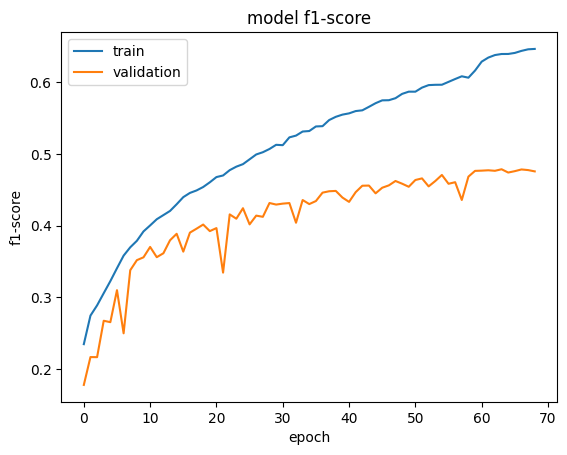

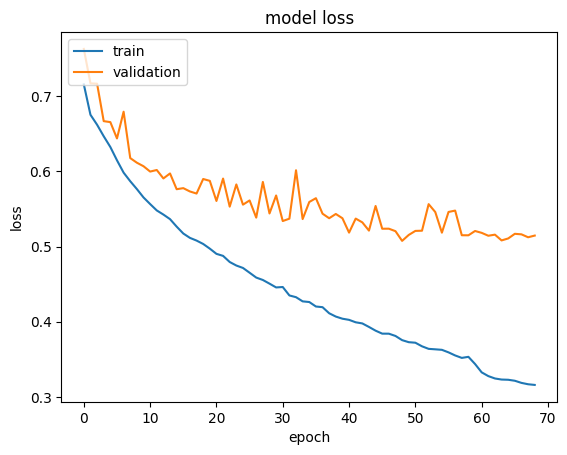

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 512 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


82/82 ━━━━━━━━━━━━━━━━━━━━ 65s 503ms/step - IoU: 0.3110 - accuracy: 0.9485 - f1-score: 0.4648 - loss: 0.5050 - precision: 0.4105 - recall: 0.5691


In [ ]:
# fix random seed for reproducibility
np.random.seed(42)
# Here we define the evaluation metrics - Precision, Recall, FScore, IoU
metrics = [sm.metrics.Precision(threshold=0.5),sm.metrics.Recall(threshold=0.5),sm.metrics.FScore(threshold=0.5,beta=1, name= 'f1-score'),sm.metrics.IOUScore(threshold=0.5, name= 'IoU'), 'accuracy']

loss= loss

# Number of filters. We set a range of the number of filters for the convolutional layers.
filters = [64]

# The learning rate is a tuning parameter in an optimization algorithm that determines the step size
# at each iteration while moving toward a minimum of a loss function.
# Learning rates for the ADAM optimizer that we use in the model. An activation function decides whether a neuron should be activated or not.
# This means that it will decide whether the neuron's input to the network is important or not in the process of prediction using simpler mathematical operations.
# Optimizers helps in maintaining a steady learning capability of the model while also keeping the loss at the minimum.
lr = [10e-5]

# Batch sizes. This considers how many patches the model will take during the training phases. A value of 4 means 4 patches of images (from 1119) will be taken as a batch while training simultaneously.
batch_size = [4]

# Epochs. The number of iterations the model will train.
epochs = 120
#Last epochs where the models got stopped
previous_epoch = 0
# Dictionary that will save the results. We first make an empty dictionary so that later we can save/store all the important configurations that we experimented with and report at the end in nice Excel CSVs and Plots.
dic = {}

# Hyperparameters. These are the keys where the associated information for each hyperparameter will be saved.
dic["model"] = [] # Name of the model
dic["batch_size"] = [] # Batch Size
dic["learning_rate"] = [] # Learning rate
dic["filters"] = [] # Number of filters

# Metrics on the test set. It will save the metrics after evaluating the model on the test set.
dic["precision_area"] = []
dic["recall_area"] = []
dic["f1_score_area"] = []
dic["miou_area"] = []
dic["oa_area"] = []
dic["time_area"] = []

## Here we perform a nested for-loop to check all possible hyperparameter combinations that we set above.

# loop over all the filters in the filter list
for fiilter in filters:
    # loop over the learning rates
    for learning_rate in lr:
        # loop over all batch sizes in batch_size list
        for batch in batch_size:
            print('_______________________________________________________________________________')
            print('Filters: ', fiilter)
            print('Learning rate: ', learning_rate)
            print('Batch size: ', batch)
            model = Changeformer(input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), num_classes=1)
            #model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
            model.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics, run_eagerly=False)
            model.summary()
            # Plot the denoising model
            #plot_model(model, to_file='network_model2.png', show_shapes=True, show_layer_names=True)
            #Load the weights in case the model stop or got pretrained
            pretrained_weights = None
            if(pretrained_weights):
                model.load_weights(pretrained_weights)

            # Stop the training if the validation loss does not decrease after 30 epochs. This is done to avoid over-fitting of the model. Please find the materials to understand overfitting here: https://www.v7labs.com/blog/overfitting
            early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', # what is the metric to measure. We choose "val_loss" because we want to monitor the progress of the model while tuning on the validation data set.
                              patience = 20, # how many epochs to continue running the model after not seeing any change in the "val_loss"
                              restore_best_weights = True) # update the model weights

            #Initiate tensorboard
            file_name = 'Changeformer'  #Give unique name each time, otherwise results get concatenated
            log_dir = "logs/fit/" + "logs\\{}" .format(file_name)
            tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

            model_path = f'/content/drive/MyDrive/landslide/Results/weights/Changeformer_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.keras'
            # Save the models only when validation loss decrease
            model_checkpoint = tf.keras.callbacks.ModelCheckpoint(model_path,
                                                                  monitor='val_loss', mode='min',verbose=1, save_best_only=True)
            plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=10, min_lr=1e-5, verbose=1)

            # fit the model with 20% of the dataset used as the validation set
            start_time = time.time()
            # Assuming input names are 'input_1', 'input_2', and 'input_3'
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                initial_epoch=previous_epoch,
                callbacks = [model_checkpoint, early_stop, plateau, tensorboard_callback],
                verbose=1
            )
            final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
            print(f"Final learning rate: {final_lr:.2e}")
            training_time = time.time() - start_time

            #model_size = sum([np.prod(v.shape.as_list()) for v in model.trainable_weights]) * 4 / 1024 / 1024  # size in MB

            # summarize history for f1-score - we want this to increase....
            plt.plot(history.history['f1-score'])
            plt.plot(history.history['val_f1-score'])
            plt.title('model f1-score')
            plt.ylabel('f1-score')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            # save plots locally
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Changeformer_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_f1_score.png")
            plt.show()
            # summarize history for loss - we want this to decrease....
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title('model loss')
            plt.ylabel('loss')
            plt.xlabel('epoch')
            plt.legend(['train', 'validation'], loc='upper left')
            plt.savefig(f"/content/drive/MyDrive/landslide/Results/plots/Changeformer_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}_val_loss.png")
            plt.show()

            # load unet to evaluate the test data
            load_Attunet = Changeformer(input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), num_classes=1)
            load_Attunet.compile(optimizer = Adam(learning_rate = learning_rate), loss = loss, metrics = metrics)
            # load the last saved weight from the training
            load_Attunet.load_weights(model_path)

           # Here, we evaluate the model performance on the test set, a set of data that the model has never seen before and therefore remains an objective tool to test the performance of the model.
            att_1= load_Attunet.evaluate(test_dataset)

            # save results on the dictionary and then output them all in a Excel CSV file.
            dic["model"].append("Changeformer")
            dic["batch_size"].append(batch)
            dic["learning_rate"].append(learning_rate)
            dic["filters"].append(fiilter)
            dic["precision_area"].append(att_1[1])
            dic["recall_area"].append(att_1[2])
            dic["f1_score_area"].append(att_1[3])
            dic["miou_area"].append(att_1[4])
            dic["oa_area"].append(att_1[5])
            dic["time_area"].append(training_time)

            # Convert results to a dataframe
            results = pd.DataFrame(dic)
            # Export as csv
            results.to_csv(f'/content/drive/MyDrive/landslide/Results/csv/results_Changeformer.csv', index = False)

## VISUALIZATION OF THE MODEL ON TENSORBOARD

In [ ]:
%tensorboard --logdir logs/fit

## VISUALIZATIONS OF FEATURES MAPS

(128, 128, 9)
1/1 [==============================] - 16s 16s/step
Feature Map 1 shape: (1, 64, 64, 128)
Feature Map 2 shape: (1, 32, 32, 128)
Feature Map 3 shape: (1, 16, 16, 256)
Feature Map 4 shape: (1, 32, 32, 128)
Feature Map 5 shape: (1, 64, 64, 64)
Feature Map 6 shape: (1, 64, 64, 64)


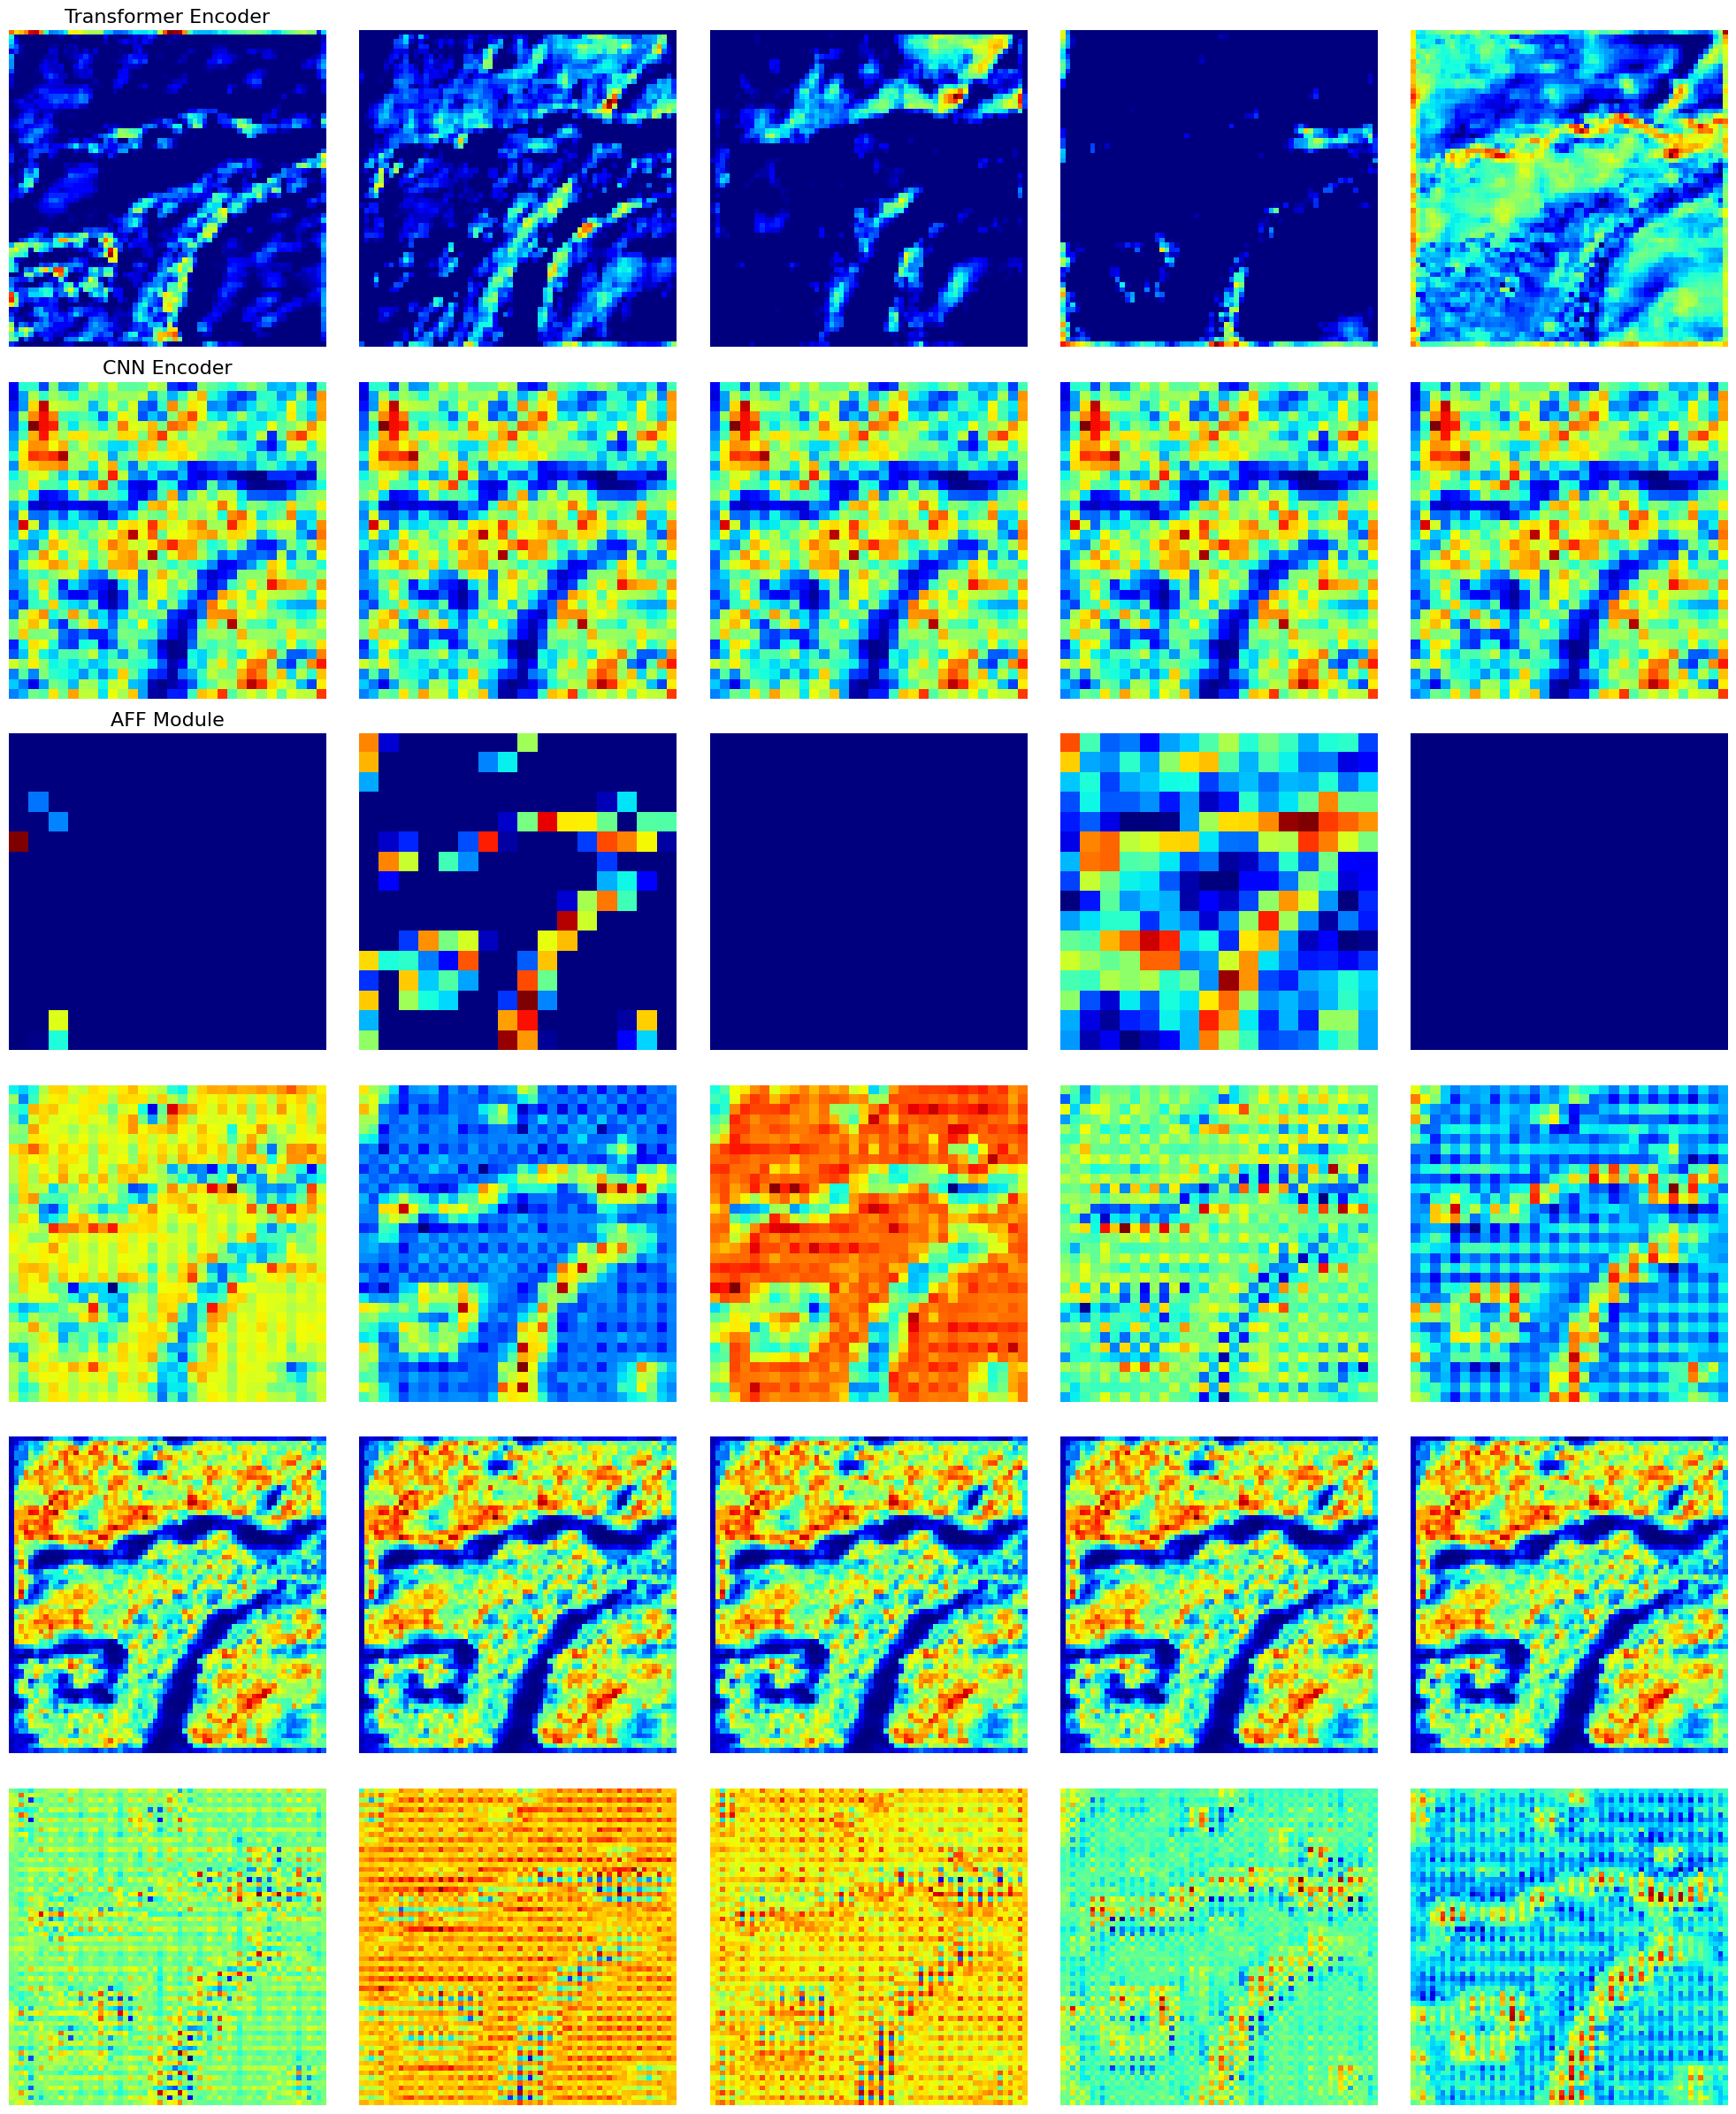

In [ ]:
# load unet to evaluate the test data
model = Siamese_CSA_1(filtersFirstLayer=fiilter, input_size1 = (size1,size1,img_bands1), input_size2 = (size1,size1,img_bands1), input_size3 = (size2,size2,img_bands2),batchnorm=True)
model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
# load the last saved weight from the training
model.load_weights(f"/content/drive/MyDrive/landslide/Results/weights/Siamese_CSA_size_{size1}_filters_{fiilter}_batch_size_{batch}_lr_{learning_rate}.hdf5")

# Replace 'layer_names' with the actual layer names or indices you want to extract
layer_names = [ 'L3_layer', 'SFI1_2', 'SFI2', 'FFUM1_1', 'SFI1_1', 'FFUM1_2' ]  # Example layer names
layer_outputs = [model.get_layer(name).output for name in layer_names]

# Create a new model that outputs the selected feature maps
feature_map_model = Model(inputs=model.input, outputs=layer_outputs)
input_image = TRAIN_XX_1[1]
print(input_image.shape)

input_image = np.expand_dims(input_image, axis=0)  # Add batch dimension if necessary

# Generate feature maps for the input data
feature_maps = feature_map_model.predict([input_image, input_image])

# Print the shape of the feature maps
for i, feature_map in enumerate(feature_maps):
    print(f"Feature Map {i+1} shape: {feature_map.shape}")

# Visualize the feature maps
def plot_feature_maps(feature_maps, titles=None):
    num_layers = len(feature_maps)
    num_filters = min(5, feature_maps[0].shape[-1])  # Number of filters to display per layer

    plt.figure(figsize=(20, num_layers * 4))

    for layer_idx in range(num_layers):
        fmap = feature_maps[layer_idx]
        for i in range(num_filters):
            ax = plt.subplot(num_layers, num_filters, layer_idx * num_filters + i + 1)
            # Using 'jet' colormap for similar color and gradient effect
            plt.imshow(fmap[0, :, :, i], cmap='jet')
            plt.axis('off')
            if titles is not None and i == 0 and layer_idx < len(titles):
                ax.set_title(titles[layer_idx], fontsize=16, color='black')

    plt.tight_layout()
    plt.show()

# Example usage with titles
titles = ['Transformer Encoder', 'CNN Encoder', 'AFF Module']
plot_feature_maps(feature_maps, titles=titles)